**Final Project UMKM Proksima — Dari Data Mentah sampai Penjelasan Model**

Notebook ini menunjukkan **apa masalahnya, apa yang kita coba, bagaimana hasilnya, dan mengapa kita memilih suatu cara**. Jalankan dari atas ke bawah melalui **Runtime → Run all**. Satu langkah dibuat dalam cell tersendiri agar tabel atau grafiknya mudah dicari.

Tujuan model adalah memperkirakan gagal bayar, dengan keseimbangan precision dan recall. Sesuai arahan kasus, kita juga memperhatikan agar debitur yang sebenarnya lancar tidak terlalu sering ditandai berisiko. Flag 1 berarti **perlu ditinjau**, bukan otomatis ditolak kreditnya.

Urutan pekerjaan: pahami data → hapus duplikasi/periksa nilai → pisahkan train–test → uji pengisian nilai kosong → uji fitur dan transparansi → uji kategori → uji distribusi/outlier → uji imbalance → bandingkan algoritma → buat OOF PD → cari threshold → evaluasi test → jelaskan model → cek perbedaan antarkelompok → hitung ECL skenario → segmentasi → dashboard → simpan hasil.

**Catatan riwayat:** hasil test yang sama pernah dilihat pada versi notebook sebelumnya. Karena itu, hasil sekarang adalah evaluasi revisi; bukan pengujian dengan data baru yang sama sekali belum pernah dilihat. Semua pemilihan pada versi ini tetap memakai train. Jika tersedia, data periode baru bisa digunakan untuk pemeriksaan tambahan.

Output mencakup data bersih, model, catatan percobaan, SHAP/LIME, fairness, segmentasi, dan dashboard. Angka yang tampil mengikuti hasil eksekusi; kita tidak memaksa hasil sama dengan versi lama.

### 0.1 Menyiapkan library Python

Kita memasang paket yang belum tersedia, lalu mencatat versinya. Versi penting karena perbedaan paket kadang menghasilkan perbedaan kecil pada angka atau tampilan grafik. `SEED=42` menjaga pengacakan tetap sama saat pekerjaan diulang.

In [74]:
import sys, subprocess, importlib.util
for package, module in [('statsmodels','statsmodels'),('jinja2','jinja2'),('numpy','numpy'),('pandas','pandas'),('matplotlib','matplotlib'),('seaborn','seaborn'),('scikit-learn','sklearn'),('imbalanced-learn','imblearn'),('xgboost','xgboost'),('shap','shap'),('lime','lime'),('cloudpickle','cloudpickle')]:
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, fbeta_score, balanced_accuracy_score, roc_auc_score, average_precision_score, brier_score_loss, log_loss, make_scorer)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from xgboost import XGBClassifier
import importlib.metadata as metadata
SEED = 42
sns.set_theme(style='whitegrid')
AUDIT = {}
versions = pd.DataFrame([(p,metadata.version(p)) for p in ['numpy','pandas','scikit-learn','imbalanced-learn','xgboost','shap','lime']],columns=['package','version'])
display(versions)
AUDIT['versions'] = versions

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 180)

,package,version
0,numpy,2.1.3
1,pandas,2.2.3
2,scikit-learn,1.6.1
3,imbalanced-learn,0.14.2
4,xgboost,3.4.1
5,shap,0.52.0
6,lime,0.2.0.1


### 1.1 Membaca data mentah

`raw` menyimpan data yang baru dibaca. Kita tidak mengubahnya agar kondisi awal selalu bisa dibandingkan dengan hasil cleaning.

Cell berikut boleh diganti dengan `raw = pd.read_csv(url)` dari Google Drive milikmu. Daftar fitur didefinisikan di cell berikutnya, dan penanda data untuk ekspor dihitung di bagian ekspor, sehingga tidak bergantung pada variabel dari pembacaan file lokal.

In [75]:
file_id = '1Bm5ot3U-EB9THbUqlFvjfMKry8sc2nEx'
url = f'https://drive.google.com/uc?id='+file_id
raw = pd.read_csv(url)
print('Ukuran data mentah:', raw.shape)
display(raw.head())

Ukuran data mentah: (10000, 18)


,id_debitur,sektor_usaha,omzet_bulanan,lama_usaha_tahun,jumlah_karyawan,plafon_kredit,skor_kredit_internal,rasio_cicilan_omzet,jumlah_tunggakan_historis,jenis_produk_kredit,biaya_operasional_bulanan,pertumbuhan_omzet_yoy,kepemilikan_agunan,jenis_kelamin_pemilik_usaha,status_kepemilikan_tempat_usaha,channel_pengajuan_kredit,flag_gagal_bayar,status_risiko
0,UMKM-06253,Kuliner,33454286.0,5.9,2,107947053,493,15.1,2,KUR Kecil,28147622.0,-24.1,Ya,Laki-laki,Sewa,Cabang,0,DPK
1,UMKM-04685,Perdagangan Daring/Reseller,NaN,NaN,1,134528197,695,38.3,0,KUR Kecil,12156548.0,-1.1,Ya,Perempuan,Sewa,Cabang,0,Lancar
2,UMKM-01732,Perdagangan Eceran,17380898.0,1.2,0,235339829,531,69.8,2,KUR Kecil,16743383.0,-22.0,Tidak,Perempuan,Sewa,Cabang,0,DPK
3,UMKM-04743,Jasa Personal,24088515.0,4.2,0,188302794,649,36.0,0,KUR Kecil,16799206.0,4.6,Ya,Laki-laki,Sewa,Digital,0,Lancar
4,UMKM-04522,Konveksi dan Kerajinan Rumahan,NaN,5.3,2,166873882,549,33.3,1,KUR Kecil,22993939.0,-15.4,Tidak,Perempuan,Milik Sendiri,Cabang,0,DPK


### 1.2 Memahami arti dan peran setiap kolom

Sebelum membuat model, periksa arti, satuan, tipe data, jumlah nilai kosong, dan jumlah nilai unik setiap kolom. **Predictor/fitur** adalah informasi yang diberikan kepada model; **target** adalah jawaban yang ingin diprediksi (`flag_gagal_bayar`).

ID hanya mengenali debitur. Gender dipakai untuk memeriksa fairness. `status_risiko` tidak menjadi predictor karena merupakan informasi hasil. Skor internal dan tunggakan historis hanya layak dipakai jika sudah tersedia sebelum kejadian gagal bayar; waktu pencatatannya belum bisa diverifikasi dari dataset ini.

In [76]:
NUM = ['omzet_bulanan','lama_usaha_tahun','jumlah_karyawan','plafon_kredit','skor_kredit_internal','rasio_cicilan_omzet','jumlah_tunggakan_historis','biaya_operasional_bulanan','pertumbuhan_omzet_yoy']
CAT = ['sektor_usaha','jenis_produk_kredit','kepemilikan_agunan','status_kepemilikan_tempat_usaha','channel_pengajuan_kredit']
TARGET = 'flag_gagal_bayar'
MODEL_NUM = NUM.copy()  # Mulai dengan semua fitur; keputusan baru dibuat setelah pengujian.
descriptions = {
'omzet_bulanan':('rupiah/bulan','Skala pendapatan usaha'), 'biaya_operasional_bulanan':('rupiah/bulan','Beban operasional'),
'lama_usaha_tahun':('tahun','Pengalaman usaha'), 'jumlah_karyawan':('orang','Skala tenaga kerja'),
'plafon_kredit':('rupiah','Limit kredit; proxy EAD'), 'skor_kredit_internal':('poin','Skor internal; cek waktu pengukuran'),
'rasio_cicilan_omzet':('persen 0–100','Beban pembayaran terhadap omzet; bukan leverage neraca'),
'jumlah_tunggakan_historis':('jumlah kejadian','Riwayat sebelum outcome; cek waktu'), 'pertumbuhan_omzet_yoy':('persen','Perubahan omzet tahunan')}
dictionary = pd.DataFrame([{'kolom':c,'dtype':str(raw[c].dtype),'satuan':descriptions.get(c,('kategori/label',''))[0],
'fungsi':descriptions.get(c,('', 'Kategori bisnis' if c in CAT else 'ID / label / audit'))[1],
'missing':raw[c].isna().sum(),'unik':raw[c].nunique()} for c in raw.columns])
display(dictionary)
AUDIT['kamus_data'] = dictionary


,kolom,dtype,satuan,fungsi,missing,unik
0,id_debitur,object,kategori/label,ID / label / audit,0,9860
1,sektor_usaha,object,kategori/label,Kategori bisnis,0,5
2,omzet_bulanan,float64,rupiah/bulan,Skala pendapatan usaha,787,9080
3,lama_usaha_tahun,float64,tahun,Pengalaman usaha,1206,227
4,jumlah_karyawan,int64,orang,Skala tenaga kerja,0,12
5,plafon_kredit,int64,rupiah,Limit kredit; proxy EAD,0,9860
6,skor_kredit_internal,int64,poin,Skor internal; cek waktu pengukuran,0,475
7,rasio_cicilan_omzet,float64,persen 0–100,Beban pembayaran terhadap omzet; bukan leverag...,0,623
8,jumlah_tunggakan_historis,int64,jumlah kejadian,Riwayat sebelum outcome; cek waktu,0,10
9,jenis_produk_kredit,object,kategori/label,Kategori bisnis,0,3


### 2.1 Menghapus baris duplikat identik

Jika seluruh isi dua baris sama, satu salinannya dihapus. Ini mencegah debitur yang sama dihitung dua kali atau muncul di train dan test sekaligus.

Tabel menunjukkan jumlah baris sebelum/sesudah dan contoh salinan yang dihapus. Jika ID sama tetapi isinya berbeda, kasus itu tidak diselesaikan dengan membuang baris sembarangan; pemeriksaan ID dilakukan terpisah.

In [77]:
duplicate_rows = raw.loc[raw.duplicated(keep='first')].copy()
df = raw.drop_duplicates().copy()
display(pd.DataFrame({'tahap':['mentah','setelah deduplikasi'],'baris':[len(raw),len(df)]}))
display(duplicate_rows.head())
AUDIT['duplikasi_dihapus'] = duplicate_rows


,tahap,baris
0,mentah,10000
1,setelah deduplikasi,9860


,id_debitur,sektor_usaha,omzet_bulanan,lama_usaha_tahun,jumlah_karyawan,plafon_kredit,skor_kredit_internal,rasio_cicilan_omzet,jumlah_tunggakan_historis,jenis_produk_kredit,biaya_operasional_bulanan,pertumbuhan_omzet_yoy,kepemilikan_agunan,jenis_kelamin_pemilik_usaha,status_kepemilikan_tempat_usaha,channel_pengajuan_kredit,flag_gagal_bayar,status_risiko
193,UMKM-02909,Perdagangan Daring/Reseller,7822032.0,NaN,2,44255497,665,28.4,0,KUR Mikro,5696603.0,5.0,Tidak,Laki-laki,Sewa,Cabang,0,Lancar
563,UMKM-03351,Perdagangan Eceran,26314350.0,2.9,2,140127248,490,25.7,2,KUR Kecil,25524920.0,-19.2,Ya,Perempuan,Sewa,Cabang,1,Menunggak
593,UMKM-05382,Jasa Personal,68480478.0,5.4,1,446123415,583,32.5,0,Kredit Modal Kerja,47057405.0,10.0,Tidak,Perempuan,Milik Sendiri,Cabang,0,Lancar
654,UMKM-06835,Konveksi dan Kerajinan Rumahan,20249313.0,8.2,3,130470243,650,32.9,0,KUR Kecil,18156790.0,-10.2,Tidak,Laki-laki,Sewa,Cabang,0,Lancar
728,UMKM-03131,Kuliner,35409435.0,7.4,2,240946243,549,34.6,1,KUR Kecil,26560272.0,0.1,Tidak,Laki-laki,Sewa,Cabang,0,DPK


### 2.2 Memeriksa apakah angka masuk akal

Kita ubah kolom numerik menjadi angka, lalu periksa aturan dasarnya. Omzet dan plafon harus positif; jumlah orang/kejadian tidak negatif dan harus bulat; penurunan omzet tidak kurang dari −100%. Angka tak terhingga dan teks yang gagal dibaca sebagai angka juga dicatat.

Nilai yang melanggar aturan menjadi `NaN` (kosong), bukan langsung diganti nol. Pengisiannya diuji setelah train–test dipisahkan. Tidak ada batas skor kredit buatan tanpa kamus resmi. Rasio cicilan di atas 100% tidak otomatis salah, dan biaya nol masih perlu dilihat konteksnya. **Tidak melanggar aturan belum membuktikan nilai pasti benar.**

In [78]:
invalid_records=[]
for c in NUM:
    before=df[c].copy()
    numeric=pd.to_numeric(before,errors='coerce')
    bad_parse=before.notna() & numeric.isna()
    invalid=numeric.notna() & ~np.isfinite(numeric)
    if c=='pertumbuhan_omzet_yoy': invalid |= numeric.lt(-100)
    elif c in ['omzet_bulanan','plafon_kredit']: invalid |= numeric.le(0)
    else: invalid |= numeric.lt(0)
    if c in ['jumlah_karyawan','jumlah_tunggakan_historis']:
        invalid |= numeric.notna() & ~np.isclose(numeric,numeric.round())
    for idx in df.index[bad_parse | invalid]:
        invalid_records.append({'id_debitur':df.at[idx,'id_debitur'],'kolom':c,'sebelum':before.loc[idx],
                                'alasan':'gagal konversi' if bad_parse.loc[idx] else 'pelanggaran domain','sesudah':np.nan})
    df[c]=numeric.mask(invalid)
invalid_audit=pd.DataFrame(invalid_records,columns=['id_debitur','kolom','sebelum','alasan','sesudah'])
display(invalid_audit)
print('Jumlah sel invalid:',len(invalid_audit))
AUDIT['invalid_numerik'] = invalid_audit


,id_debitur,kolom,sebelum,alasan,sesudah


Jumlah sel invalid: 0


### 2.3 Merapikan tulisan kategori

Spasi di awal/akhir dan spasi berulang dirapikan agar kategori yang sama tidak terbaca berbeda. Kita tidak menyatukan kategori bisnis yang memang berbeda. Tabel menampilkan berapa isian yang berubah dan kategori yang tersisa.

In [79]:
category_changes=[]
for c in CAT+['jenis_kelamin_pemilik_usaha']:
    before=df[c].copy()
    after=before.astype('string').str.strip().str.replace(r'\s+',' ',regex=True).replace('',pd.NA)
    category_changes.append({'kolom':c,'jumlah_berubah':int((before.fillna('')!=after.fillna('')).sum()),'kategori':after.dropna().unique().tolist()})
    df[c]=after.astype(object).where(after.notna(),np.nan)
display(pd.DataFrame(category_changes))
AUDIT['normalisasi_kategori']=pd.DataFrame(category_changes)


,kolom,jumlah_berubah,kategori
0,sektor_usaha,0,"[Kuliner, Perdagangan Daring/Reseller, Perdaga..."
1,jenis_produk_kredit,0,"[KUR Kecil, Kredit Modal Kerja, KUR Mikro]"
2,kepemilikan_agunan,0,"[Ya, Tidak]"
3,status_kepemilikan_tempat_usaha,0,"[Sewa, Milik Sendiri]"
4,channel_pengajuan_kredit,0,"[Cabang, Digital]"
5,jenis_kelamin_pemilik_usaha,0,"[Laki-laki, Perempuan]"


### 2.4 Memeriksa ID dan label gagal bayar

`id_debitur` adalah kunci untuk melacak satu debitur. Kunci ini harus terisi dan unik. Label harus tersedia serta bernilai 0 (tidak gagal bayar) atau 1 (gagal bayar).

Jika pemeriksaan gagal, proses berhenti agar masalah diselesaikan. Label kosong tidak diisi dengan mean/median karena itu akan menciptakan jawaban buatan untuk model.

In [80]:
assert df['id_debitur'].notna().all() and df['id_debitur'].is_unique, 'Periksa ID kosong/konflik.'
assert df[TARGET].isin([0,1]).all(), 'Target harus tersedia dan bernilai 0/1.'
print('PASS: ID unik, tidak kosong; label biner valid.')


PASS: ID unik, tidak kosong; label biner valid.


### 2.5 Membagi data menjadi train 80% dan test 20%

Train dipakai untuk belajar dan memilih metode. Test disimpan untuk mengevaluasi pilihan yang sudah ditetapkan. `stratify` menjaga proporsi gagal bayar pada keduanya tetap mendekati sama.

Mean/median, batas capping, dan parameter scaler hanya dipelajari dari train. Test memakai angka dari train, bukan menghitung angka pengganti sendiri. Karena tidak tersedia tanggal, pembagian ini acak; kemampuan model menghadapi periode mendatang belum diuji.

In [81]:
ids_train,ids_test=train_test_split(df.index,test_size=.2,stratify=df[TARGET],random_state=SEED)
INPUT_FEATURES=NUM+CAT
X_train=df.loc[ids_train,INPUT_FEATURES].copy(); y_train=df.loc[ids_train,TARGET].astype(int)
X_test=df.loc[ids_test,INPUT_FEATURES].copy(); y_test=df.loc[ids_test,TARGET].astype(int)
df['split']=np.where(df.index.isin(ids_train),'train','test')
assert set(ids_train).isdisjoint(ids_test)
split_summary=df.groupby('split')[TARGET].agg(jumlah='size',default='sum',default_rate='mean').reset_index()
display(split_summary)
AUDIT['split_summary']=split_summary
AUDIT['split_membership']=df[['id_debitur','split']].copy()


,split,jumlah,default,default_rate
0,test,1972,268,0.135903
1,train,7888,1070,0.135649


### 2.6 Melihat ringkasan cleaning awal

Kita cek kembali jumlah baris mentah, duplikasi yang dibuang, sel tidak valid, dan nilai kosong yang masih tersisa. Pengisian nilai kosong belum dilakukan pada tahap ini. Catatan per ID/kolom disimpan agar perubahan dapat ditelusuri.

In [82]:
cleaning_summary=pd.DataFrame({'indikator':['baris mentah','duplikat dihapus','baris tersisa','sel invalid','missing numerik tersisa'],
'nilai':[len(raw),len(duplicate_rows),len(df),len(invalid_audit),int(df[NUM].isna().sum().sum())]})
display(cleaning_summary)
AUDIT['cleaning_summary']=cleaning_summary


,indikator,nilai
0,baris mentah,10000
1,duplikat dihapus,140
2,baris tersisa,9860
3,sel invalid,0
4,missing numerik tersisa,2948


## 3. Memahami cross-validation sebelum menguji metode

**Cross-validation (CV) adalah cara melakukan validasi berulang**, bukan metode tuning. Pada data ini, 7.888 baris train dibagi menjadi lima kelompok (fold): tiga kelompok berisi 1.578 baris dan dua kelompok berisi 1.577 baris.

| Putaran | Kelompok yang digabung untuk melatih satu model | Kelompok untuk validasi |
|---|---|---|
| 1 | 2, 3, 4, 5 | 1 |
| 2 | 1, 3, 4, 5 | 2 |
| 3 | 1, 2, 4, 5 | 3 |
| 4 | 1, 2, 3, 5 | 4 |
| 5 | 1, 2, 3, 4 | 5 |

Contoh putaran pertama: sekitar 6.310 baris dipakai melatih **satu model**, lalu model memprediksi 1.578 baris yang tidak ikut dilatih. Bukan empat model terpisah yang dilatih satu-satu. Proses diulang hingga setiap baris menjadi data validasi tepat sekali.

Pada setiap putaran, pengisian nilai kosong dan scaler juga belajar ulang dari empat kelompok latihan. Satu kelompok validasi hanya menerima hasil transformasi. Jika balancing dipakai, hanya empat kelompok latihan yang diubah jumlah kelasnya.

Lima putaran menghasilkan lima precision, lima recall, dan lima F1. Kolom `f1_cv` adalah rata-rata lima F1 tersebut. `test_f1` dalam fungsi Python `cross_validate` berarti hasil kelompok validasi CV, **bukan test 20%**. Lima fold dipilih sebagai kompromi waktu dan pengulangan, bukan angka wajib.

### 3.1 Menyimpan pembagian lima fold

Semua kandidat memakai kelompok yang sama agar perbedaannya berasal dari metode, bukan pembagian data yang berbeda. Kita simpan jumlah baris dan daftar ID per kelompok validasi. Dengan demikian, asal setiap prediksi dapat ditelusuri.

In [83]:
CV=StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED)
FOLDS=list(CV.split(X_train,y_train))
fold_rows=[]; membership=[]
for fold,(tr,va) in enumerate(FOLDS,1):
    fold_rows.append({'fold':fold,'n_train':len(tr),'n_validasi':len(va),'default_rate_train':y_train.iloc[tr].mean(),'default_rate_validasi':y_train.iloc[va].mean()})
    for p in va: membership.append({'id_debitur':df.loc[X_train.index[p],'id_debitur'],'index_asli':X_train.index[p],'fold_validasi':fold})
fold_audit=pd.DataFrame(fold_rows); fold_membership=pd.DataFrame(membership)
display(fold_audit)
AUDIT['cv_fold_sizes']=fold_audit; AUDIT['cv_membership']=fold_membership


,fold,n_train,n_validasi,default_rate_train,default_rate_validasi
0,1,6310,1578,0.135658,0.135615
1,2,6310,1578,0.135658,0.135615
2,3,6310,1578,0.135658,0.135615
3,4,6311,1577,0.135636,0.135701
4,5,6311,1577,0.135636,0.135701


### 3.2 Menentukan cara menilai sebelum melihat hasil

Kelas 1 berarti gagal bayar. **TP:** benar ditandai gagal bayar. **FP:** sebenarnya lancar tetapi ditandai gagal bayar. **FN:** sebenarnya gagal bayar tetapi diprediksi lancar. **TN:** benar diprediksi lancar.

| Metrik | Pertanyaan sederhana |
|---|---|
| Precision = TP/(TP+FP) | Dari semua yang ditandai, berapa yang benar gagal bayar? |
| Recall = TP/(TP+FN) | Dari semua yang benar gagal bayar, berapa yang berhasil ditemukan? |
| F1 = 2×precision×recall/(precision+recall) | Seberapa baik keseimbangan keduanya? |
| Accuracy | Dari seluruh debitur, berapa yang klasifikasinya benar? |
| F0,5 | Bagaimana hasil jika precision diberi penekanan lebih besar? |
| Balanced accuracy | Bagaimana rata-rata kemampuan mengenali masing-masing kelas? |
| AP dan ROC-AUC | Seberapa baik model mengurutkan risiko tanpa memakai satu batas klasifikasi? |

F1 tidak menjamin precision persis sama dengan recall. Kita memilih **F1 CV tertinggi pada threshold 0,50**, lalu precision jika seri, lalu pilihan lebih sederhana. Ini sesuai fokus keseimbangan dengan perhatian pada FP. F0,5 dan biaya kesalahan ditampilkan sebagai pembanding kebijakan.

Aturan tambahan khusus pengurangan multikolinearitas dijelaskan sebelum Bagian 5A dijalankan. Selisih kecil tidak otomatis berarti perbaikan yang meyakinkan; lihat juga hasil per fold. Brier Score dan Log Loss akan dibahas saat menilai PD kontinu.

In [84]:
SCORING={'accuracy':'accuracy','precision':make_scorer(precision_score,zero_division=0),'recall':'recall','f1':'f1',
'f05':make_scorer(fbeta_score,beta=.5,zero_division=0),'roc_auc':'roc_auc','ap':'average_precision'}
experiment_folds=[]
def compare_candidates(stage,candidates):
    rows=[]
    for order,(name,pipeline) in enumerate(candidates.items()):
        r=cross_validate(pipeline,X_train,y_train,cv=FOLDS,scoring=SCORING,n_jobs=1,error_score='raise')
        for fold in range(5):
            experiment_folds.append({'stage':stage,'candidate':name,'fold':fold+1,**{m:float(r['test_'+m][fold]) for m in SCORING}})
        rows.append({'candidate':name,'complexity_order':order,**{m+'_cv':r['test_'+m].mean() for m in SCORING},'f1_std':r['test_f1'].std(ddof=1)})
    table=pd.DataFrame(rows).sort_values(['f1_cv','precision_cv','complexity_order'],ascending=[False,False,True]).reset_index(drop=True)
    AUDIT[stage]=table
    display(table)
    print('Terpilih:',table.iloc[0]['candidate'],'; F1 CV:',round(table.iloc[0]['f1_cv'],4))
    return table,table.iloc[0]['candidate']


### 4.1 Melihat nilai kosong dan bentuk sebaran data

Kita hitung kolom mana yang kosong, berapa persentasenya, dan bagaimana distribusinya pada train. `skewness` positif besar berarti ekor data memanjang ke angka tinggi.

Median lebih tahan terhadap nilai ekstrem, sedangkan mean memakai seluruh besaran angka. Sektor juga mungkin memiliki karakteristik berbeda. Itu memberi alasan untuk **menguji** cara pengisian, belum menjadi bukti median pasti menang.

,fitur,missing_train,missing_pct,skewness_train
0,omzet_bulanan,619,7.847363,2.187711
1,lama_usaha_tahun,958,12.145030,1.235927
2,jumlah_karyawan,0,0.000000,0.918040
3,plafon_kredit,0,0.000000,1.171287
4,skor_kredit_internal,0,0.000000,-0.059301
5,rasio_cicilan_omzet,0,0.000000,0.903008
6,jumlah_tunggakan_historis,0,0.000000,1.833488
7,biaya_operasional_bulanan,788,9.989858,2.208939
8,pertumbuhan_omzet_yoy,0,0.000000,-0.026224


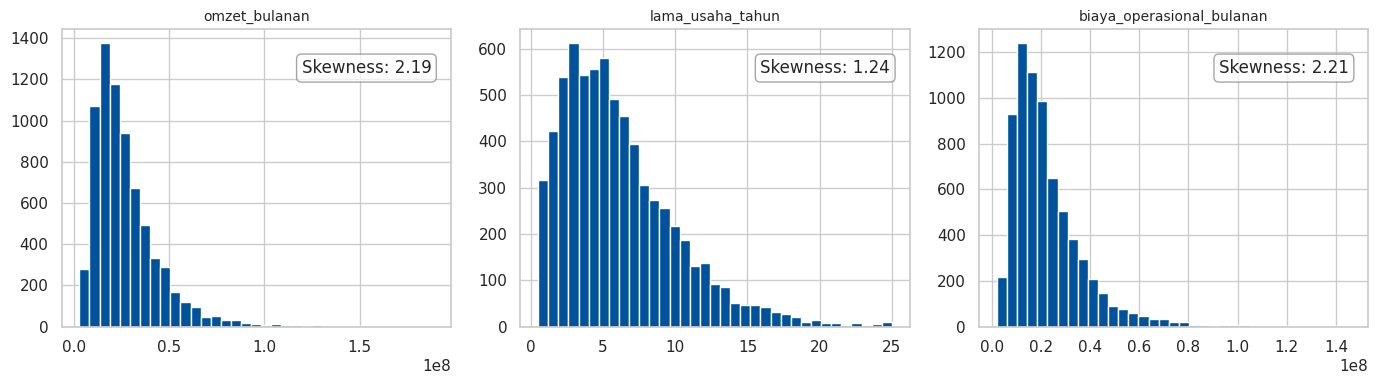

In [85]:
# 1. Membuat DataFrame profil missing value dan skewness
missing_profile = pd.DataFrame({
    'fitur': NUM,
    'missing_train': [X_train[c].isna().sum() for c in NUM],
    'missing_pct': [X_train[c].isna().mean() * 100 for c in NUM],
    'skewness_train': [X_train[c].skew() for c in NUM]
})
display(missing_profile)
AUDIT['missing_profile'] = missing_profile

# 2. Visualisasi Distribusi dengan Teks Skewness
fig, axes = plt.subplots(1, 3, figsize=(14, 4)) # Tinggi dinaikkan sedikit agar teks tidak menumpuk
for ax, c in zip(axes, ['omzet_bulanan', 'lama_usaha_tahun', 'biaya_operasional_bulanan']):
    # Hitung nilai skewness untuk fitur ini
    skew_val = X_train[c].skew()

    # Plot histogram
    ax.hist(X_train[c].dropna(), bins=35, color='#00529C')
    ax.set_title(c, fontsize=10)

    # Menambahkan teks skewness di pojok kanan atas grafik (posisi relatif transform=ax.transAxes)
    ax.text(0.95, 0.90, f'Skewness: {skew_val:.2f}',
            transform=ax.transAxes,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='gray'))

plt.tight_layout()
plt.show()


### 4.2 Menyiapkan fungsi pengisian nilai kosong

Kita membandingkan median seluruh train, mean per sektor, dan median per sektor. Mean adalah rata-rata; median adalah nilai tengah. Jika suatu sektor tidak tersedia, gunakan angka seluruh train sebagai cadangan.

Fungsi berikut dipanggil ulang di setiap fold, sehingga kelompok validasi tidak menentukan nilai pengganti. Penanda missing hanya untuk audit, tidak menjadi predictor. Jika satu kolom seluruhnya kosong di bagian latihan, proses dihentikan.

#### Pengisi nilai kosong

Fungsi ini menyimpan mean atau median dari data latihan. Saat menerima data baru, ia memakai angka yang sudah disimpan.

In [86]:
class GroupImputer(BaseEstimator,TransformerMixin):
    def __init__(self,method='median_sector'): self.method=method
    def fit(self,X,y=None):
        self.global_=X[NUM].mean() if self.method=='mean_sector' else X[NUM].median()
        if self.global_.isna().any(): raise ValueError('Seluruh nilai kolom training kosong.')
        grouped=X.groupby('sektor_usaha')[NUM]
        self.group_=grouped.mean() if self.method=='mean_sector' else grouped.median()
        return self
    def transform(self,X):
        z=X.copy()
        for c in NUM:
            fill=z['sektor_usaha'].map(self.group_[c]) if self.method!='median_global' else pd.Series(np.nan,index=z.index)
            z[c]=z[c].fillna(fill).fillna(self.global_[c])
        for c in CAT: z[c]=z[c].fillna('Tidak diketahui')
        return z



#### Pembuat rasio bila diperlukan

Rasio biaya dibuat hanya bila termasuk fitur terpilih. Kolom asli tetap disimpan. Sebelum ada keputusan fitur, langkah ini hanya meneruskan data.

In [87]:
class DerivedFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, columns=()): self.columns = columns
    def fit(self, X, y=None): return self
    def transform(self, X):
        z = X.copy()
        if 'rasio_biaya_operasional_pct' in self.columns:
            if (z.omzet_bulanan <= 0).any():
                raise ValueError('Omzet harus positif sebelum membuat rasio biaya.')
            z['rasio_biaya_operasional_pct'] = 100*z.biaya_operasional_bulanan/z.omzet_bulanan
        return z



#### Pengubah distribusi

Fungsi ini menyimpan kolom yang akan diubah dan batas capping dari data latihan. Pada tahap imputasi belum ada perubahan distribusi karena pilihan masih `none`.

In [88]:
class DistributionTreatment(BaseEstimator,TransformerMixin):
    def __init__(self,method='none',columns=()):
        self.method=method
        self.columns=columns
    def fit(self,X,y=None):
        self.columns_=[c for c in self.columns if X[c].min()>=0 and X[c].skew()>1]
        self.bounds_=X[self.columns_].quantile([.01,.99])
        return self
    def transform(self,X):
        z=X.copy()
        for c in self.columns_:
            if self.method=='log': z[c]=np.log1p(z[c])
            elif self.method=='sqrt': z[c]=np.sqrt(z[c])
            elif self.method=='cap': z[c]=z[c].clip(self.bounds_.loc[.01,c],self.bounds_.loc[.99,c])
        return z



#### Penyusun urutan kerja model

Pipeline adalah urutan otomatis: isi nilai kosong → buat fitur → treatment distribusi → scaling/encoding → balancing jika dipilih → model. Dengan urutan ini, setiap fold belajar parameter dari bagian latihnya sendiri.

In [89]:
def make_pipeline(imputation='median_sector',categories=(),treatment='none',balance='none',algorithm='LR'):
    numeric_columns=tuple(MODEL_NUM)
    pre=ColumnTransformer([('num',StandardScaler() if algorithm=='LR' else 'passthrough',list(numeric_columns)),
        ('cat',OneHotEncoder(handle_unknown='ignore',drop='first',sparse_output=False),list(categories))],verbose_feature_names_out=False)
    if algorithm=='LR': model=LogisticRegression(C=1,solver='liblinear',max_iter=3000,random_state=SEED,class_weight='balanced' if balance=='weight' else None)
    elif algorithm=='RF': model=RandomForestClassifier(n_estimators=200,min_samples_leaf=2,random_state=SEED,n_jobs=2,class_weight='balanced' if balance=='weight' else None)
    else: model=XGBClassifier(n_estimators=150,max_depth=3,learning_rate=.05,subsample=.8,colsample_bytree=.8,eval_metric='logloss',random_state=SEED,n_jobs=2)
    sampler=RandomOverSampler(random_state=SEED) if balance=='ros' else SMOTE(random_state=SEED) if balance=='smote' else 'passthrough'
    return Pipeline([('imputer',GroupImputer(imputation)),('features',DerivedFeatures(numeric_columns)),('treatment',DistributionTreatment(treatment,numeric_columns)),('pre',pre),('sampler',sampler),('model',model)])
print('Transformer dan fungsi pipeline siap; belum ada fit.')


Transformer dan fungsi pipeline siap; belum ada fit.


### 4.3 Membandingkan tiga cara imputasi

Imputasi berarti mengisi nilai kosong. Pada percobaan ini, fitur, Logistic Regression, StandardScaler, lima fold, dan threshold 0,50 dibuat sama. Hanya cara mengisi nilai kosong yang berbeda.

Bandingkan F1, precision, dan recall pada tabel; pilihan mengikuti aturan sebelumnya. Hasil ini menunjukkan dampak terhadap klasifikasi, bukan membuktikan setiap angka isian sama dengan nilai asli yang hilang.

In [90]:
imputation_options={m:make_pipeline(imputation=m) for m in ['median_global','mean_sector','median_sector']}
imputation_comparison,chosen_imputation=compare_candidates('imputation_comparison',imputation_options)


,candidate,complexity_order,accuracy_cv,precision_cv,recall_cv,f1_cv,f05_cv,roc_auc_cv,ap_cv,f1_std
0,mean_sector,1,0.954615,0.859081,0.797196,0.826163,0.845376,0.983813,0.917680,0.018157
1,median_global,0,0.954488,0.859553,0.795327,0.825379,0.845321,0.983819,0.917625,0.020809
2,median_sector,2,0.954361,0.858756,0.795327,0.824983,0.844685,0.983822,0.917687,0.020354


Terpilih: mean_sector ; F1 CV: 0.8262


### 4.4 Menguji pengisian dengan menyembunyikan nilai yang diketahui

Pada kelompok validasi pertama, kita sengaja menyembunyikan 10% angka yang semula tersedia. Setiap metode mengisinya memakai informasi dari kelompok latihan, lalu hasilnya dibandingkan dengan angka asli.

`MAE` adalah rata-rata jarak absolut antara nilai isian dan nilai asli: makin kecil makin dekat. MAE rupiah tidak dijumlah dengan MAE tahun. Ini pemeriksaan tambahan; nilai kosong buatan dibuat acak, sedangkan penyebab nilai kosong asli belum diketahui.

In [91]:
tr,va=FOLDS[0]; rng=np.random.default_rng(SEED)
masked=X_train.iloc[va].copy(); masks={}
for c in NUM:
    known=np.flatnonzero(masked[c].notna().to_numpy())
    positions=rng.choice(known,size=max(1,len(known)//10),replace=False)
    masks[c]=positions; masked.iloc[positions,masked.columns.get_loc(c)]=np.nan
reconstruction=[]
for method in imputation_options:
    imp=GroupImputer(method).fit(X_train.iloc[tr]); filled=imp.transform(masked)
    for c,positions in masks.items():
        truth=X_train.iloc[va].iloc[positions][c].to_numpy()
        reconstruction.append({'metode':method,'fitur':c,'n_mask':len(positions),'mae':np.abs(filled.iloc[positions][c].to_numpy()-truth).mean()})
reconstruction=pd.DataFrame(reconstruction)
display(reconstruction.pivot(index='fitur',columns='metode',values='mae'))
AUDIT['imputation_masking']=reconstruction


metode,mean_sector,median_global,median_sector
fitur,,,
biaya_operasional_bulanan,9.155699e+06,8.980141e+06,8.715149e+06
jumlah_karyawan,1.156374e+00,1.127389e+00,1.127389e+00
jumlah_tunggakan_historis,8.259980e-01,8.025478e-01,7.197452e-01
lama_usaha_tahun,3.076034e+00,3.015000e+00,3.052143e+00
omzet_bulanan,1.349080e+07,1.275202e+07,1.275587e+07
pertumbuhan_omzet_yoy,9.111968e+00,1.091146e+01,9.134076e+00
plafon_kredit,7.448273e+07,7.435717e+07,7.457676e+07
rasio_cicilan_omzet,9.694150e+00,9.417197e+00,9.419108e+00
skor_kredit_internal,5.961382e+01,6.084713e+01,5.952866e+01


### 4.5 Membuat data bersih dan catatan sebelum–sesudah

Metode terpilih sekarang belajar dari seluruh train untuk membuat dataset bersih. Nilai kosong pada train maupun test diisi memakai parameter train tersebut.

Tabel per sel menyimpan ID, kolom, sektor, nilai sebelum/sesudah, dan sumber angka pengganti. Data bersih ini untuk output/audit. Saat CV berikutnya berjalan, pipeline tetap menerima data sebelum imputasi dan belajar ulang di setiap fold.

In [92]:
imputer_audit=GroupImputer(chosen_imputation).fit(X_train)
filled_all=imputer_audit.transform(df[INPUT_FEATURES])
clean=df.copy(); clean[INPUT_FEATURES]=filled_all
imputation_cells=[]
for c in NUM:
    for idx in df.index[df[c].isna()]:
        sector=df.at[idx,'sektor_usaha']
        has_sector=sector in imputer_audit.group_.index and pd.notna(imputer_audit.group_.loc[sector,c])
        imputation_cells.append({'id_debitur':df.at[idx,'id_debitur'],'split':df.at[idx,'split'],'fitur':c,'sektor':sector,'sebelum':np.nan,
        'sesudah':clean.at[idx,c],'metode':chosen_imputation,'sumber':'sektor train' if has_sector and chosen_imputation!='median_global' else 'global train'})
imputation_cells=pd.DataFrame(imputation_cells)
display(imputation_cells.head(15))
before_after=pd.DataFrame({'fitur':NUM,'missing_before':df[NUM].isna().sum().values,'missing_after':clean[NUM].isna().sum().values})
display(before_after)
AUDIT['imputation_cells']=imputation_cells; AUDIT['missing_before_after']=before_after
AUDIT['imputation_sector_parameters']=imputer_audit.group_.reset_index()
assert clean[NUM].notna().all().all()


,id_debitur,split,fitur,sektor,sebelum,sesudah,metode,sumber
0,UMKM-04685,train,omzet_bulanan,Perdagangan Daring/Reseller,NaN,2.850477e+07,mean_sector,sektor train
1,UMKM-04522,test,omzet_bulanan,Konveksi dan Kerajinan Rumahan,NaN,2.672123e+07,mean_sector,sektor train
2,UMKM-05203,test,omzet_bulanan,Perdagangan Eceran,NaN,2.718991e+07,mean_sector,sektor train
3,UMKM-07488,train,omzet_bulanan,Perdagangan Eceran,NaN,2.718991e+07,mean_sector,sektor train
4,UMKM-03033,train,omzet_bulanan,Perdagangan Eceran,NaN,2.718991e+07,mean_sector,sektor train
5,UMKM-07939,train,omzet_bulanan,Perdagangan Eceran,NaN,2.718991e+07,mean_sector,sektor train
6,UMKM-00972,train,omzet_bulanan,Perdagangan Eceran,NaN,2.718991e+07,mean_sector,sektor train
7,UMKM-00765,train,omzet_bulanan,Perdagangan Daring/Reseller,NaN,2.850477e+07,mean_sector,sektor train
8,UMKM-02166,train,omzet_bulanan,Konveksi dan Kerajinan Rumahan,NaN,2.672123e+07,mean_sector,sektor train
9,UMKM-07953,train,omzet_bulanan,Perdagangan Daring/Reseller,NaN,2.850477e+07,mean_sector,sektor train


,fitur,missing_before,missing_after
0,omzet_bulanan,779,0
1,lama_usaha_tahun,1183,0
2,jumlah_karyawan,0,0
3,plafon_kredit,0,0
4,skor_kredit_internal,0,0
5,rasio_cicilan_omzet,0,0
6,jumlah_tunggakan_historis,0,0
7,biaya_operasional_bulanan,986,0
8,pertumbuhan_omzet_yoy,0,0


### 4.6 Memeriksa angka pengganti dan perubahan distribusi

Nilai pengganti per sektor dapat sedikit berbeda pada tiap fold karena anggota kelompok latihannya berbeda. Tabel berikut menunjukkan perbedaannya.

Boxplot membandingkan nilai yang diketahui dengan data setelah pengisian. Imputasi dapat membuat data lebih menumpuk di sekitar mean/median, sehingga sebarannya berubah. Pengisian nilai kosong tidak menciptakan informasi baru yang benar-benar teramati.

,fold,sektor,parameter_omzet_sektor,fallback_omzet,n_training
0,1,Jasa Personal,2.774690e+07,2.753298e+07,6310
1,1,Konveksi dan Kerajinan Rumahan,2.672658e+07,2.753298e+07,6310
2,1,Kuliner,2.720207e+07,2.753298e+07,6310
3,1,Perdagangan Daring/Reseller,2.896892e+07,2.753298e+07,6310
4,1,Perdagangan Eceran,2.726971e+07,2.753298e+07,6310
5,2,Jasa Personal,2.794660e+07,2.750082e+07,6310
6,2,Konveksi dan Kerajinan Rumahan,2.671684e+07,2.750082e+07,6310
7,2,Kuliner,2.699543e+07,2.750082e+07,6310
8,2,Perdagangan Daring/Reseller,2.838487e+07,2.750082e+07,6310
9,2,Perdagangan Eceran,2.755120e+07,2.750082e+07,6310


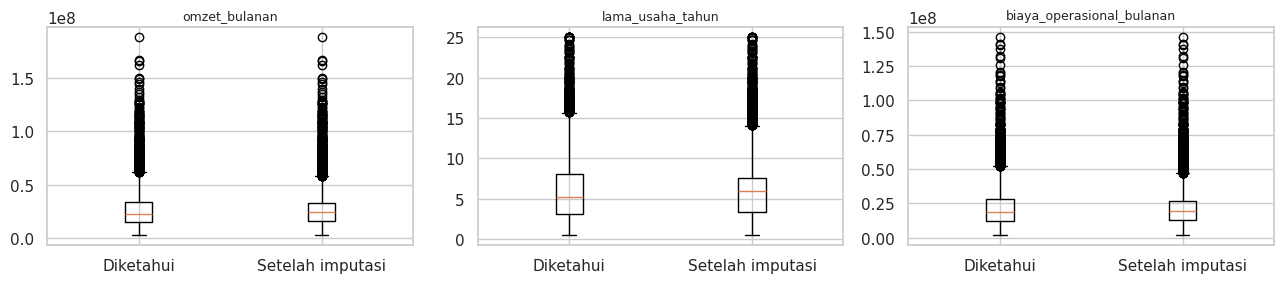

In [93]:
imputation_fold_parameters=[]
for fold,(tr,va) in enumerate(FOLDS,1):
    fitted=GroupImputer(chosen_imputation).fit(X_train.iloc[tr])
    for sector,value in fitted.group_['omzet_bulanan'].items():
        imputation_fold_parameters.append({'fold':fold,'sektor':sector,'parameter_omzet_sektor':value,'fallback_omzet':fitted.global_['omzet_bulanan'],'n_training':len(tr)})
parameters=pd.DataFrame(imputation_fold_parameters)
display(parameters)
AUDIT['imputation_fold_parameters']=parameters
fig,axes=plt.subplots(1,3,figsize=(13,3))
for ax,c in zip(axes,['omzet_bulanan','lama_usaha_tahun','biaya_operasional_bulanan']):
    ax.boxplot([X_train[c].dropna(),clean.loc[X_train.index,c]],tick_labels=['Diketahui','Setelah imputasi'])
    ax.set_title(c,fontsize=9)
plt.tight_layout();plt.show()

## 5A. Apakah informasi antarfitur terlalu tumpang tindih?

Kita belum langsung membuang plafon atau omzet. Kita akan melihat hubungan antarfitur, mencoba beberapa pilihan, lalu membandingkan prediksi dan penjelasannya. **Multikolinearitas** berarti suatu fitur banyak membawa informasi yang juga dibawa fitur lain. Akibatnya, model dapat tetap memprediksi dengan baik tetapi pembagian peran antarfitur bisa berubah-ubah saat data latihan berubah.

Urutannya: **lihat heatmap → ukur VIF → uji lima pilihan fitur → bandingkan precision/recall → periksa SHAP/LIME → pilih**. Bagian ini memakai data train dan pembagian lima fold yang sudah dibuat. Data tidak dimuat atau dibagi ulang.

Sebelum melihat hasil, kita menetapkan batas praktis: penurunan F1 paling banyak 0,005; precision/recall paling banyak 1 poin persentase; VIF maksimum 5; perubahan SHAP saat latihan diulang tidak lebih dari 1,10 kali model asli. Di antara yang lolos, pilih F1 tertinggi lalu precision. Ini **aturan proyek yang dapat didiskusikan**, bukan standar universal atau bukti kesetaraan statistik. Kita juga mencoba batas yang lebih ketat dan lebih longgar.

LIME dinilai dari seberapa dekat ia meniru model. Jika hasilnya kurang baik, kita laporkan apa adanya; tidak memaksa grafik LIME mendukung pilihan kita.

In [94]:
import statsmodels.api as sm
IMPUTATION=chosen_imputation
NumericSectorImputer=GroupImputer  # Gunakan metode hasil pengujian sebelumnya.
train_filled=imputer_audit.transform(X_train)
F1_TOL=.005
PRECISION_TOL=.01
RECALL_TOL=.01
VIF_LIMIT=5.
SHAP_DRIFT_FACTOR=1.10
BOOTSTRAPS=12
LIME_SEEDS=[42,43,44]
print('Imputasi yang dipakai semua kandidat:',IMPUTATION)
print('Train/fold tetap:',len(X_train),len(FOLDS))

Imputasi yang dipakai semua kandidat: mean_sector
Train/fold tetap: 7888 5


### 5A.1 Melihat hubungan antarfitur

Omzet, biaya, dan plafon dapat sama-sama mencerminkan ukuran usaha. Jika informasinya sangat mirip, pembagian pengaruh pada koefisien bisa kurang stabil. Kita mulai dari heatmap, kemudian VIF, sebelum menentukan apakah ada fitur yang perlu diganti atau dikeluarkan.

### 5A.2 Membaca heatmap korelasi

Angka korelasi berkisar −1 sampai 1. Mendekati +1 berarti dua fitur cenderung naik bersama; mendekati −1 berarti satu naik saat yang lain turun; dekat 0 berarti hubungan yang diukur lemah.

Pearson melihat hubungan garis lurus, sedangkan Spearman membandingkan urutan tinggi/rendah. Heatmap ini membandingkan **fitur dengan fitur**, bukan menjelaskan penyebab gagal bayar. Warna kuat memberi alasan untuk memeriksa, bukan otomatis membuang kolom.

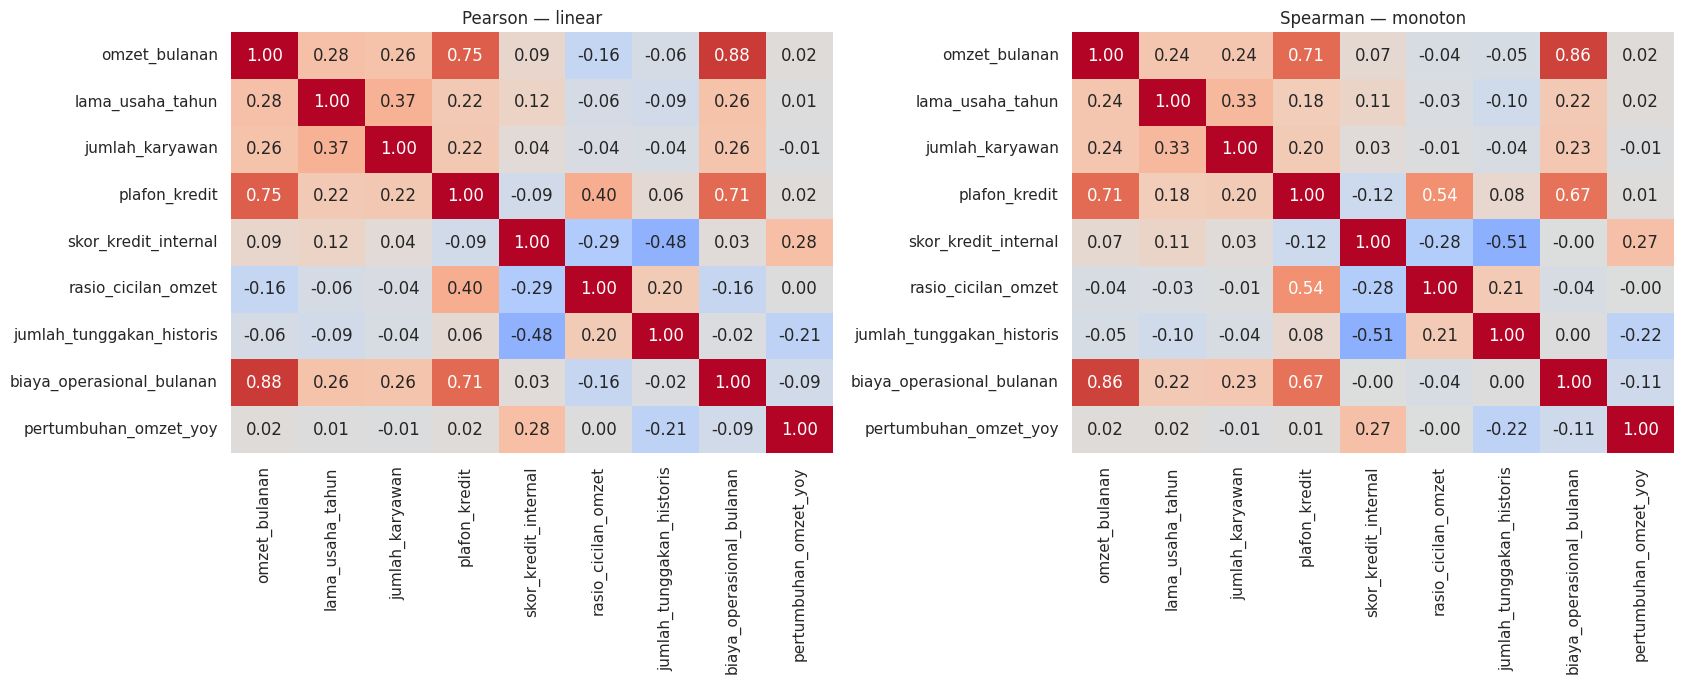

In [95]:
pearson=train_filled[NUM].corr(method='pearson');spearman=train_filled[NUM].corr(method='spearman')
fig,axes=plt.subplots(1,2,figsize=(17,7))
for ax,matrix,title in zip(axes,[pearson,spearman],['Pearson — linear','Spearman — monoton']):
    sns.heatmap(matrix,annot=True,fmt='.2f',vmin=-1,vmax=1,center=0,cmap='coolwarm',ax=ax,cbar=False)
    ax.set_title(title)
plt.tight_layout();plt.show()
AUDIT['pearson_original']=pearson.reset_index(names='fitur');AUDIT['spearman_original']=spearman.reset_index(names='fitur')


### 5A.3 Memahami VIF dengan contoh

Bayangkan kita menebak omzet memakai fitur lain. Jika omzet hampir bisa ditebak dari kombinasi fitur tersebut, ia membawa banyak informasi yang sudah ada. VIF merangkum tingkat tumpang tindih itu.

VIF=1 berarti tidak ada hubungan linear dengan kombinasi fitur lain; makin besar berarti makin banyak yang tumpang tindih. Kita memakai >5 sebagai tanda perlu ditinjau. Rumusnya 1/(1−R²), dengan R² berasal dari percobaan menebak satu fitur memakai fitur lain, **bukan dari prediksi gagal bayar**. StandardScaler tidak menghilangkan masalah ini.

In [96]:
def vif_table(X):
    X=pd.DataFrame(X).astype(float)
    std=X.std(ddof=0)
    nonconstant=std>1e-12
    Z=(X.loc[:,nonconstant]-X.loc[:,nonconstant].mean())/std[nonconstant]
    rows=[]
    for c in X.columns:
        if not nonconstant[c]:
            rows.append({'fitur':c,'vif':np.inf,'r2_aux':np.nan,'status':'konstan'});continue
        y=Z[c].to_numpy();others=Z.drop(columns=c).to_numpy()
        design=np.column_stack([np.ones(len(X)),others])
        residual=y-design@np.linalg.lstsq(design,y,rcond=None)[0]
        unexplained=(residual@residual)/(y@y)
        vif=np.inf if unexplained<1e-12 else max(1.,1./unexplained)
        rows.append({'fitur':c,'vif':vif,'r2_aux':1-unexplained,'status':'linear dependency' if not np.isfinite(vif) else 'tinggi' if vif>5 else 'tidak melewati 5'})
    return pd.DataFrame(rows).sort_values('vif',ascending=False,kind='stable').reset_index(drop=True)
from statsmodels.stats.outliers_influence import variance_inflation_factor
z=(train_filled[NUM]-train_filled[NUM].mean())/train_filled[NUM].std(ddof=0)
reference=sm.add_constant(z)
expected={c:variance_inflation_factor(reference.to_numpy(),i+1) for i,c in enumerate(NUM)}
computed=vif_table(train_filled[NUM]).set_index('fitur').vif
assert np.allclose(computed.loc[NUM],[expected[c] for c in NUM])
print('PASS: VIF cocok dengan statsmodels pada fitur baseline.')

vif_baseline=vif_table(train_filled[NUM])
display(vif_baseline);AUDIT['vif_baseline']=vif_baseline


PASS: VIF cocok dengan statsmodels pada fitur baseline.


,fitur,vif,r2_aux,status
0,plafon_kredit,7.328247,0.863542,tinggi
1,omzet_bulanan,7.300868,0.863030,tinggi
2,biaya_operasional_bulanan,5.055031,0.802177,tinggi
3,rasio_cicilan_omzet,3.268988,0.694095,tidak melewati 5
4,skor_kredit_internal,1.468906,0.319221,tidak melewati 5
5,jumlah_tunggakan_historis,1.327577,0.246748,tidak melewati 5
6,lama_usaha_tahun,1.229847,0.186891,tidak melewati 5
7,jumlah_karyawan,1.205550,0.170503,tidak melewati 5
8,pertumbuhan_omzet_yoy,1.153440,0.133028,tidak melewati 5


### 5A.4 Menentukan lima pilihan yang akan diuji

| Pilihan | Fitur yang berubah | Pertanyaan yang diuji |
|---|---|---|
| A_asli | Sembilan fitur asli | Bagaimana hasil tanpa pengurangan? |
| B_tanpa_plafon | Plafon keluar dari predictor PD | Apakah informasi fasilitas sudah cukup terwakili fitur lain? |
| C_tanpa_omzet | Omzet keluar dari predictor PD | Apakah kapasitas usaha sudah cukup terwakili? |
| D_tanpa_biaya | Biaya nominal keluar dari predictor PD | Apakah biaya menambah informasi selain omzet? |
| E_skala_dan_rasio | Plafon dan biaya nominal keluar; rasio biaya/omzet masuk | Apakah omzet untuk ukuran usaha dan rasio untuk tekanan biaya lebih jelas? |

Daftar tiap pilihan tetap sama pada kelima fold. Rasio dihitung setelah imputasi: misalnya biaya 15 juta/omzet 20 juta =75%. Kita tidak menyingkirkan fitur hanya karena korelasi dengan target lemah atau p-value besar.

### 5A.5 Menyiapkan model pembanding

Semua pilihan memakai metode imputasi yang sudah menang, StandardScaler, dan LR dengan pengaturan sama. Hanya daftar/bentuk fitur yang berubah. Fungsi berikut memastikan urutan tersebut diulang pada setiap kelompok latihan.

Kolom mentah tetap tersedia untuk menghitung rasio atau mengisi nilai kosong, meski tidak semuanya diteruskan ke model.

In [97]:
RATIO='rasio_biaya_operasional_pct'
SPECS={
'A_asli':NUM,
'B_tanpa_plafon':[c for c in NUM if c!='plafon_kredit'],
'C_tanpa_omzet':[c for c in NUM if c!='omzet_bulanan'],
'D_tanpa_biaya':[c for c in NUM if c!='biaya_operasional_bulanan'],
'E_skala_dan_rasio':[c for c in NUM if c not in ['plafon_kredit','biaya_operasional_bulanan']]+[RATIO]}
class FixedFinancialFeatures(BaseEstimator,TransformerMixin):
    def __init__(self,columns=()):self.columns=columns
    def fit(self,X,y=None):return self
    def transform(self,X):
        z=X[NUM].copy()
        if RATIO in self.columns:
            if (z.omzet_bulanan<=0).any():raise ValueError('Omzet nonpositif, rasio invalid')
            z[RATIO]=100*z.biaya_operasional_bulanan/z.omzet_bulanan
        return z[list(self.columns)].copy()
def make_fixed(name):
    return Pipeline([('imputer',NumericSectorImputer(IMPUTATION)),('features',FixedFinancialFeatures(tuple(SPECS[name]))),
    ('scaler',StandardScaler()),('model',LogisticRegression(C=1,solver='liblinear',max_iter=3000,random_state=SEED))])
def raw_model_matrix(pipe,X):return pipe.named_steps['features'].transform(pipe.named_steps['imputer'].transform(X))
def model_matrix(pipe,X):return pipe.named_steps['scaler'].transform(raw_model_matrix(pipe,X))
def score_metrics(y,p):
    pred=(p>=.5).astype(int);tn,fp,fn,tp=confusion_matrix(y,pred,labels=[0,1]).ravel()
    return {'accuracy':accuracy_score(y,pred),'precision':precision_score(y,pred,zero_division=0),'recall':recall_score(y,pred),
    'f1':f1_score(y,pred),'f05':fbeta_score(y,pred,beta=.5),'ap':average_precision_score(y,p),'roc_auc':roc_auc_score(y,p),
    'tn':tn,'fp':fp,'fn':fn,'tp':tp}
print({k:len(v) for k,v in SPECS.items()})


{'A_asli': 9, 'B_tanpa_plafon': 8, 'C_tanpa_omzet': 8, 'D_tanpa_biaya': 8, 'E_skala_dan_rasio': 8}


### 5A.6 Membandingkan VIF sebelum dan sesudah

Tabel memperlihatkan VIF tiap fitur pada lima pilihan. Kolom yang kosong berarti fitur memang tidak dipakai pada pilihan tersebut. Kita juga melihat VIF paling tinggi pada tiap model.

Angka audit ini dihitung dari train. VIF lebih rendah belum berarti prediksi atau penjelasan lebih baik; keduanya diperiksa sesudahnya.

In [98]:
vif_rows=[]
for name,columns in SPECS.items():
    xx=FixedFinancialFeatures(tuple(columns)).transform(train_filled)
    vt=vif_table(xx);vt['candidate']=name;vif_rows.append(vt)
vif_all=pd.concat(vif_rows,ignore_index=True)
display(vif_all.pivot(index='fitur',columns='candidate',values='vif'))
AUDIT['vif_all_fixed']=vif_all
max_vif=vif_all.groupby('candidate').vif.max()
display(max_vif.to_frame('max_vif'))


candidate,A_asli,B_tanpa_plafon,C_tanpa_omzet,D_tanpa_biaya,E_skala_dan_rasio
fitur,,,,,
biaya_operasional_bulanan,5.055031,4.558130,3.986093,NaN,NaN
jumlah_karyawan,1.205550,1.203845,1.204963,1.204862,1.202910
jumlah_tunggakan_historis,1.327577,1.327574,1.327573,1.327577,1.327711
lama_usaha_tahun,1.229847,1.229783,1.226543,1.228895,1.229113
omzet_bulanan,7.300868,4.582614,NaN,5.757025,1.188753
pertumbuhan_omzet_yoy,1.153440,1.147603,1.143647,1.107405,1.138320
plafon_kredit,7.328247,NaN,4.599799,6.607893,NaN
rasio_biaya_operasional_pct,NaN,NaN,NaN,NaN,1.080021
rasio_cicilan_omzet,3.268988,1.135828,2.420538,3.017163,1.141318


,max_vif
candidate,
A_asli,7.328247
B_tanpa_plafon,4.582614
C_tanpa_omzet,4.599799
D_tanpa_biaya,6.607893
E_skala_dan_rasio,1.467683


### 5A.7 Menguji precision, recall, dan F1

Lima pilihan × lima fold menghasilkan 25 pelatihan LR. Pada setiap putaran, hanya empat fold yang menentukan imputasi dan scaler; satu fold menerima prediksi.

Semua memakai threshold 0,50 agar perbedaan terutama berasal dari fitur. Kita belum memakai threshold terbaik model lama pada pilihan fitur baru. `delta` menunjukkan selisih terhadap A_asli.

In [99]:
fold_results=[];fitted_cv={};oof={};coefficients=[]
for name in SPECS:
    fitted_cv[name]=[];probability=np.empty(len(y_train))
    for fold,(tr,va) in enumerate(FOLDS,1):
        pipe=make_fixed(name).fit(X_train.iloc[tr],y_train.iloc[tr]);fitted_cv[name].append(pipe)
        p=pipe.predict_proba(X_train.iloc[va])[:,1];probability[va]=p
        fold_results.append({'candidate':name,'fold':fold,**score_metrics(y_train.iloc[va],p)})
        for c,b in zip(SPECS[name],pipe.named_steps['model'].coef_[0]):coefficients.append({'candidate':name,'fold':fold,'fitur':c,'coefficient_per_sd':b})
    oof[name]=probability
fold_results=pd.DataFrame(fold_results);coefficients=pd.DataFrame(coefficients)
AUDIT['cv_fold_results']=fold_results;AUDIT['cv_coefficients']=coefficients
comparison=fold_results.groupby('candidate')[['accuracy','precision','recall','f1','f05','ap','roc_auc']].mean().add_suffix('_cv')
comparison['f1_std']=fold_results.groupby('candidate').f1.std()
comparison['max_vif']=max_vif;comparison['n_features']=[len(SPECS[n]) for n in comparison.index]
base=comparison.loc['A_asli']
for m in ['f1','precision','recall']:comparison['delta_'+m]=comparison[m+'_cv']-base[m+'_cv']
display(comparison)
AUDIT['performance_comparison']=comparison.reset_index()


,accuracy_cv,precision_cv,recall_cv,f1_cv,f05_cv,ap_cv,roc_auc_cv,f1_std,max_vif,n_features,delta_f1,delta_precision,delta_recall
candidate,,,,,,,,,,,,,
A_asli,0.954615,0.859081,0.797196,0.826163,0.845376,0.917680,0.983813,0.018157,7.328247,9,0.000000,0.000000,0.000000
B_tanpa_plafon,0.955249,0.863133,0.797196,0.828137,0.848584,0.917734,0.983811,0.019136,4.582614,8,0.001974,0.004052,0.000000
C_tanpa_omzet,0.954488,0.858259,0.797196,0.825753,0.844719,0.917909,0.983854,0.017795,4.599799,8,-0.000410,-0.000822,0.000000
D_tanpa_biaya,0.954741,0.860311,0.796262,0.826294,0.846163,0.917404,0.983776,0.022090,6.607893,8,0.000132,0.001230,-0.000935
E_skala_dan_rasio,0.955122,0.861343,0.798131,0.827864,0.847447,0.917821,0.983811,0.020819,1.467683,8,0.001701,0.002261,0.000935


### 5A.8 Memeriksa apakah kenaikan terjadi di banyak fold

Rata-rata dapat naik hanya karena satu putaran sangat baik. Karena itu, tabel berikut menampilkan precision, recall, F1, FP, dan FN setiap putaran. Delta positif berarti lebih tinggi daripada model asli pada fold yang sama.

Grafik memperbesar rentang sumbu agar selisih kecil terlihat. Selisih kecil belum membuktikan perbaikan yang pasti atau besar secara bisnis.

,candidate,fold,f1,precision,recall,fp,fn,delta_f1,delta_precision,delta_recall
0,A_asli,1,0.797954,0.881356,0.728972,21,58,0.000000,0.000000,0.000000
1,A_asli,2,0.841121,0.841121,0.841121,34,34,0.000000,0.000000,0.000000
2,A_asli,3,0.834532,0.857143,0.813084,29,40,0.000000,0.000000,0.000000
3,A_asli,4,0.818182,0.838235,0.799065,33,43,0.000000,0.000000,0.000000
4,A_asli,5,0.839024,0.877551,0.803738,24,42,0.000000,0.000000,0.000000
5,B_tanpa_plafon,1,0.797954,0.881356,0.728972,21,58,0.000000,0.000000,0.000000
6,B_tanpa_plafon,2,0.847059,0.853081,0.841121,31,34,0.005937,0.011959,0.000000
7,B_tanpa_plafon,3,0.834532,0.857143,0.813084,29,40,0.000000,0.000000,0.000000
8,B_tanpa_plafon,4,0.822115,0.846535,0.799065,31,43,0.003934,0.008299,0.000000
9,B_tanpa_plafon,5,0.839024,0.877551,0.803738,24,42,0.000000,0.000000,0.000000


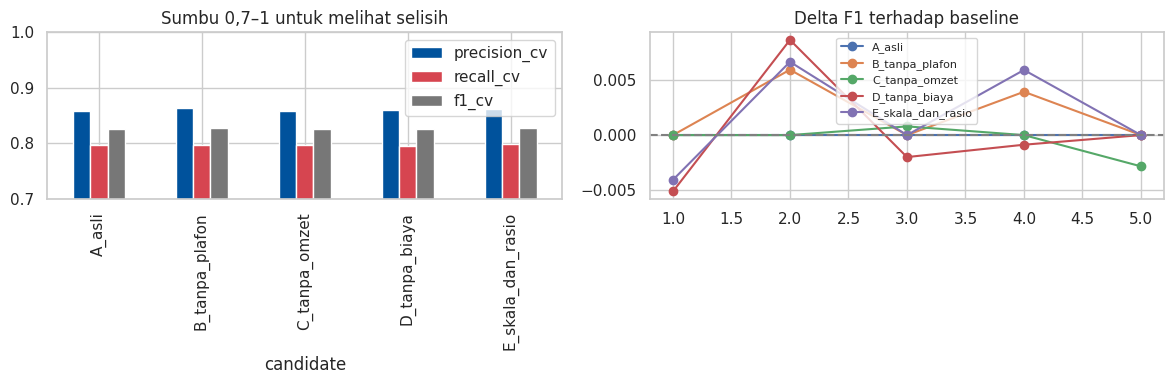

In [100]:
paired=fold_results[['candidate','fold','f1','precision','recall','fp','fn']].copy()
baseline_fold=fold_results.loc[fold_results.candidate=='A_asli'].set_index('fold')
for m in ['f1','precision','recall']:paired['delta_'+m]=paired[m]-paired.fold.map(baseline_fold[m])
display(paired);AUDIT['paired_fold_deltas']=paired
fig,axes=plt.subplots(1,2,figsize=(12,4))
comparison[['precision_cv','recall_cv','f1_cv']].plot.bar(ax=axes[0],color=['#00529C','#D64550','#777777']);axes[0].set_ylim(.7,1);axes[0].set_title('Sumbu 0,7–1 untuk melihat selisih')
for name,g in paired.groupby('candidate'):axes[1].plot(g.fold,g.delta_f1,marker='o',label=name)
axes[1].axhline(0,color='gray',ls='--');axes[1].set_title('Delta F1 terhadap baseline');axes[1].legend(fontsize=8);plt.tight_layout();plt.show()


### 5A.9 Membandingkan penjelasan pada debitur yang sama

Kita memakai model dari putaran pertama untuk semua pilihan. Debitur yang dijelaskan berasal dari kelompok validasi pertama, sehingga tidak dipakai melatih model tersebut. Acuan SHAP berasal dari 100 debitur latihan yang sama.

Tiga contoh dipilih dari PD model asli yang paling dekat 10%, 50%, dan 90%, tanpa memilih berdasarkan label aktual. Dengan begitu, perbandingan tidak sengaja mencari kasus yang menguntungkan satu model.

Yang dilihat bukan sekadar grafik lebih pendek: apakah alasan berubah banyak ketika latihan diulang, apakah PD berubah, dan apakah LIME cukup dekat meniru model. Korelasi dan SHAP/LIME tetap bukan bukti sebab-akibat.

### 5A.10 Menyimpan debitur dan data acuan

Kita simpan ID tiga contoh, 100 debitur acuan dari latihan, dan 150 debitur validasi untuk pemeriksaan kestabilan. Semua model dinilai pada orang yang sama, walaupun nilai imputasi/scalernya mengikuti masing-masing model.

In [101]:
tr0,va0=FOLDS[0]
train_ref=X_train.iloc[tr0];y_ref=y_train.iloc[tr0];validation_ref=X_train.iloc[va0]
rng=np.random.default_rng(SEED)
background_ids=rng.choice(len(train_ref),100,replace=False)
background_raw=train_ref.iloc[background_ids]
reference_pipes={n:fitted_cv[n][0] for n in SPECS}
baseline_pd=reference_pipes['A_asli'].predict_proba(validation_ref)[:,1]
case_positions=[int(np.argmin(np.abs(baseline_pd-t))) for t in [.1,.5,.9]]
assert len(set(case_positions))==3
cases=validation_ref.iloc[case_positions]
case_ids=df.loc[cases.index,'id_debitur'].tolist()
anchor_positions=rng.choice(len(validation_ref),min(150,len(validation_ref)),replace=False)
anchor=validation_ref.iloc[anchor_positions]
case_audit=pd.DataFrame({'id_debitur':case_ids,'baseline_pd':baseline_pd[case_positions],'actual':y_train.iloc[va0].iloc[case_positions].values})
for n,pipe in reference_pipes.items():case_audit['pd_'+n]=pipe.predict_proba(cases)[:,1]
display(case_audit);AUDIT['common_cases']=case_audit
AUDIT['background_ids']=df.loc[background_raw.index,['id_debitur']].reset_index(drop=True)


,id_debitur,baseline_pd,actual,pd_A_asli,pd_B_tanpa_plafon,pd_C_tanpa_omzet,pd_D_tanpa_biaya,pd_E_skala_dan_rasio
0,UMKM-07378,0.099776,0,0.099776,0.100431,0.099228,0.103563,0.098789
1,UMKM-05370,0.493813,0,0.493813,0.488124,0.481460,0.430033,0.545610
2,UMKM-06794,0.901175,1,0.901175,0.899828,0.902492,0.900904,0.900410


### 5A.11 Membandingkan SHAP secara keseluruhan

Setiap model mendapat grafik pada debitur validasi yang sama. Posisi kanan/kiri menunjukkan dorongan terhadap risiko; warna merah/biru menunjukkan nilai fitur tinggi/rendah. Jangan mengartikan merah selalu buruk.

Fitur yang kontribusinya besar lebih sering memengaruhi keluaran model. Perubahan urutan fitur setelah satu fitur dibuang dapat berarti informasi berpindah ke fitur lain; bukan otomatis penjelasan lebih benar.

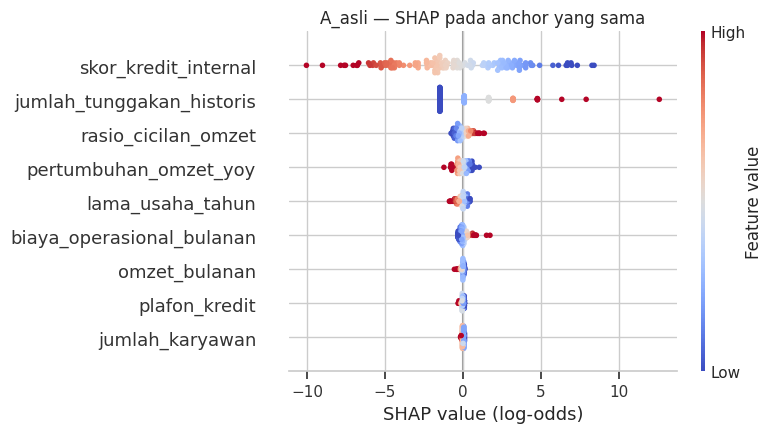

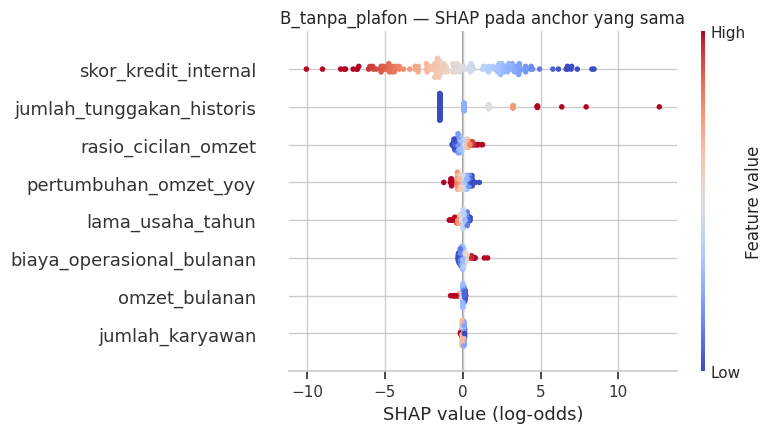

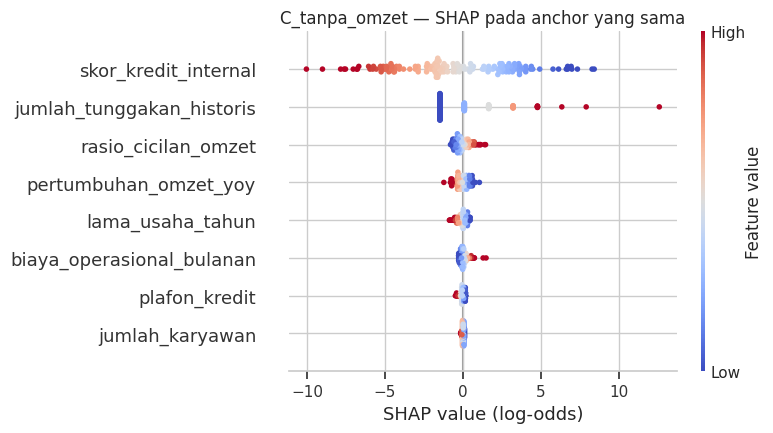

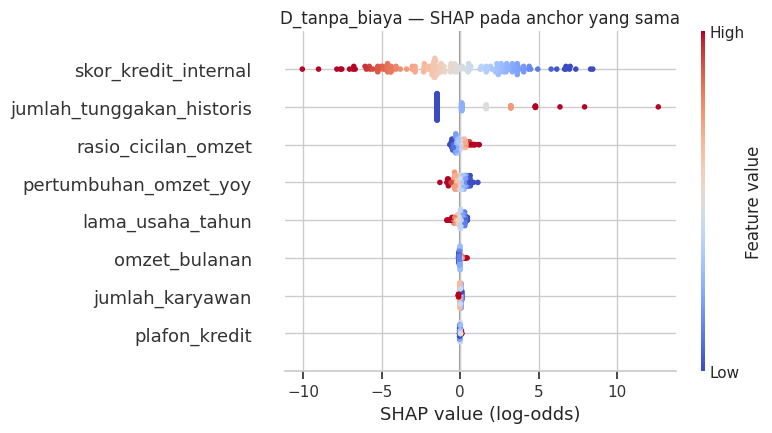

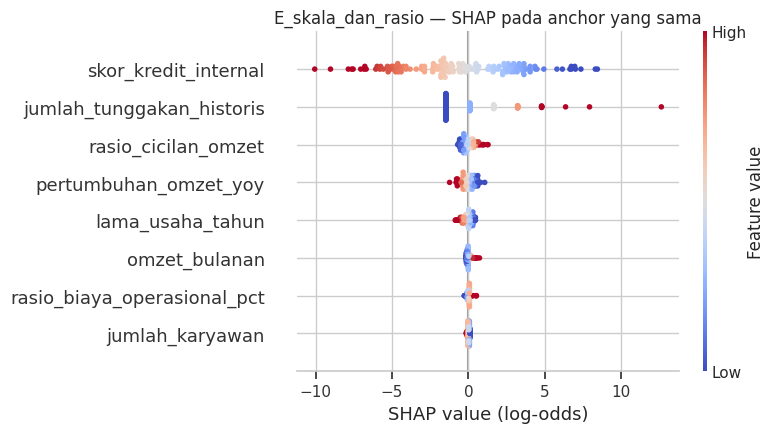

candidate,A_asli,B_tanpa_plafon,C_tanpa_omzet,D_tanpa_biaya,E_skala_dan_rasio
fitur,,,,,
biaya_operasional_bulanan,0.190142,0.173427,0.162292,NaN,NaN
jumlah_karyawan,0.047997,0.049252,0.047533,0.043118,0.048002
jumlah_tunggakan_historis,1.628721,1.630045,1.628542,1.630605,1.629798
lama_usaha_tahun,0.219294,0.219690,0.220805,0.217941,0.218449
omzet_bulanan,0.074743,0.107891,NaN,0.061502,0.100170
pertumbuhan_omzet_yoy,0.295852,0.297675,0.298328,0.316503,0.300292
plafon_kredit,0.060867,NaN,0.098434,0.020114,NaN
rasio_biaya_operasional_pct,NaN,NaN,NaN,NaN,0.070887
rasio_cicilan_omzet,0.368273,0.337732,0.388632,0.324305,0.343185


In [102]:
import shap
shap_objects={};global_shap_rows=[]
for name,pipe in reference_pipes.items():
    zz=model_matrix(pipe,anchor);bg=model_matrix(pipe,background_raw)
    explainer=shap.LinearExplainer(pipe.named_steps['model'],shap.maskers.Independent(bg,max_samples=100))
    explanation=explainer(zz);shap_objects[name]=explainer
    for c,value in zip(SPECS[name],np.abs(explanation.values).mean(0)):global_shap_rows.append({'candidate':name,'fitur':c,'mean_abs_shap':value})
    shap.summary_plot(explanation.values,zz,feature_names=SPECS[name],cmap='coolwarm',show=False,plot_size=(8,4.5))
    plt.title(name+' — SHAP pada anchor yang sama');plt.xlabel('SHAP value (log-odds)');plt.tight_layout();plt.show()
global_shap=pd.DataFrame(global_shap_rows);AUDIT['global_shap_comparison']=global_shap
display(global_shap.pivot(index='fitur',columns='candidate',values='mean_abs_shap'))


### 5A.12 Membandingkan SHAP untuk tiga contoh

Untuk setiap debitur, grafik antar model memakai rentang sumbu yang sama agar perbandingan tidak menyesatkan. Lihat apakah faktor utama dan arah kontribusinya masih masuk akal.

SHAP di sini memakai skala log-odds sebelum diubah menjadi PD, bukan poin persentase. Script memeriksa bahwa semua kontribusi ditambah acuan menghasilkan kembali keluaran model.

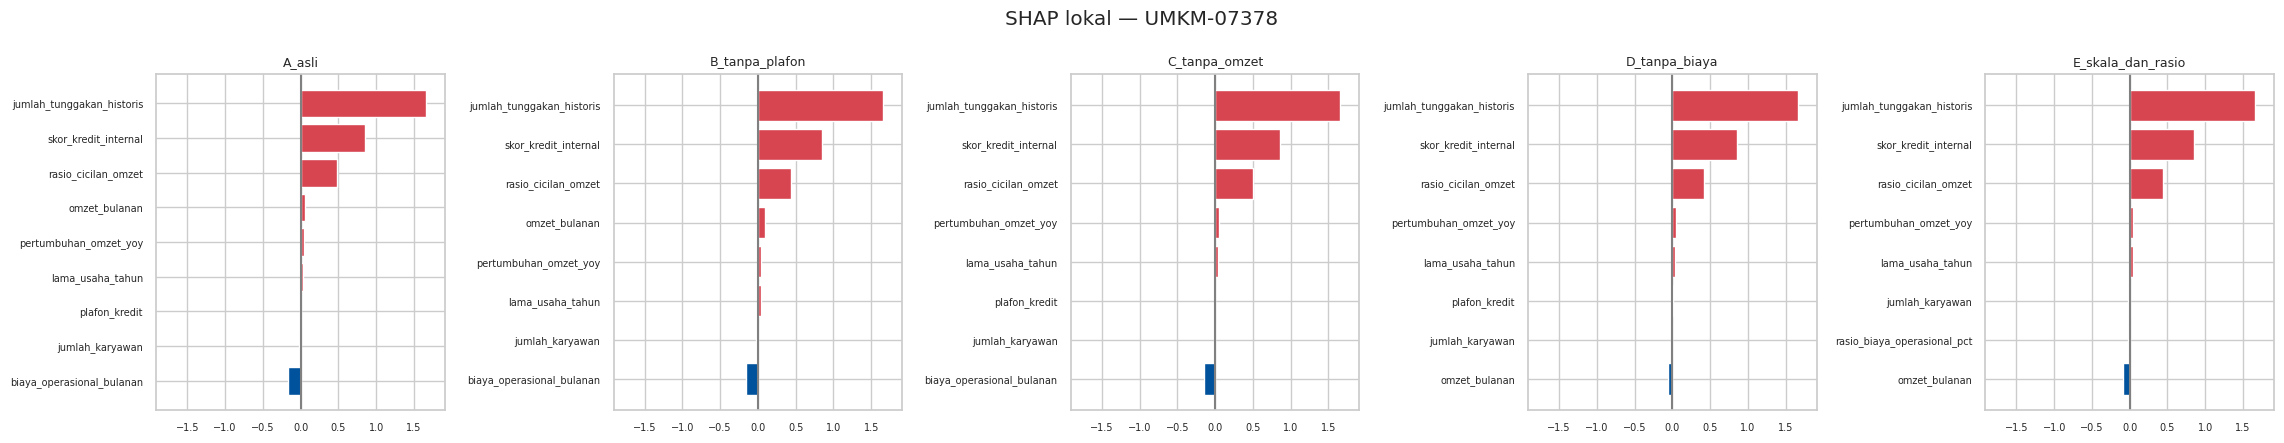

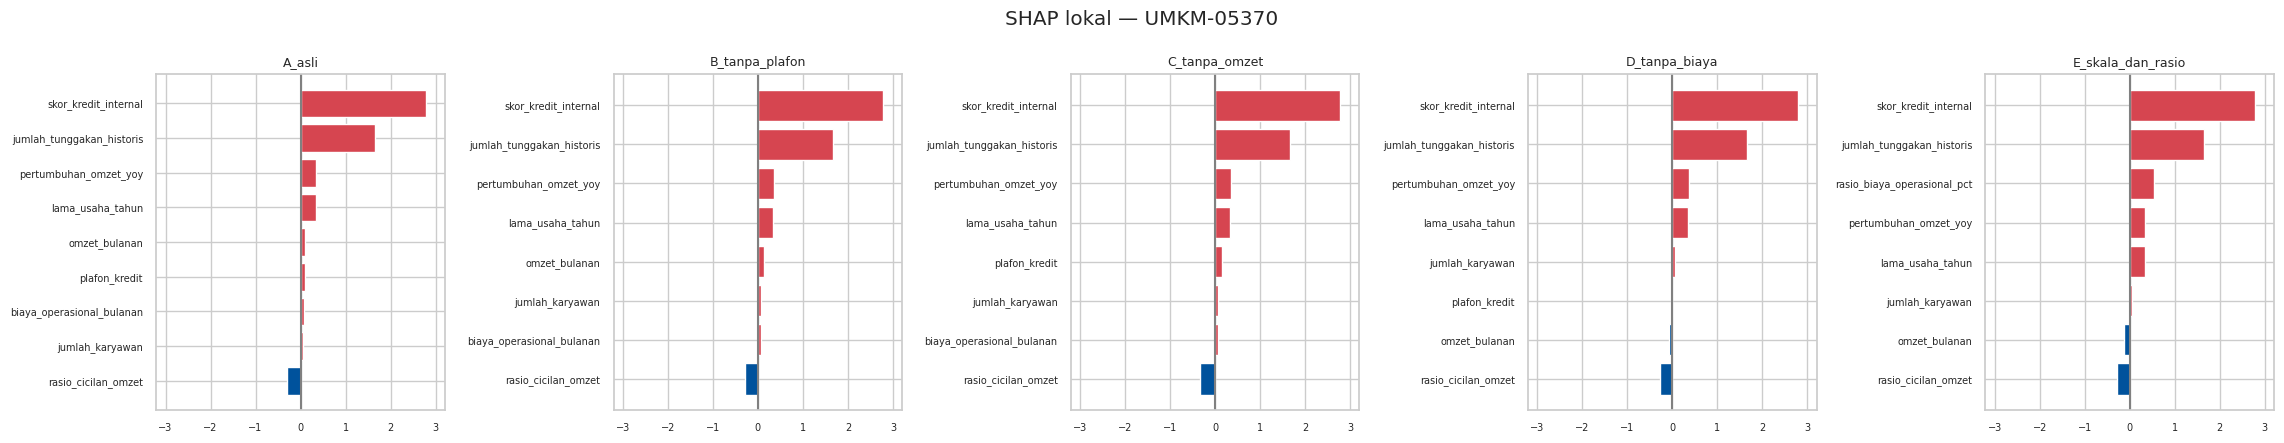

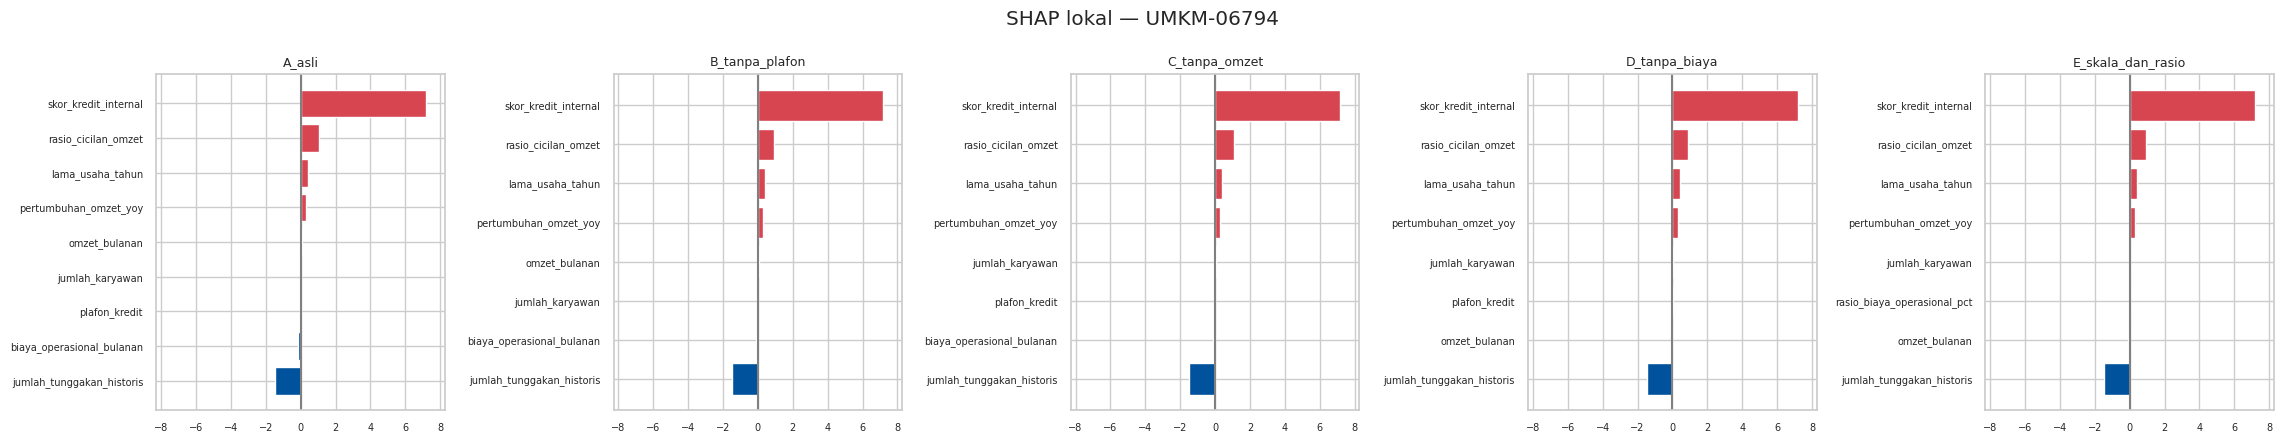

In [103]:
local_rows=[]
for name,pipe in reference_pipes.items():
    zz=model_matrix(pipe,cases);ex=shap_objects[name](zz)
    for j,case_id in enumerate(case_ids):
        assert np.isclose(ex.base_values[j]+ex.values[j].sum(),pipe.named_steps['model'].decision_function(zz[j:j+1])[0])
        for c,value in zip(SPECS[name],ex.values[j]):local_rows.append({'candidate':name,'id_debitur':case_id,'fitur':c,'shap':value})
local_shap=pd.DataFrame(local_rows);AUDIT['local_shap_comparison']=local_shap
for case_id in case_ids:
    subset=local_shap.loc[local_shap.id_debitur==case_id];limit=max(1,subset.shap.abs().max()*1.15)
    fig,axes=plt.subplots(1,len(SPECS),figsize=(23,4.5))
    for ax,name in zip(axes,SPECS):
        t=subset.loc[subset.candidate==name].sort_values('shap');ax.barh(t.fitur,t.shap,color=np.where(t.shap>0,'#D64550','#00529C'))
        ax.set_xlim(-limit,limit);ax.axvline(0,color='gray');ax.set_title(name,fontsize=9);ax.tick_params(labelsize=7)
    fig.suptitle('SHAP lokal — '+case_id);plt.tight_layout();plt.show()


### 5A.13 Apakah penjelasan tetap mirip jika data latihan sedikit berubah?

Kita melakukan **bootstrap**: mengambil sampel dari kelompok latihan dengan pengembalian. Artinya, satu baris boleh terambil lebih dari sekali, sedangkan sebagian baris tidak terambil. Model kemudian dilatih ulang.

Proses diulang 12 kali dengan pilihan sampel yang sama untuk semua kandidat. Debitur validasi yang diperiksa tetap sama dan tidak masuk latihan. Tujuannya melihat apakah sedikit perubahan isi latihan membuat alasan model berubah drastis. Dua belas pengulangan adalah pemeriksaan awal proyek, bukan jaminan kestabilan di semua kondisi.

### 5A.14 Mengukur perubahan PD dan SHAP setelah latihan diulang

`mean_abs_pd_drift` adalah rata-rata besar perubahan PD. `relative_shap_drift` membandingkan perubahan kontribusi SHAP dengan besar kontribusi awal; makin kecil berarti pembagian kontribusi lebih stabil pada uji ini.

`top3_jaccard` mengukur kemiripan tiga faktor utama: 1 berarti sama semua, 0 berarti tidak ada yang sama. Ketiganya menjawab pertanyaan berbeda. Model dengan PD stabil masih bisa membagi kontribusi antarfiturnya secara berubah-ubah.

In [104]:
def linear_shap(pipe,X,background):
    zz=model_matrix(pipe,X);bg=model_matrix(pipe,background)
    return (zz-bg.mean(0))*pipe.named_steps['model'].coef_[0]
def top3_jaccard(a,b):
    k=min(3,a.shape[1]);aa=np.argsort(np.abs(a),axis=1)[:,-k:];bb=np.argsort(np.abs(b),axis=1)[:,-k:]
    return np.mean([len(set(x)&set(y))/len(set(x)|set(y)) for x,y in zip(aa,bb)])
reference_shap={n:linear_shap(p,anchor,background_raw) for n,p in reference_pipes.items()}
for n,p in reference_pipes.items():assert np.allclose(reference_shap[n],shap_objects[n](model_matrix(p,anchor)).values)
bootstrap_rng=np.random.default_rng(SEED+100)
bootstrap_indices=[bootstrap_rng.choice(len(train_ref),len(train_ref),replace=True) for _ in range(BOOTSTRAPS)]
stability_rows=[];coef_bootstrap=[]
for name,ref in reference_pipes.items():
    ref_pd=ref.predict_proba(anchor)[:,1];ref_sv=reference_shap[name]
    ref_scale=ref.named_steps['scaler'].scale_
    for b,indices in enumerate(bootstrap_indices,1):
        pipe=make_fixed(name).fit(train_ref.iloc[indices],y_ref.iloc[indices])
        p=pipe.predict_proba(anchor)[:,1];sv=linear_shap(pipe,anchor,background_raw)
        drift=np.abs(sv-ref_sv).sum(1).mean()/max(1e-12,np.abs(ref_sv).sum(1).mean())
        stability_rows.append({'candidate':name,'bootstrap':b,'mean_abs_pd_drift':np.abs(p-ref_pd).mean(),'relative_shap_drift':drift,'top3_jaccard':top3_jaccard(ref_sv,sv)})
        comparable_coef=pipe.named_steps['model'].coef_[0]/pipe.named_steps['scaler'].scale_*ref_scale
        for c,v in zip(SPECS[name],comparable_coef):coef_bootstrap.append({'candidate':name,'bootstrap':b,'fitur':c,'coef_reference_sd':v})
    print(name,'bootstrap selesai')
stability=pd.DataFrame(stability_rows)
stability_summary=stability.groupby('candidate')[['mean_abs_pd_drift','relative_shap_drift','top3_jaccard']].mean()
display(stability_summary)
AUDIT['bootstrap_stability']=stability;AUDIT['bootstrap_stability_summary']=stability_summary.reset_index()
coef_bootstrap=pd.DataFrame(coef_bootstrap);AUDIT['bootstrap_coefficients']=coef_bootstrap


A_asli bootstrap selesai
B_tanpa_plafon bootstrap selesai
C_tanpa_omzet bootstrap selesai
D_tanpa_biaya bootstrap selesai
E_skala_dan_rasio bootstrap selesai


,mean_abs_pd_drift,relative_shap_drift,top3_jaccard
candidate,,,
A_asli,0.005321,0.107920,0.863667
B_tanpa_plafon,0.005270,0.088125,0.873056
C_tanpa_omzet,0.005129,0.091046,0.883556
D_tanpa_biaya,0.004911,0.090703,0.890833
E_skala_dan_rasio,0.005116,0.073023,0.911667


### 5A.15 Melihat perubahan koefisien

Tabel merangkum koefisien dari pelatihan ulang, terutama fitur ukuran usaha. Koefisien disetarakan ke skala acuan yang sama agar dapat dibandingkan.

`positive_share` menunjukkan seberapa sering koefisien positif. Perubahan tanda bisa menunjukkan penjelasan yang kurang stabil; jika koefisien sangat kecil, periksa juga besarnya kontribusi sebelum menyebut masalah besar.

,candidate,fitur,mean,std,minimum,maximum,dominant_sign_share
0,A_asli,biaya_operasional_bulanan,0.325383,0.161786,0.105011,0.573351,1.000000
4,A_asli,omzet_bulanan,-0.146378,0.163977,-0.575694,0.071700,0.916667
6,A_asli,plafon_kredit,-0.063737,0.141429,-0.327177,0.150159,0.500000
9,B_tanpa_plafon,biaya_operasional_bulanan,0.297554,0.133715,0.144871,0.580806,1.000000
13,B_tanpa_plafon,omzet_bulanan,-0.174798,0.157153,-0.564609,0.027904,0.916667
17,C_tanpa_omzet,biaya_operasional_bulanan,0.256224,0.141976,0.020194,0.519132,1.000000
22,C_tanpa_omzet,plafon_kredit,-0.124924,0.131697,-0.287974,0.091414,0.750000
28,D_tanpa_biaya,omzet_bulanan,0.054807,0.137124,-0.218314,0.321964,0.750000
30,D_tanpa_biaya,plafon_kredit,0.055044,0.107526,-0.107033,0.225094,0.583333
36,E_skala_dan_rasio,omzet_bulanan,0.134926,0.079424,0.024016,0.267270,1.000000


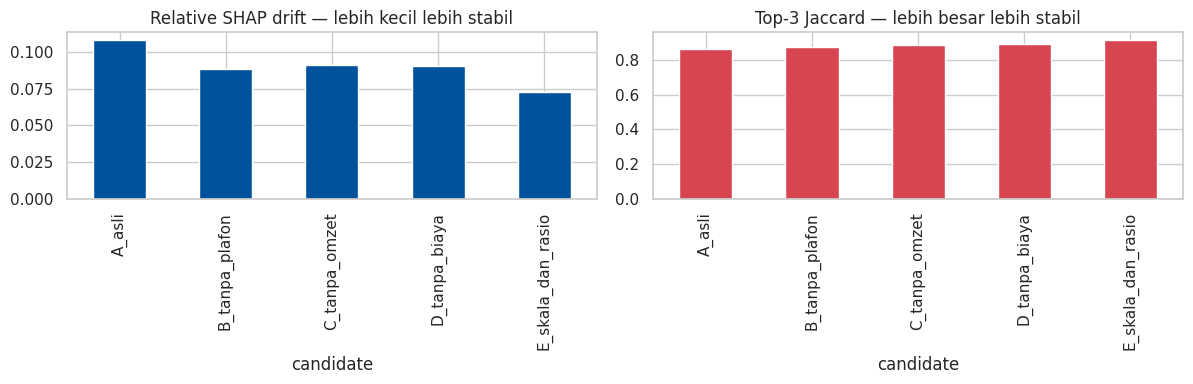

In [105]:
coef_summary=coef_bootstrap.groupby(['candidate','fitur']).coef_reference_sd.agg(mean='mean',std='std',minimum='min',maximum='max').reset_index()
signs=coef_bootstrap.assign(sign=np.sign(coef_bootstrap.coef_reference_sd)).groupby(['candidate','fitur']).sign.agg(lambda s:s.value_counts(normalize=True).max()).rename('dominant_sign_share').reset_index()
coef_summary=coef_summary.merge(signs,on=['candidate','fitur'])
display(coef_summary.loc[coef_summary.fitur.isin(['omzet_bulanan','biaya_operasional_bulanan','plafon_kredit',RATIO])])
AUDIT['coefficient_stability_summary']=coef_summary
fig,axes=plt.subplots(1,2,figsize=(12,4))
stability_summary.relative_shap_drift.plot.bar(ax=axes[0],color='#00529C');axes[0].set_title('Relative SHAP drift — lebih kecil lebih stabil')
stability_summary.top3_jaccard.plot.bar(ax=axes[1],color='#D64550');axes[1].set_title('Top-3 Jaccard — lebih besar lebih stabil')
plt.tight_layout();plt.show()


### 5A.16 LIME: memeriksa apakah penjelasan sederhana cukup mendekati model

LIME membuat variasi contoh lalu membangun pendekatan sederhana terhadap prediksi model. Agar mudah dibaca, fitur tampil dalam rupiah/tahun/persen sebelum StandardScaler.

Kita tidak cukup melihat grafiknya. **Fidelity** berarti seberapa baik pendekatan LIME meniru model. Kita ukur R² dan selisih PD pada debitur contoh. Variasi buatan LIME dapat berisi kombinasi yang jarang terjadi, terutama jika fitur saling berkaitan.

### 5A.17 Menjalankan LIME beberapa kali

Setiap kandidat menjelaskan tiga debitur dengan tiga seed pengacakan. Setiap penjelasan memakai 3.000 contoh buatan. Semua fitur disertakan agar penjelasan tidak dibatasi hanya beberapa kolom.

R² yang lebih tinggi umumnya berarti pendekatan lebih cocok terhadap prediksi pada contoh buatan tersebut. Selisih absolut kecil berarti prediksi LIME dekat dengan PD model pada debitur itu. R² rendah atau selisih besar harus dilaporkan, meski grafik terlihat meyakinkan.

In [106]:
from lime.lime_tabular import LimeTabularExplainer
lime_rows=[];lime_quality=[];lime_explanations={};lime_vectors={}
for name,pipe in reference_pipes.items():
    training=raw_model_matrix(pipe,train_ref);case_raw=raw_model_matrix(pipe,cases)
    def predict_raw(a,pipe=pipe,columns=list(training.columns)):
        return pipe.named_steps['model'].predict_proba(pipe.named_steps['scaler'].transform(pd.DataFrame(a,columns=columns)))
    for j,case_id in enumerate(case_ids):
        for seed in LIME_SEEDS:
            explainer=LimeTabularExplainer(training.to_numpy(),feature_names=list(training.columns),class_names=['Lancar','Gagal bayar'],mode='classification',discretize_continuous=True,random_state=seed)
            ex=explainer.explain_instance(case_raw.iloc[j].to_numpy(),predict_raw,labels=(1,),num_features=len(training.columns),num_samples=3000)
            vector=np.zeros(len(training.columns))
            for idx,weight in ex.local_exp[1]:vector[idx]=weight
            lime_vectors[(name,case_id,seed)]=vector
            for condition,weight in ex.as_list(label=1):lime_rows.append({'candidate':name,'id_debitur':case_id,'seed':seed,'condition':condition,'weight':weight})
            actual_pd=pipe.predict_proba(cases.iloc[j:j+1])[:,1][0]
            approx=float(np.asarray(ex.local_pred).ravel()[0])
            lime_quality.append({'candidate':name,'id_debitur':case_id,'seed':seed,'r2_local':ex.score,'model_pd':actual_pd,'surrogate_pd':approx,'abs_error_at_case':abs(approx-actual_pd)})
            if seed==LIME_SEEDS[0]:lime_explanations[(name,case_id)]=ex
    print(name,'LIME selesai')
lime_quality=pd.DataFrame(lime_quality);lime_details=pd.DataFrame(lime_rows)
AUDIT['lime_quality']=lime_quality;AUDIT['lime_conditions']=lime_details
lime_summary=lime_quality.groupby('candidate')[['r2_local','abs_error_at_case']].mean()
display(lime_summary)


A_asli LIME selesai
B_tanpa_plafon LIME selesai
C_tanpa_omzet LIME selesai
D_tanpa_biaya LIME selesai
E_skala_dan_rasio LIME selesai


,r2_local,abs_error_at_case
candidate,,
A_asli,0.378510,0.239828
B_tanpa_plafon,0.369132,0.235193
C_tanpa_omzet,0.369989,0.243383
D_tanpa_biaya,0.382291,0.254369
E_skala_dan_rasio,0.369699,0.220290


### 5A.18 Membandingkan grafik LIME dan pengaruh pengacakan

Grafik memakai debitur yang PD model aslinya dekat 50%. Merah menunjukkan kondisi yang menaikkan prediksi pendekatan LIME; biru menurunkannya.

Tabel sesudah grafik membandingkan hasil dengan seed berbeda. Penjelasan yang banyak berubah atau kurang cocok meniru model belum cukup kuat untuk dipakai sendiri sebagai alasan keputusan.

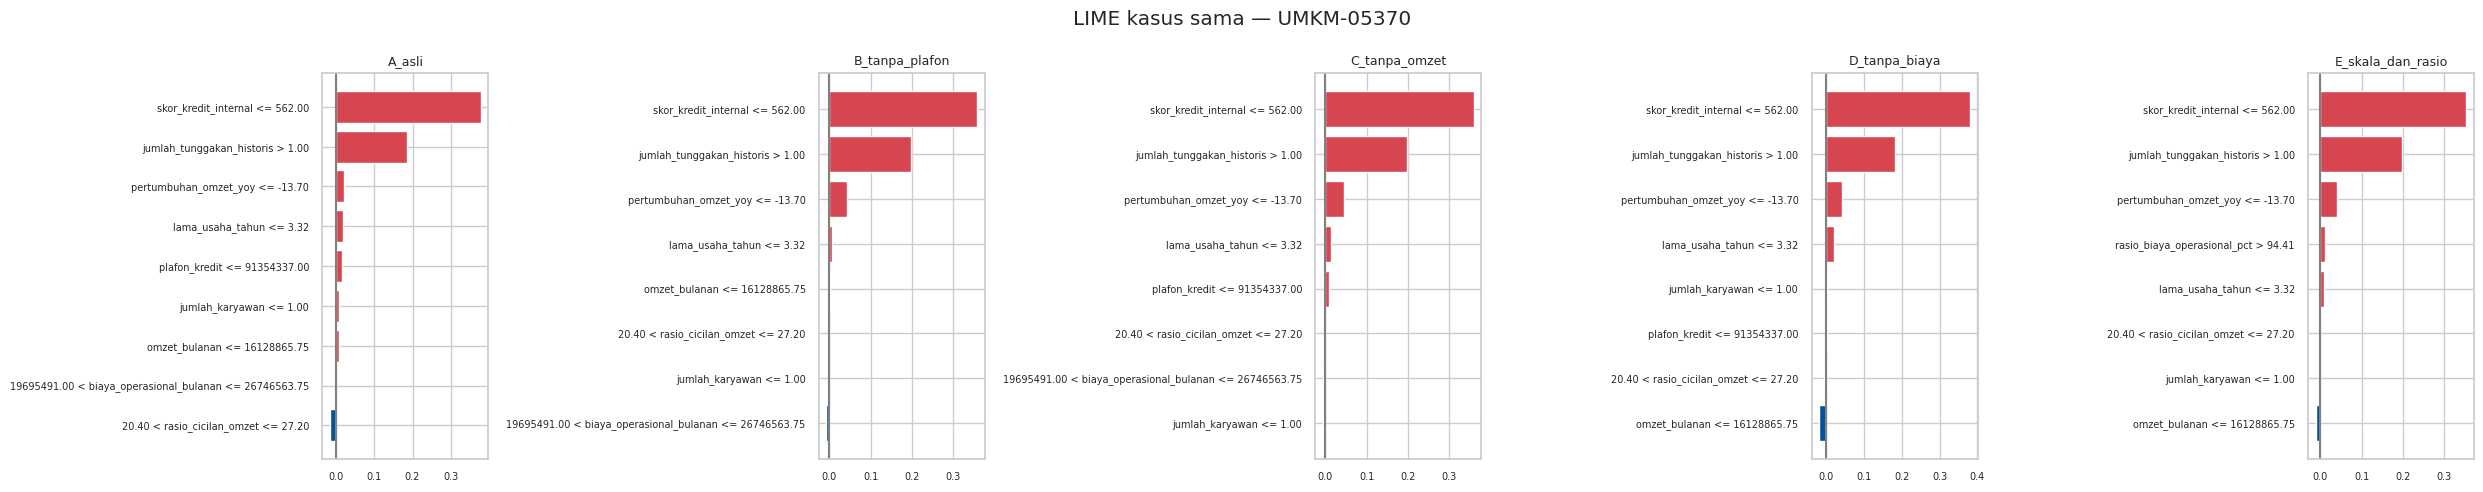

,top3_jaccard,mean_abs_weight_drift
candidate,,
A_asli,0.666667,0.007315
B_tanpa_plafon,0.666667,0.014143
C_tanpa_omzet,0.750000,0.011447
D_tanpa_biaya,0.833333,0.010533
E_skala_dan_rasio,0.750000,0.011464


In [107]:
middle_case=case_ids[1]
fig,axes=plt.subplots(1,len(SPECS),figsize=(25,5))
for ax,name in zip(axes,SPECS):
    t=lime_details.loc[(lime_details.candidate==name)&(lime_details.id_debitur==middle_case)&(lime_details.seed==LIME_SEEDS[0])].sort_values('weight')
    ax.barh(t.condition,t.weight,color=np.where(t.weight>0,'#D64550','#00529C'));ax.axvline(0,color='gray');ax.set_title(name,fontsize=9);ax.tick_params(labelsize=7)
fig.suptitle('LIME kasus sama — '+middle_case);plt.tight_layout();plt.show()
lime_stability=[]
for name in SPECS:
    for case_id in case_ids:
        ref=lime_vectors[(name,case_id,LIME_SEEDS[0])]
        for seed in LIME_SEEDS[1:]:
            v=lime_vectors[(name,case_id,seed)]
            lime_stability.append({'candidate':name,'id_debitur':case_id,'seed':seed,'top3_jaccard':top3_jaccard(ref[None,:],v[None,:]),'mean_abs_weight_drift':np.abs(v-ref).mean()})
lime_stability=pd.DataFrame(lime_stability);AUDIT['lime_seed_stability']=lime_stability
display(lime_stability.groupby('candidate')[['top3_jaccard','mean_abs_weight_drift']].mean())


### 5A.19 Memilih setelah melihat seluruh bukti

Kita gabungkan performa, VIF, kestabilan SHAP, dan kualitas pendekatan LIME. Aturan kelolosan sudah dinyatakan sebelum percobaan. Jika tidak ada kandidat yang memenuhi aturan, model asli dipertahankan dengan catatan keterbatasannya.

LIME tetap dilaporkan tetapi tidak dipaksa menjadi lebih baik. Tiga contoh belum cukup membuktikan kualitas untuk semua debitur. Penilaian apakah penjelasan mudah dipahami manusia juga perlu dibahas dengan mentor.

### 5A.20 Tabel alasan pemilihan

`performance_ok` berarti penurunan metrik masih dalam batas yang ditetapkan. `vif_ok` berarti VIF maksimum tidak melewati 5. `shap_stability_ok` berarti perubahan SHAP tidak lebih buruk daripada batas pembanding.

`eligible` berarti ketiganya terpenuhi. Dari kandidat yang lolos, pilih F1 tertinggi lalu precision. Jadi pemenang tidak harus terbaik pada setiap kolom. Model dengan VIF lebih rendah dapat tetap tidak terpilih jika pilihan lain lebih baik menurut urutan keputusan ini.

In [108]:
decision=comparison.join(stability_summary).join(lime_summary)
decision['performance_ok']=(decision.delta_f1>=-F1_TOL)&(decision.delta_precision>=-PRECISION_TOL)&(decision.delta_recall>=-RECALL_TOL)
decision['vif_ok']=decision.max_vif<=VIF_LIMIT
decision['shap_stability_ok']=decision.relative_shap_drift<=decision.loc['A_asli','relative_shap_drift']*SHAP_DRIFT_FACTOR
decision['eligible']=decision.performance_ok & decision.vif_ok & decision.shap_stability_ok
eligible=decision.loc[decision.eligible]
chosen_name='A_asli' if eligible.empty else eligible.sort_values(['f1_cv','precision_cv','n_features'],ascending=[False,False,True]).index[0]
display(decision)
print('Rekomendasi:',chosen_name,'fitur:',SPECS[chosen_name])
AUDIT['decision_matrix']=decision.reset_index()


,accuracy_cv,precision_cv,recall_cv,f1_cv,f05_cv,ap_cv,roc_auc_cv,f1_std,max_vif,n_features,delta_f1,delta_precision,delta_recall,mean_abs_pd_drift,relative_shap_drift,top3_jaccard,r2_local,abs_error_at_case,performance_ok,vif_ok,shap_stability_ok,eligible
candidate,,,,,,,,,,,,,,,,,,,,,,
A_asli,0.954615,0.859081,0.797196,0.826163,0.845376,0.917680,0.983813,0.018157,7.328247,9,0.000000,0.000000,0.000000,0.005321,0.107920,0.863667,0.378510,0.239828,True,False,True,False
B_tanpa_plafon,0.955249,0.863133,0.797196,0.828137,0.848584,0.917734,0.983811,0.019136,4.582614,8,0.001974,0.004052,0.000000,0.005270,0.088125,0.873056,0.369132,0.235193,True,True,True,True
C_tanpa_omzet,0.954488,0.858259,0.797196,0.825753,0.844719,0.917909,0.983854,0.017795,4.599799,8,-0.000410,-0.000822,0.000000,0.005129,0.091046,0.883556,0.369989,0.243383,True,True,True,True
D_tanpa_biaya,0.954741,0.860311,0.796262,0.826294,0.846163,0.917404,0.983776,0.022090,6.607893,8,0.000132,0.001230,-0.000935,0.004911,0.090703,0.890833,0.382291,0.254369,True,False,True,False
E_skala_dan_rasio,0.955122,0.861343,0.798131,0.827864,0.847447,0.917821,0.983811,0.020819,1.467683,8,0.001701,0.002261,0.000935,0.005116,0.073023,0.911667,0.369699,0.220290,True,True,True,True


Rekomendasi: B_tanpa_plafon fitur: ['omzet_bulanan', 'lama_usaha_tahun', 'jumlah_karyawan', 'skor_kredit_internal', 'rasio_cicilan_omzet', 'jumlah_tunggakan_historis', 'biaya_operasional_bulanan', 'pertumbuhan_omzet_yoy']


### 5A.21 Apakah pilihan berubah jika toleransinya berbeda?

Kita ulang cara membaca tabel dengan batas penurunan performa yang lebih ketat/longgar, tanpa melatih model ulang. Jika pilihan berubah, jelaskan bahwa kesimpulan bergantung pada prioritas tersebut.

Batas ini tidak digunakan sebagai uji bahwa dua model setara secara statistik. Ini hanya cara membuat pertimbangan proyek terlihat dan dapat ditinjau.

In [109]:
sensitivity=[]
for f1tol,prtol in [(0.,0.),(.0025,.005),(.005,.01),(.01,.02)]:
    ok=(decision.delta_f1>=-f1tol)&(decision.delta_precision>=-prtol)&(decision.delta_recall>=-prtol)&decision.vif_ok&decision.shap_stability_ok
    eligible=decision.loc[ok]
    name='A_asli' if eligible.empty else eligible.sort_values(['f1_cv','precision_cv','n_features'],ascending=[False,False,True]).index[0]
    sensitivity.append({'F1_drop_allowed':f1tol,'precision_recall_drop_allowed':prtol,'choice':name,'eligible_count':int(ok.sum())})
display(pd.DataFrame(sensitivity));AUDIT['decision_tolerance_sensitivity']=pd.DataFrame(sensitivity)


,F1_drop_allowed,precision_recall_drop_allowed,choice,eligible_count
0,0.0000,0.000,B_tanpa_plafon,2
1,0.0025,0.005,B_tanpa_plafon,3
2,0.0050,0.010,B_tanpa_plafon,3
3,0.0100,0.020,B_tanpa_plafon,3


### 5A.22 Contoh kalimat penjelasan untuk debitur

Kalimat berikut menyebut faktor yang mendorong prediksi naik atau turun dalam model. Kita mengatakan “menurut model, perlu ditinjau”, bukan “fitur ini pasti menyebabkan macet”.

Periksa juga tabel LIME. Jika pendekatannya kurang akurat, gunakan keterbatasan itu sebagai bagian presentasi. Jangan hanya memilih grafik yang mendukung kesimpulan.

In [110]:
for case_id in case_ids:
    t=local_shap.loc[(local_shap.candidate==chosen_name)&(local_shap.id_debitur==case_id)]
    positive=t.loc[t.shap>0].nlargest(3,'shap').fitur.tolist()
    negative=t.loc[t.shap<0].nsmallest(3,'shap').fitur.tolist()
    pd_value=case_audit.loc[case_audit.id_debitur==case_id,'pd_'+chosen_name].iloc[0]
    display(Markdown(f'**{case_id} — PD contoh {pd_value:.2%}.** Dalam model ini, faktor yang menaikkan estimasi risiko relatif terhadap background adalah **{", ".join(positive) or "tidak ada pada contoh ini"}**. Faktor penurun adalah **{", ".join(negative) or "tidak ada pada contoh ini"}**. Temuan merupakan alasan review yang perlu diverifikasi bersama data keuangan, bukan penolakan otomatis.'))
print('LIME rata-rata R² kandidat:',decision.loc[chosen_name,'r2_local'])
print('Periksa pula fidelity tiap kasus, bukan rata-rata saja.')


**UMKM-07378 — PD contoh 10.04%.** Dalam model ini, faktor yang menaikkan estimasi risiko relatif terhadap background adalah **jumlah_tunggakan_historis, skor_kredit_internal, rasio_cicilan_omzet**. Faktor penurun adalah **biaya_operasional_bulanan, jumlah_karyawan**. Temuan merupakan alasan review yang perlu diverifikasi bersama data keuangan, bukan penolakan otomatis.

**UMKM-05370 — PD contoh 48.81%.** Dalam model ini, faktor yang menaikkan estimasi risiko relatif terhadap background adalah **skor_kredit_internal, jumlah_tunggakan_historis, pertumbuhan_omzet_yoy**. Faktor penurun adalah **rasio_cicilan_omzet**. Temuan merupakan alasan review yang perlu diverifikasi bersama data keuangan, bukan penolakan otomatis.

**UMKM-06794 — PD contoh 89.98%.** Dalam model ini, faktor yang menaikkan estimasi risiko relatif terhadap background adalah **skor_kredit_internal, rasio_cicilan_omzet, lama_usaha_tahun**. Faktor penurun adalah **jumlah_tunggakan_historis, biaya_operasional_bulanan**. Temuan merupakan alasan review yang perlu diverifikasi bersama data keuangan, bukan penolakan otomatis.

LIME rata-rata R² kandidat: 0.3691322713948962
Periksa pula fidelity tiap kasus, bukan rata-rata saja.


### 5A.23 Menggunakan hasil pemilihan pada tahap berikutnya

Daftar fitur yang menang sekarang dipakai oleh pengujian kategori, distribusi, imbalance, algoritma, OOF, serta model akhir. **Kolom asli tetap disimpan.** Jika plafon keluar dari predictor PD, plafon tetap dipakai untuk EAD. Bila rasio biaya yang menang, rasio dihitung ulang setelah imputasi di dalam setiap training fold.

Mengapa plafon boleh tidak masuk PD? Plafon menunjukkan besar fasilitas; kemampuan membayar juga dipengaruhi omzet dan rasio cicilan. Kita mengeluarkannya hanya jika bukti menunjukkan informasi tambahannya kecil dan penjelasan model lebih stabil. Ini tidak berarti plafon tidak penting secara bisnis.

Perbandingan penjelasan di atas adalah percobaan awal dengan LR, tanpa treatment tambahan. Jika langkah berikutnya memilih kategori atau treatment berbeda, penjelasan **model akhir** harus dilihat kembali pada Bagian 12. Tidak semua temuan percobaan awal otomatis berlaku pada model akhir.

In [111]:
chosen_numeric_name=chosen_name
MODEL_NUM=list(SPECS[chosen_numeric_name])
feature_role_audit=pd.DataFrame({'fitur_sumber':NUM,'masuk_predictor_PD':[c in MODEL_NUM for c in NUM],
    'tetap_di_dataset_bersih':[True]*len(NUM),'dipakai_EAD':[c=='plafon_kredit' for c in NUM]})
display(feature_role_audit)
print('Fitur numerik terpilih:',MODEL_NUM)
AUDIT['numeric_feature_roles']=feature_role_audit
AUDIT['numeric_feature_selection']=pd.DataFrame([{'candidate':chosen_numeric_name,'features':', '.join(MODEL_NUM)}])
assert len(fold_results)==len(SPECS)*5
assert len(stability)==len(SPECS)*BOOTSTRAPS
assert len(lime_quality)==len(SPECS)*len(case_ids)*len(LIME_SEEDS)
assert 'plafon_kredit' in clean.columns
print('PASS: keputusan fitur tersambung; semua kolom asli tetap tersedia.')

,fitur_sumber,masuk_predictor_PD,tetap_di_dataset_bersih,dipakai_EAD
0,omzet_bulanan,True,True,False
1,lama_usaha_tahun,True,True,False
2,jumlah_karyawan,True,True,False
3,plafon_kredit,False,True,True
4,skor_kredit_internal,True,True,False
5,rasio_cicilan_omzet,True,True,False
6,jumlah_tunggakan_historis,True,True,False
7,biaya_operasional_bulanan,True,True,False
8,pertumbuhan_omzet_yoy,True,True,False


Fitur numerik terpilih: ['omzet_bulanan', 'lama_usaha_tahun', 'jumlah_karyawan', 'skor_kredit_internal', 'rasio_cicilan_omzet', 'jumlah_tunggakan_historis', 'biaya_operasional_bulanan', 'pertumbuhan_omzet_yoy']
PASS: keputusan fitur tersambung; semua kolom asli tetap tersedia.


### 5.1 Apakah kategori bisnis berkaitan dengan gagal bayar?

Chi-square memeriksa apakah proporsi gagal bayar berbeda menurut kategori. **P-value bukan nilai korelasi:** p kecil memberi bukti bahwa hubungan yang terlihat sulit dijelaskan oleh kebetulan saja jika sebenarnya tidak ada hubungan.

Cramér V mengukur kuatnya hubungan kategori, dari 0 sampai 1. Mendekati 0 berarti lemah; mendekati 1 berarti kuat. `p_holm` menyesuaikan p-value karena beberapa variabel diuji sekaligus. Expected frequency memeriksa apakah isi tabel cukup untuk pendekatan Chi-square.

Hasil ini menjadi petunjuk awal, bukan perintah memasukkan/membuang fitur. Berikutnya kita tetap membandingkan hasil prediksi saat kategori ditambahkan.

In [112]:
from scipy.stats import chi2_contingency
association=[]
category_profiles=[]
for c in CAT:
    cat=X_train[c].fillna('Tidak diketahui')
    tab=pd.crosstab(cat,y_train)
    chi,p,dof,expected=chi2_contingency(tab,correction=False)
    n=tab.to_numpy().sum(); r,k=tab.shape
    phi=max(0,chi/n-(r-1)*(k-1)/(n-1))
    denominator=min(r-(r-1)**2/(n-1)-1,k-(k-1)**2/(n-1)-1)
    v=np.sqrt(phi/denominator) if denominator>0 else 0
    association.append({'fitur':c,'chi_square':chi,'p_value':p,'cramers_v_corrected':v,'minimum_expected':expected.min(),'pct_expected_lt5':(expected<5).mean()*100})
    profile=pd.DataFrame({'kategori':cat,'target':y_train}).groupby('kategori')['target'].agg(jumlah='size',default_rate='mean').reset_index()
    category_profiles.append(profile.assign(fitur=c))
association=pd.DataFrame(association).sort_values('p_value').reset_index(drop=True)
association['p_holm']=np.minimum(1,np.maximum.accumulate(association.p_value.to_numpy()*np.arange(len(CAT),0,-1)))
display(association)
display(pd.concat(category_profiles,ignore_index=True))
AUDIT['categorical_association']=association; AUDIT['category_profiles']=pd.concat(category_profiles,ignore_index=True)


,fitur,chi_square,p_value,cramers_v_corrected,minimum_expected,pct_expected_lt5,p_holm
0,sektor_usaha,342.090383,8.946635e-73,0.207043,165.898834,0.0,4.473317e-72
1,jenis_produk_kredit,60.545915,7.122322e-14,0.086157,55.344828,0.0,2.848929e-13
2,kepemilikan_agunan,5.032704,2.487303e-02,0.022612,494.983519,0.0,7.461910e-02
3,channel_pengajuan_kredit,3.580989,5.844436e-02,0.018089,389.312880,0.0,1.168887e-01
4,status_kepemilikan_tempat_usaha,0.108689,7.416417e-01,0.000000,470.024087,0.0,7.416417e-01


,kategori,jumlah,default_rate,fitur
0,Jasa Personal,1565,0.061342,sektor_usaha
1,Konveksi dan Kerajinan Rumahan,1260,0.203968,sektor_usaha
2,Kuliner,1753,0.112949,sektor_usaha
3,Perdagangan Daring/Reseller,1223,0.047424,sektor_usaha
4,Perdagangan Eceran,2087,0.220891,sektor_usaha
5,KUR Kecil,5666,0.154430,jenis_produk_kredit
6,KUR Mikro,1814,0.087100,jenis_produk_kredit
7,Kredit Modal Kerja,408,0.090686,jenis_produk_kredit
8,Tidak,4239,0.127624,kepemilikan_agunan
9,Ya,3649,0.144971,kepemilikan_agunan


### 5.2 Mencoba penambahan fitur kategori

Dasar pembanding sekarang memakai **fitur numerik terpilih dari Bagian 5A**. Kita mencoba tambahan kategori satu per satu, kategori dengan bukti hubungan statistik, dan semua kategori bisnis.

Kategori diubah menjadi kolom 0/1 melalui one-hot encoding. Angka itu menunjukkan keanggotaan kategori, bukan urutan tinggi/rendah. F1 CV menentukan pilihan; precision membantu jika seri. Kategori yang hubungannya kuat sendiri belum tentu menambah informasi setelah fitur lain masuk.

In [113]:
FEATURE_SETS={'Numerik':()}
FEATURE_SETS.update({f'Numerik + {c}':(c,) for c in CAT})
FEATURE_SETS['Numerik + signifikan']=tuple(association.loc[association.p_holm<.05,'fitur'])
FEATURE_SETS['Numerik + semua']=tuple(CAT)
feature_comparison,chosen_features=compare_candidates('feature_comparison',{name:make_pipeline(chosen_imputation,cats) for name,cats in FEATURE_SETS.items()})
chosen_categories=FEATURE_SETS[chosen_features]
print('Kategori predictor:',chosen_categories,'; ID, gender, status_risiko, indikator missing tidak digunakan.')


,candidate,complexity_order,accuracy_cv,precision_cv,recall_cv,f1_cv,f05_cv,roc_auc_cv,ap_cv,f1_std
0,Numerik,0,0.955249,0.863133,0.797196,0.828137,0.848584,0.983811,0.917734,0.019136
1,Numerik + kepemilikan_agunan,3,0.954868,0.860683,0.797196,0.826927,0.846634,0.983751,0.917761,0.017904
2,Numerik + channel_pengajuan_kredit,5,0.954868,0.861863,0.795327,0.826520,0.847163,0.983834,0.917731,0.021707
3,Numerik + jenis_produk_kredit,2,0.954615,0.859371,0.796262,0.825893,0.845460,0.983665,0.917406,0.021856
4,Numerik + sektor_usaha,1,0.954107,0.856895,0.795327,0.824300,0.843371,0.983985,0.918801,0.020485
5,Numerik + signifikan,6,0.953854,0.855721,0.794393,0.823240,0.842239,0.983859,0.918450,0.023083
6,Numerik + status_kepemilikan_tempat_usaha,4,0.953981,0.859673,0.790654,0.822856,0.844318,0.983745,0.917467,0.022035
7,Numerik + semua,7,0.953474,0.854323,0.792523,0.821645,0.840773,0.983794,0.918306,0.024320


Terpilih: Numerik ; F1 CV: 0.8281
Kategori predictor: () ; ID, gender, status_risiko, indikator missing tidak digunakan.


### 5.3 Melihat bentuk data setelah encoding

Tabel ini memperlihatkan contoh tulisan kategori yang berubah menjadi kolom 0/1. Salah satu kategori menjadi pembanding (`drop='first'`) agar tidak ada kolom yang sepenuhnya saling menentukan.

Jika model terpilih tidak memakai kategori, tabel ini tetap menjadi contoh dokumentasi cara encoding; bukan berarti kolom contoh tersebut masuk model final.

In [114]:
encoder=OneHotEncoder(handle_unknown='ignore',drop='first',sparse_output=False)
cat_train=imputer_audit.transform(X_train)[CAT]
encoder.fit(cat_train)
display(cat_train.head())
display(pd.DataFrame(encoder.transform(cat_train.head()),columns=encoder.get_feature_names_out(),index=cat_train.head().index))
print('Kolom kategori mentah:',len(CAT),'→ kolom encoded:',len(encoder.get_feature_names_out()))


,sektor_usaha,jenis_produk_kredit,kepemilikan_agunan,status_kepemilikan_tempat_usaha,channel_pengajuan_kredit
81,Perdagangan Eceran,KUR Kecil,Ya,Sewa,Cabang
8914,Perdagangan Eceran,KUR Mikro,Tidak,Milik Sendiri,Cabang
6748,Perdagangan Eceran,KUR Kecil,Ya,Sewa,Digital
4900,Jasa Personal,KUR Kecil,Ya,Milik Sendiri,Cabang
4367,Perdagangan Daring/Reseller,Kredit Modal Kerja,Ya,Sewa,Digital


,sektor_usaha_Konveksi dan Kerajinan Rumahan,sektor_usaha_Kuliner,sektor_usaha_Perdagangan Daring/Reseller,sektor_usaha_Perdagangan Eceran,jenis_produk_kredit_KUR Mikro,jenis_produk_kredit_Kredit Modal Kerja,kepemilikan_agunan_Ya,status_kepemilikan_tempat_usaha_Sewa,channel_pengajuan_kredit_Digital
81,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
8914,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
6748,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0
4900,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4367,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0


Kolom kategori mentah: 5 → kolom encoded: 9


### 6.1 Memeriksa outlier tanpa langsung menghapusnya

Boxplot memakai IQR, yaitu jarak antara kuartil 1 dan kuartil 3. Angka di luar Q1−1,5×IQR atau Q3+1,5×IQR diberi tanda sebagai outlier statistik.

Angka ekstrem belum tentu salah: usaha besar atau debitur dengan banyak tunggakan dapat memang ada. Pemeriksaan sebelumnya hanya menyatakan tidak ditemukan pelanggaran aturan yang kita tetapkan. Karena belum ada bukti kesalahan, kita tidak melakukan trimming/penghapusan otomatis.

Kolom nonnegatif dengan skewness >1 menjadi kandidat perubahan distribusi. Batas ini adalah aturan percobaan, bukan syarat bahwa semua outlier harus diubah. Semua kolom sumber ditampilkan untuk audit, tetapi pipeline hanya mentreatment fitur numerik yang terpilih.

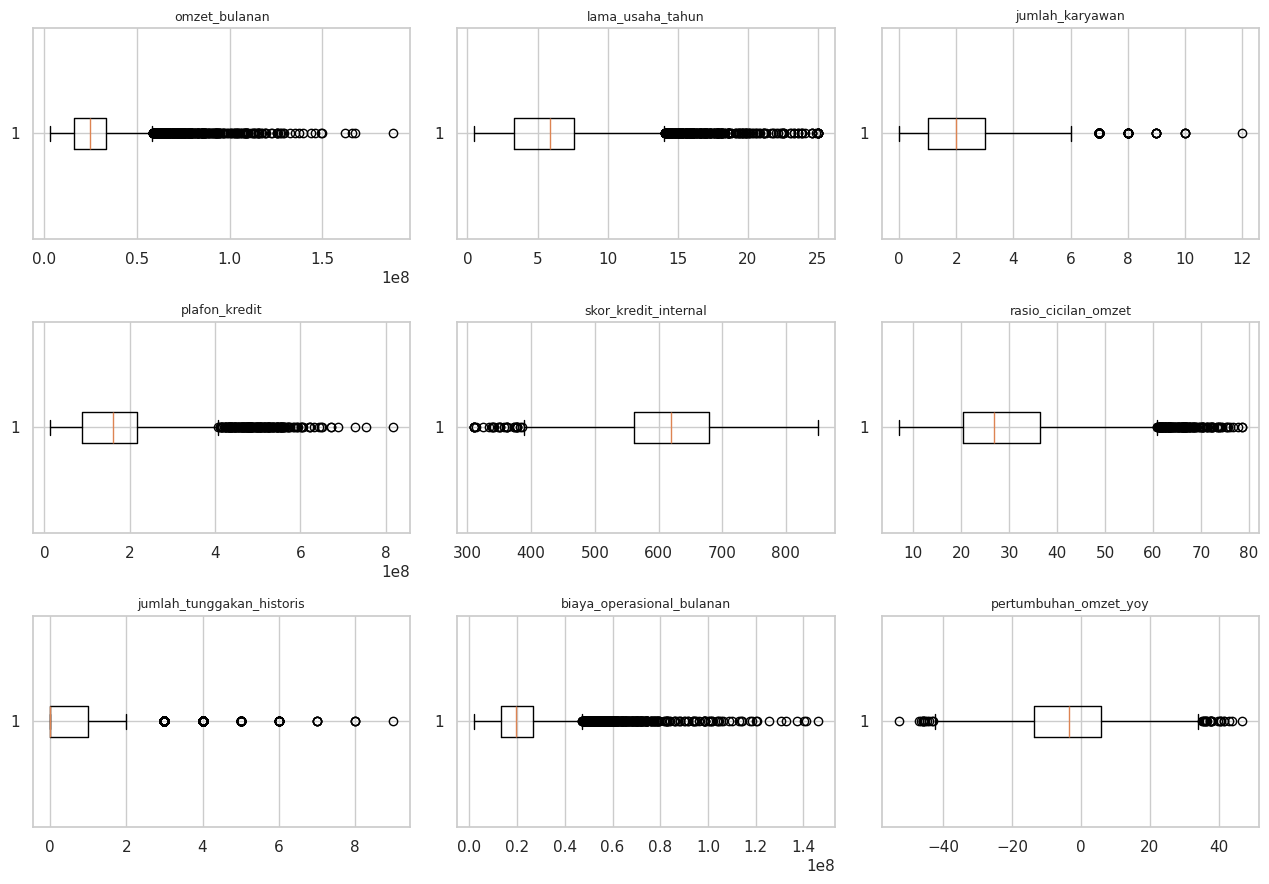

,fitur,min,max,skew,iqr_lower,iqr_upper,n_outlier,kandidat_transform
0,omzet_bulanan,3000000.0,188425121.0,2.279291,-9.422272e+06,5.845551e+07,414,True
1,lama_usaha_tahun,0.5,25.0,1.318335,-3.150000e+00,1.405000e+01,318,True
2,jumlah_karyawan,0.0,12.0,0.918040,-2.000000e+00,6.000000e+00,111,False
3,plafon_kredit,12917035.0,817285983.0,1.171287,-1.026086e+08,4.075614e+08,197,True
4,skor_kredit_internal,311.0,850.0,-0.059301,3.865000e+02,8.545000e+02,30,False
5,rasio_cicilan_omzet,7.0,78.6,0.903008,-4.000000e+00,6.080000e+01,159,False
6,jumlah_tunggakan_historis,0.0,9.0,1.833488,-1.500000e+00,2.500000e+00,648,True
7,biaya_operasional_bulanan,2104528.0,145966753.0,2.318265,-7.368170e+06,4.722849e+07,433,True
8,pertumbuhan_omzet_yoy,-52.9,46.8,-0.026224,-4.280000e+01,3.480000e+01,35,False


In [115]:
train_filled=DerivedFeatures(tuple(MODEL_NUM)).transform(imputer_audit.transform(X_train))
outlier_rows=[]
fig,axes=plt.subplots(3,3,figsize=(13,9))
for ax,c in zip(axes.flat,NUM):
    s=train_filled[c]; q1,q3=s.quantile([.25,.75]); lo=q1-1.5*(q3-q1); hi=q3+1.5*(q3-q1)
    outlier_rows.append({'fitur':c,'min':s.min(),'max':s.max(),'skew':s.skew(),'iqr_lower':lo,'iqr_upper':hi,'n_outlier':int(((s<lo)|(s>hi)).sum()),'kandidat_transform':bool(s.min()>=0 and s.skew()>1)})
    ax.boxplot(s,vert=False); ax.set_title(c,fontsize=9)
plt.tight_layout();plt.show()
outlier_profile=pd.DataFrame(outlier_rows); display(outlier_profile)
AUDIT['outlier_profile']=outlier_profile


### 6.2 Membandingkan perubahan distribusi dan capping

| Pilihan | Apa yang berubah? |
|---|---|
| `none` | Angka hasil imputasi dipertahankan |
| `log` | `log(1+x)` mengecilkan jarak angka tinggi lebih kuat |
| `sqrt` | Akar kuadrat mengecilkan jarak angka tinggi lebih ringan |
| `cap` | Nilai di bawah/atas persentil 1–99% dibatasi ke batas tersebut |

Log dan akar kuadrat mengubah bentuk distribusi, tidak menjamin normal. Capping mengubah nilai ekstrem, sehingga informasi pada bagian ekor bisa hilang. Setiap fold belajar kolom kandidat dan batas capping dari kelompok latihannya sendiri.

**Urutan pada semua kandidat: imputasi → pembuatan fitur → pilihan treatment → StandardScaler → LR.** StandardScaler menyamakan skala, bukan membuat distribusi normal. Maka `none` berarti tanpa perubahan distribusi tambahan, tetapi tetap memakai scaler. Pilihan berdasarkan F1 CV, bukan grafik yang paling simetris.

In [116]:
treatment_comparison,chosen_treatment=compare_candidates('treatment_comparison',
{m:make_pipeline(chosen_imputation,chosen_categories,m) for m in ['none','log','sqrt','cap']})


,candidate,complexity_order,accuracy_cv,precision_cv,recall_cv,f1_cv,f05_cv,roc_auc_cv,ap_cv,f1_std
0,none,0,0.955249,0.863133,0.797196,0.828137,0.848584,0.983811,0.917734,0.019136
1,cap,3,0.954742,0.861663,0.794393,0.826040,0.846879,0.983497,0.916751,0.021055
2,log,1,0.952460,0.849900,0.789720,0.818001,0.836661,0.982591,0.913145,0.020902
3,sqrt,2,0.950812,0.846845,0.778505,0.810638,0.831822,0.981687,0.909237,0.028514


Terpilih: none ; F1 CV: 0.8281


### 6.3 Melihat perubahan sebelum StandardScaler

Grafik berikut menunjukkan distribusi setelah setiap pilihan treatment, sebelum scaling. Dengan cara ini kita bisa melihat apa yang dilakukan log, akar, atau capping secara langsung.

Ini audit menggunakan parameter seluruh train; angka yang dipakai saat CV tetap dipelajari ulang di tiap fold. Tabel menunjukkan perubahan skewness dan jumlah nilai yang berubah.

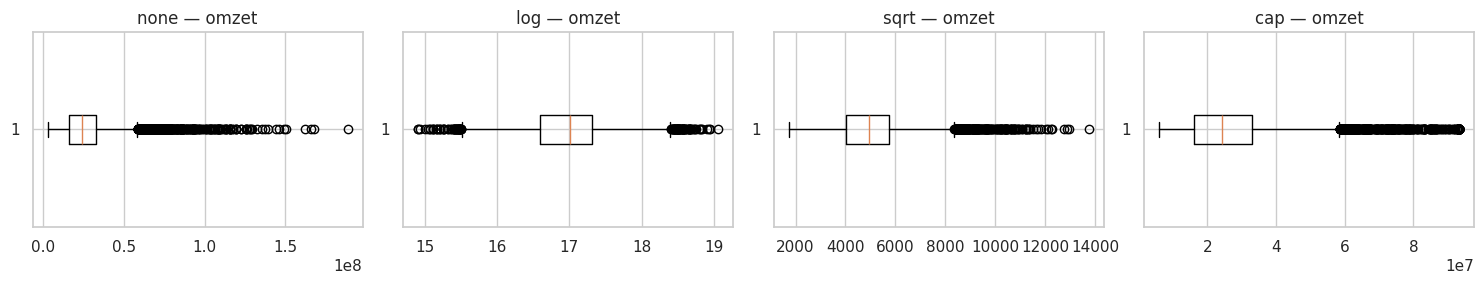

,metode,fitur,skew_before,skew_after,min_after,max_after,n_changed
0,none,omzet_bulanan,2.279291,2.279291,3.000000e+06,1.884251e+08,0
1,none,lama_usaha_tahun,1.318335,1.318335,5.000000e-01,2.500000e+01,0
2,none,jumlah_tunggakan_historis,1.833488,1.833488,0.000000e+00,9.000000e+00,0
3,none,biaya_operasional_bulanan,2.318265,2.318265,2.104528e+06,1.459668e+08,0
4,log,omzet_bulanan,2.279291,-0.014116,1.491412e+01,1.905421e+01,7888
5,log,lama_usaha_tahun,1.318335,-0.290120,4.054651e-01,3.258097e+00,7888
6,log,jumlah_tunggakan_historis,1.833488,0.853624,0.000000e+00,2.302585e+00,3387
7,log,biaya_operasional_bulanan,2.318265,-0.055835,1.455960e+01,1.879889e+01,7888
8,sqrt,omzet_bulanan,2.279291,0.997160,1.732051e+03,1.372680e+04,7888
9,sqrt,lama_usaha_tahun,1.318335,0.309543,7.071068e-01,5.000000e+00,7838


In [117]:
transform_rows=[]
fig,axes=plt.subplots(1,4,figsize=(15,3))
for ax,method in zip(axes,['none','log','sqrt','cap']):
    t=DistributionTreatment(method,tuple(MODEL_NUM)).fit(train_filled); z=t.transform(train_filled)
    ax.boxplot(z['omzet_bulanan'],vert=False);ax.set_title(method+' — omzet')
    for c in t.columns_: transform_rows.append({'metode':method,'fitur':c,'skew_before':train_filled[c].skew(),'skew_after':z[c].skew(),'min_after':z[c].min(),'max_after':z[c].max(),'n_changed':int((train_filled[c]!=z[c]).sum())})
plt.tight_layout();plt.show()
display(pd.DataFrame(transform_rows));AUDIT['transform_before_after']=pd.DataFrame(transform_rows)


### 6.4 Melihat perubahan angka menjadi z-score

StandardScaler menghitung **z = (nilai−mean train)/standar deviasi train**. Misalnya z=2 berarti nilai berada dua standar deviasi di atas mean train. Ini mengubah satuan, bukan menghapus outlier atau menjamin bentuk normal.

Mean train sesudah scaling mendekati 0 dan standar deviasinya mendekati 1 (perhitungan `ddof=0`). Test tidak harus tepat 0/1 karena memakai mean dan standar deviasi train.

Tabel ini hanya dokumentasi. Hasil tabel tidak dimasukkan lagi ke pipeline sehingga tidak terjadi scaling dua kali.

In [118]:
audit_treatment=DistributionTreatment(chosen_treatment,tuple(MODEL_NUM)).fit(train_filled)
train_treated=audit_treatment.transform(train_filled)
test_treated=audit_treatment.transform(DerivedFeatures(tuple(MODEL_NUM)).transform(imputer_audit.transform(X_test)))
audit_scaler=StandardScaler().fit(train_treated[MODEL_NUM])
ztrain=audit_scaler.transform(train_treated[MODEL_NUM]);ztest=audit_scaler.transform(test_treated[MODEL_NUM])
scaler_audit=pd.DataFrame({'fitur':MODEL_NUM,'mean_learned':audit_scaler.mean_,'std_learned':audit_scaler.scale_,
'mean_train_after':ztrain.mean(0),'std_train_after':ztrain.std(0),'mean_test_after':ztest.mean(0),'std_test_after':ztest.std(0)})
display(scaler_audit)
display(pd.DataFrame({'id_debitur':df.loc[X_train.index[:5],'id_debitur'].values,'fitur_exemple':MODEL_NUM[0],'nilai_before':train_treated[MODEL_NUM[0]].iloc[:5].values,'zscore':ztrain[:5,0]}))
AUDIT['scaler_audit']=scaler_audit


,fitur,mean_learned,std_learned,mean_train_after,std_train_after,mean_test_after,std_test_after
0,omzet_bulanan,2.744085e+07,1.724434e+07,-1.044916e-16,1.0,0.008874,1.029585
1,lama_usaha_tahun,6.049807e+00,3.738182e+00,-1.990745e-16,1.0,-0.024877,1.001206
2,jumlah_karyawan,2.092546e+00,1.579793e+00,1.725012e-16,1.0,0.016852,0.978784
3,skor_kredit_internal,6.195824e+02,8.674748e+01,-5.895667e-16,1.0,0.006784,1.004350
4,rasio_cicilan_omzet,2.957219e+01,1.243138e+01,6.125368e-17,1.0,-0.028809,0.955849
5,jumlah_tunggakan_historis,7.486055e-01,1.102648e+00,-6.936079e-17,1.0,-0.006553,0.975613
6,biaya_operasional_bulanan,2.246235e+07,1.426448e+07,1.661957e-16,1.0,0.012282,1.050462
7,pertumbuhan_omzet_yoy,-3.813704e+00,1.404210e+01,3.490559e-17,1.0,0.002020,1.032523


,id_debitur,fitur_exemple,nilai_before,zscore
0,UMKM-00953,omzet_bulanan,22025632.0,-0.314029
1,UMKM-03595,omzet_bulanan,11519338.0,-0.923289
2,UMKM-06219,omzet_bulanan,32549842.0,0.296271
3,UMKM-06276,omzet_bulanan,15512247.0,-0.691740
4,UMKM-02077,omzet_bulanan,107631783.0,4.650277


### 7.1 Melihat ketidakseimbangan label

Kelas lancar jauh lebih banyak daripada gagal bayar. Model yang selalu menjawab lancar bisa memiliki accuracy tinggi tetapi recall gagal bayar nol. DummyClassifier menjadi contoh pembanding tersebut.

Kita tidak langsung menyamakan jumlah kelas. Kita uji dahulu apakah penanganan imbalance benar-benar membantu precision, recall, dan F1.

In [119]:
from sklearn.dummy import DummyClassifier
counts=y_train.value_counts().sort_index()
display(pd.DataFrame({'jumlah':counts,'proporsi':counts/len(y_train)}))
print('Rasio kelas 0:1 =',round(counts[0]/counts[1],2))
dummy=np.zeros(len(y_train),dtype=int)
print('Dummy accuracy:',accuracy_score(y_train,dummy),'F1:',f1_score(y_train,dummy,zero_division=0))


,jumlah,proporsi
flag_gagal_bayar,,
0,6818,0.864351
1,1070,0.135649


Rasio kelas 0:1 = 6.37
Dummy accuracy: 0.8643509127789046 F1: 0.0


### 7.2 Membandingkan cara menangani imbalance

Tanpa balancing mempertahankan data asli. Class weight memberi bobot kesalahan lebih besar pada kelas minoritas. RandomOverSampler menggandakan baris minoritas. SMOTE membuat contoh baru di antara tetangga minoritas.

Penggandaan/pembuatan contoh hanya dilakukan pada kelompok latihan, setelah scaling. Kelompok validasi dan test tetap asli. Jika kategori terpilih, SMOTE biasa tidak dipakai seolah-olah cocok untuk dummy kategori; percobaan SMOTE numerik ditampilkan terpisah dan tidak dianggap perbandingan fitur yang sama.

Metrik klasifikasi masih memakai threshold 0,50. Threshold operasional baru ditentukan sesudah konfigurasi model selesai.

In [120]:
balance_candidates={m:make_pipeline(chosen_imputation,chosen_categories,chosen_treatment,m) for m in ['none','weight','ros']}
if not chosen_categories: balance_candidates['smote']=make_pipeline(chosen_imputation,(),chosen_treatment,'smote')
imbalance_comparison,chosen_balance=compare_candidates('imbalance_comparison',balance_candidates)
if chosen_categories:
    print('SMOTE: sensitivitas numerik saja, tidak dibandingkan seolah feature set sama.')
    smote_sensitivity,_=compare_candidates('smote_numeric_sensitivity',{'numeric_none':make_pipeline(chosen_imputation,(),chosen_treatment), 'numeric_smote':make_pipeline(chosen_imputation,(),chosen_treatment,'smote')})


,candidate,complexity_order,accuracy_cv,precision_cv,recall_cv,f1_cv,f05_cv,roc_auc_cv,ap_cv,f1_std
0,none,0,0.955249,0.863133,0.797196,0.828137,0.848584,0.983811,0.917734,0.019136
1,smote,3,0.926470,0.665472,0.928037,0.774281,0.704978,0.983700,0.917073,0.017445
2,ros,2,0.922920,0.650739,0.939252,0.768124,0.693005,0.983671,0.916962,0.015115
3,weight,1,0.922160,0.647972,0.941121,0.766797,0.690687,0.983726,0.917439,0.015761


Terpilih: none ; F1 CV: 0.8281


### 7.3 Melihat perubahan jumlah kelas

Tabel berikut memakai satu training fold untuk memperlihatkan apa yang terjadi pada jumlah baris. Class weight tidak menambah baris; ROS dan SMOTE menambah contoh kelas minoritas.

Jumlah validasi tetap. Ini demonstrasi mekanismenya, bukan perintah melakukan oversampling pada seluruh dataset yang akan diekspor.

In [121]:
tr,va=FOLDS[0]; base=make_pipeline(chosen_imputation,(),chosen_treatment)
base.fit(X_train.iloc[tr],y_train.iloc[tr])
zz=base.named_steps['pre'].transform(base.named_steps['treatment'].transform(base.named_steps['features'].transform(base.named_steps['imputer'].transform(X_train.iloc[tr]))))
rows=[]
for name,sampler in [('none',None),('weight',None),('ros',RandomOverSampler(random_state=SEED)),('smote',SMOTE(random_state=SEED))]:
    yy=y_train.iloc[tr] if sampler is None else sampler.fit_resample(zz,y_train.iloc[tr])[1]
    rows.append({'metode':name,'kelas0':int((yy==0).sum()),'kelas1':int((yy==1).sum()),'total':len(yy),'validation_n_tetap':len(va)})
display(pd.DataFrame(rows)); AUDIT['balance_before_after']=pd.DataFrame(rows)


,metode,kelas0,kelas1,total,validation_n_tetap
0,none,5454,856,6310,1578
1,weight,5454,856,6310,1578
2,ros,5454,5454,10908,1578
3,smote,5454,5454,10908,1578


### 8.1 Membandingkan tiga algoritma

Kita membandingkan Logistic Regression, Random Forest, dan XGBoost menggunakan fitur dan fold yang sama. LR memakai scaler; model pohon tidak membutuhkannya. Pada tabel algoritma, balancing dibuat sama-sama `none` agar fokus perbandingannya jelas.

Ketiganya memakai pengaturan awal yang dinyatakan dalam fungsi pipeline, tanpa pencarian hyperparameter. Karena tugas meminta LR, model final tetap LR dengan strategi balancing terpilih. Jika model pembanding lebih baik, hasilnya tetap ditampilkan secara jujur; kita tidak mengklaim LR selalu algoritma terbaik.

In [122]:
algorithm_candidates={a:make_pipeline(chosen_imputation,chosen_categories,chosen_treatment,'none',a) for a in ['LR','RF','XGB']}
algorithm_comparison,benchmark_winner=compare_candidates('algorithm_comparison',algorithm_candidates)
print('Pemenang benchmark:',benchmark_winner)
print('Mandat proyek: model final Logistic Regression; jika benchmark lain unggul, laporkan selisih secara terbuka.')
best_pipeline=make_pipeline(chosen_imputation,chosen_categories,chosen_treatment,chosen_balance,'LR')


,candidate,complexity_order,accuracy_cv,precision_cv,recall_cv,f1_cv,f05_cv,roc_auc_cv,ap_cv,f1_std
0,LR,0,0.955249,0.863133,0.797196,0.828137,0.848584,0.983811,0.917734,0.019136
1,XGB,2,0.954107,0.853351,0.800935,0.825152,0.841524,0.983146,0.914364,0.019242
2,RF,1,0.952079,0.865994,0.766355,0.812135,0.843321,0.980526,0.906808,0.020307


Terpilih: LR ; F1 CV: 0.8281
Pemenang benchmark: LR
Mandat proyek: model final Logistic Regression; jika benchmark lain unggul, laporkan selisih secara terbuka.


### 8.2 Melihat hasil tiap putaran, bukan hanya rata-rata

Rata-rata merangkum lima hasil, tetapi dapat menyembunyikan perbedaan antarputaran. Tabel ini menyimpan metrik setiap metode pada setiap fold.

Standar deviasi (`std`) memperlihatkan variasi hasil. Ia bukan otomatis batas kepastian hasil model. Proses kita memilih metode bertahap, bukan menguji semua kombinasi yang mungkin.

In [123]:
fold_metrics=pd.DataFrame(experiment_folds)
display(fold_metrics)
AUDIT['all_experiment_fold_metrics']=fold_metrics
print('Total baris audit fold:',len(fold_metrics))


,stage,candidate,fold,accuracy,precision,recall,f1,f05,roc_auc,ap
0,imputation_comparison,median_global,1,0.949303,0.880682,0.724299,0.794872,0.844227,0.979911,0.897066
1,imputation_comparison,median_global,2,0.958175,0.849057,0.841121,0.845070,0.847458,0.987766,0.937613
2,imputation_comparison,median_global,3,0.956274,0.857143,0.813084,0.834532,0.847953,0.984827,0.921093
3,imputation_comparison,median_global,4,0.950539,0.833333,0.794393,0.813397,0.825243,0.981823,0.906662
4,imputation_comparison,median_global,5,0.958148,0.877551,0.803738,0.839024,0.861723,0.984771,0.925688
...,...,...,...,...,...,...,...,...,...,...
105,algorithm_comparison,XGB,1,0.949937,0.885714,0.724299,0.796915,0.847921,0.980390,0.898878
106,algorithm_comparison,XGB,2,0.955006,0.823529,0.850467,0.836782,0.828780,0.986735,0.933053
107,algorithm_comparison,XGB,3,0.958175,0.866337,0.817757,0.841346,0.856164,0.984474,0.920910
108,algorithm_comparison,XGB,4,0.950539,0.833333,0.794393,0.813397,0.825243,0.980225,0.900463


Total baris audit fold: 110


## 9. OOF: satu probabilitas untuk setiap baris train tanpa melatih baris itu

**Out-of-fold (OOF)** adalah prediksi untuk baris yang sedang mendapat giliran menjadi validasi. Pada putaran pertama, model belajar dari fold 2–5 lalu memberi PD untuk fold 1. Putaran kedua memberi PD untuk fold 2, dan seterusnya.

Setelah lima putaran, potongan hasil disusun kembali mengikuti ID sehingga tersedia 7.888 PD untuk 7.888 baris train. Setiap PD dibuat oleh model yang tidak melatih baris tersebut. OOF tidak berarti seluruh train dilatih dahulu lalu diprediksi kembali.

PD adalah angka peluang antara 0–1 dari `predict_proba`; belum menjadi flag. Kita akan memakai OOF untuk memeriksa kualitas probabilitas dan mencari threshold. Model akhir untuk penggunaan berikutnya baru dilatih pada seluruh train setelah keputusan selesai.

Rata-rata F1 lima fold berbeda cara hitungnya dari F1 atas gabungan prediksi OOF. Keduanya dapat menghasilkan angka yang sedikit berbeda.

### 9.1 Membuat PD OOF dan menyimpan asalnya

`cross_val_predict` menjalankan lima putaran pipeline lalu mengembalikan satu prediksi untuk setiap baris train. Data masuk masih sebelum imputasi, sehingga tidak memakai angka pengganti dari seluruh train.

Tabel menyimpan ID, label aktual, PD OOF, dan fold validasi. Jika ingin menelusuri satu prediksi, lihat nomor fold lalu lihat kelompok mana yang menjadi latihan pada putaran tersebut.

In [124]:
pd_oof_train=cross_val_predict(best_pipeline,X_train,y_train,cv=FOLDS,method='predict_proba',n_jobs=1)[:,1]
oof_table=pd.DataFrame({'index_asli':X_train.index,'id_debitur':df.loc[X_train.index,'id_debitur'].values,'flag_aktual':y_train.to_numpy(),'pd_oof':pd_oof_train})
oof_table=oof_table.merge(fold_membership[['index_asli','fold_validasi']],on='index_asli',validate='one_to_one')
assert len(oof_table)==len(X_train) and oof_table.id_debitur.is_unique
assert np.isfinite(pd_oof_train).all()
display(oof_table.head(15));AUDIT['oof_per_debitur']=oof_table


,index_asli,id_debitur,flag_aktual,pd_oof,fold_validasi
0,81,UMKM-00953,0,0.002533,1
1,8914,UMKM-03595,0,0.000001,3
2,6748,UMKM-06219,0,0.001239,2
3,4900,UMKM-06276,0,0.230328,5
4,4367,UMKM-02077,0,0.000002,2
5,9445,UMKM-01325,0,0.004411,3
6,3955,UMKM-04886,0,0.000367,4
7,2600,UMKM-01234,0,0.259158,3
8,2223,UMKM-04412,1,0.987842,3
9,4822,UMKM-05975,0,0.011914,3


### 9.2 Menyiapkan pemeriksaan kualitas probabilitas

PD 20% tidak berarti satu orang mengalami gagal bayar sebesar 20%. Maknanya: pada banyak debitur yang diberi peluang sekitar 20%, kira-kira 20% diharapkan gagal bayar jika probabilitasnya tepat.

Kita urutkan PD lalu bagi menjadi sepuluh kelompok berukuran hampir sama (decile). Pada setiap kelompok, bandingkan rata-rata PD dengan proporsi gagal bayar aktual. Selisih kecil memberi dukungan bahwa PD cukup sesuai pada kelompok itu.

Brier Score menghitung rata-rata kuadrat selisih PD dan label 0/1. Log Loss memberi penalti besar bila model sangat yakin tetapi salah. ECE merangkum rata-rata selisih absolut per kelompok, dibobot jumlah debiturnya. Makin kecil ketiganya umumnya makin baik; ECE juga dipengaruhi cara membuat kelompok.

,actual_rate,mean_pd,AP,ROC_AUC,Gini,Brier,LogLoss,ECE_decile
0,0.135649,0.136491,0.916896,0.983535,0.967069,0.033352,0.10934,0.002589


,decile,n,defaults,pd_mean,actual_rate,gap
0,1,789,0,0.000001,0.000000,0.000001
1,2,789,0,0.000012,0.000000,0.000012
2,3,789,0,0.000061,0.000000,0.000061
3,4,788,0,0.000245,0.000000,0.000245
4,5,789,0,0.000893,0.000000,0.000893
5,6,789,1,0.003172,0.001267,0.001905
6,7,788,7,0.012894,0.008883,0.004011
7,8,789,53,0.066552,0.067174,-0.000622
8,9,789,281,0.366173,0.356147,0.010026
9,10,789,728,0.914575,0.922687,-0.008112


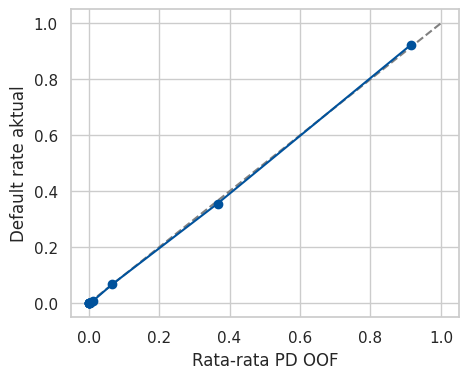

In [125]:
def calibration(y,p):
    d=pd.DataFrame({'y':np.asarray(y),'pd':np.asarray(p)})
    d['decile']=pd.qcut(d.pd.rank(method='first'),10,labels=False)+1
    t=d.groupby('decile').agg(n=('y','size'),defaults=('y','sum'),pd_mean=('pd','mean'),actual_rate=('y','mean')).reset_index()
    t['gap']=t.pd_mean-t.actual_rate
    ece=np.average(t.gap.abs(),weights=t.n)
    return t,ece

def probability_metrics(y,p):
    t,ece=calibration(y,p)
    return pd.DataFrame([{'actual_rate':np.mean(y),'mean_pd':np.mean(p),'AP':average_precision_score(y,p),'ROC_AUC':roc_auc_score(y,p),
    'Gini':2*roc_auc_score(y,p)-1,'Brier':brier_score_loss(y,p),'LogLoss':log_loss(y,p),'ECE_decile':ece}]),t

oof_probability_summary,oof_calibration=probability_metrics(y_train,pd_oof_train)
display(oof_probability_summary);display(oof_calibration)
AUDIT['oof_probability_summary']=oof_probability_summary;AUDIT['oof_calibration']=oof_calibration
plt.figure(figsize=(5,4));plt.plot([0,1],[0,1],'--',color='gray');plt.plot(oof_calibration.pd_mean,oof_calibration.actual_rate,'o-',color='#00529C');plt.xlabel('Rata-rata PD OOF');plt.ylabel('Default rate aktual');plt.show()


### 9.3 Membandingkan probabilitas model dengan tebakan sederhana

Pembanding sederhana memberi setiap debitur PD yang sama dengan proporsi gagal bayar pada kelompok latihan. Untuk OOF, proporsi ini dihitung dari empat fold latihan masing-masing, bukan seluruh train.

Brier Skill Score menunjukkan perbaikan Brier terhadap pembanding tersebut. Nilai positif berarti lebih baik. Rata-rata PD yang mendekati default rate mendukung kecocokan secara keseluruhan, tetapi belum menjamin semua kelompok tepat.

Audit ini tidak otomatis mengubah PD atau melatih model kalibrasi tambahan. Jika hasil kurang baik, catat masalahnya; jangan memperbaiki model berdasarkan test.

In [126]:
null_oof=np.empty(len(y_train))
for tr,va in FOLDS: null_oof[va]=y_train.iloc[tr].mean()
brier_null=brier_score_loss(y_train,null_oof)
print('Brier benchmark:',brier_null,'Brier skill:',1-brier_score_loss(y_train,pd_oof_train)/brier_null)
print('Periksa grafik/decile; mean yang dekat tidak menjamin kalibrasi pada setiap kelompok.')


Brier benchmark: 0.11724841335522905 Brier skill: 0.7155474362442003
Periksa grafik/decile; mean yang dekat tidak menjamin kalibrasi pada setiap kelompok.


## 10. Mencari threshold untuk mengubah PD menjadi flag

Threshold adalah batas keputusan, bukan error. Jika PD ≥ threshold, flag=1; jika lebih kecil, flag=0. Sebagai contoh, PD 0,30 menjadi flag 0 pada batas 0,50 tetapi flag 1 pada batas 0,25. PD-nya tetap 0,30.

Kita mencoba banyak batas pada daftar di cell berikut. **Tidak ada pelatihan model ulang untuk setiap batas:** PD OOF sudah tersedia; yang berubah hanya perbandingan PD dengan batas tersebut. Setiap batas menghasilkan FP, FN, precision, recall, dan F1 yang bisa berbeda.

Tabel ringkasan beberapa threshold berasal dari pencarian ini, bukan angka yang muncul tiba-tiba. ECL tetap menggunakan PD kontinu, tidak menggunakan flag.

### 10.1 Menghitung seluruh kandidat threshold

Untuk setiap nilai batas, script membentuk flag lalu membandingkannya dengan label asli. Semua kandidat beserta metriknya disimpan sebagai jejak pencarian.

Angka biaya adalah bobot FP dan FN untuk ilustrasi, bukan rupiah kerugian yang sudah diukur. Jangan menganggap rasio biaya contoh sebagai ketentuan bank.

In [127]:
def threshold_metrics(y,p,t,fp_cost=2,fn_cost=1):
    pred=(np.asarray(p)>=t).astype(int);tn,fp,fn,tp=confusion_matrix(y,pred,labels=[0,1]).ravel()
    return {'threshold':float(t),'accuracy':accuracy_score(y,pred),'precision':precision_score(y,pred,zero_division=0),
    'recall':recall_score(y,pred,zero_division=0),'f1':f1_score(y,pred,zero_division=0),'f05':fbeta_score(y,pred,beta=.5,zero_division=0),
    'balanced_accuracy':balanced_accuracy_score(y,pred),'specificity':tn/(tn+fp),'tn':tn,'fp':fp,'fn':fn,'tp':tp,
    'review_rate':pred.mean(),'cost':fp_cost*fp+fn_cost*fn}
threshold_grid=np.round(np.arange(.01,.991,.005),3)
threshold_results=pd.DataFrame([threshold_metrics(y_train,pd_oof_train,t) for t in threshold_grid])
display(threshold_results.head(10));print('Kandidat:',len(threshold_results))
AUDIT['all_threshold_candidates']=threshold_results


,threshold,accuracy,precision,recall,f1,f05,balanced_accuracy,specificity,tn,fp,fn,tp,review_rate,cost
0,0.010,0.774721,0.375660,0.998131,0.545873,0.429191,0.868895,0.739660,5043,1775,2,1068,0.360421,3552
1,0.015,0.803626,0.408413,0.998131,0.579647,0.463140,0.885616,0.773101,5271,1547,2,1068,0.331516,3096
2,0.020,0.818458,0.427426,0.996262,0.598204,0.482528,0.893408,0.790554,5390,1428,4,1066,0.316176,2860
3,0.025,0.833291,0.448290,0.992523,0.617621,0.503508,0.900412,0.808302,5511,1307,8,1062,0.300330,2622
4,0.030,0.843687,0.464301,0.990654,0.632270,0.519506,0.905638,0.820622,5595,1223,10,1060,0.289427,2456
5,0.035,0.852307,0.478517,0.988785,0.644925,0.533589,0.909837,0.830889,5665,1153,12,1058,0.280299,2318
6,0.040,0.859660,0.491391,0.986916,0.656104,0.546245,0.913302,0.839689,5725,1093,14,1056,0.272439,2200
7,0.045,0.866126,0.503340,0.985981,0.666456,0.557965,0.916649,0.847316,5777,1041,15,1055,0.265720,2097
8,0.050,0.873479,0.517682,0.985047,0.678686,0.571956,0.920508,0.855969,5836,982,16,1054,0.258114,1980
9,0.055,0.878550,0.528226,0.979439,0.686313,0.581834,0.921078,0.862716,5882,936,22,1048,0.251521,1894


Kandidat: 197


### 10.2 Memilih dan mengunci threshold

Script mengurutkan tabel kandidat untuk mengambil F1 terbesar, F0,5 terbesar, balanced accuracy terbesar, atau biaya terkecil. Itulah asal threshold pada tabel ringkasan. Threshold default 0,50 ditambahkan sebagai pembanding.

Pilihan final mengikuti F1 OOF tertinggi, lalu precision jika seri. Artinya, kita menyeimbangkan precision–recall, sambil memakai precision sebagai pembeda saat F1 sama. Kebijakan ini **belum menyatakan FP selalu lebih mahal berapa kali**; jika mentor ingin penekanan precision lebih besar, F0,5 atau skenario biaya dapat didiskusikan sebelum evaluasi final.

In [128]:
def winner(column,maximize=True):
    return threshold_results.sort_values([column,'precision','threshold'],ascending=[not maximize,False,False]).iloc[0]
f1_row=winner('f1'); ba_row=winner('balanced_accuracy'); cost_row=winner('cost',False); f05_row=winner('f05')
threshold_final=float(f1_row.threshold)
threshold_comparison=pd.DataFrame([dict(method=name,**row.to_dict()) for name,row in [
('Default 0.50',threshold_results.loc[np.isclose(threshold_results.threshold,.5)].iloc[0]),('F1 optimum',f1_row),
('Balanced accuracy optimum',ba_row),('Cost minimum 2FP+FN',cost_row),('F0.5 sensitivity',f05_row)]])
display(threshold_comparison)
print('Threshold final F1:',threshold_final)
AUDIT['threshold_winners']=threshold_comparison
threshold_near=threshold_results.loc[(threshold_results.threshold-threshold_final).abs()<=.025001]
display(threshold_near)


,method,threshold,accuracy,precision,recall,f1,f05,balanced_accuracy,specificity,tn,fp,fn,tp,review_rate,cost
0,Default 0.50,0.500,0.955248,0.862487,0.797196,0.828558,0.848587,0.888625,0.980053,6682.0,136.0,217.0,853.0,0.125380,489.0
1,F1 optimum,0.415,0.953981,0.826408,0.836449,0.831398,0.828397,0.904437,0.972426,6630.0,188.0,175.0,895.0,0.137297,551.0
2,Balanced accuracy optimum,0.120,0.914554,0.620146,0.955140,0.752024,0.666928,0.931662,0.908184,6192.0,626.0,48.0,1022.0,0.208925,1300.0
3,Cost minimum 2FP+FN,0.600,0.953600,0.898190,0.742056,0.812692,0.861919,0.864428,0.986800,6728.0,90.0,276.0,794.0,0.112069,456.0
4,F0.5 sensitivity,0.685,0.950177,0.918418,0.694393,0.790846,0.862750,0.842356,0.990320,6752.0,66.0,327.0,743.0,0.102561,459.0


Threshold final F1: 0.415


,threshold,accuracy,precision,recall,f1,f05,balanced_accuracy,specificity,tn,fp,fn,tp,review_rate,cost
76,0.390,0.952079,0.810592,0.843925,0.826923,0.817047,0.906489,0.969053,6607,211,167,903,0.141227,589
77,0.395,0.952840,0.816697,0.841121,0.828729,0.821468,0.905747,0.970373,6616,202,170,900,0.139706,574
78,0.400,0.953093,0.818761,0.840187,0.829336,0.822959,0.905500,0.970813,6619,199,171,899,0.139199,569
79,0.405,0.953727,0.824287,0.837383,0.830783,0.826873,0.904685,0.971986,6627,191,174,896,0.137804,556
80,0.410,0.953981,0.826408,0.836449,0.831398,0.828397,0.904437,0.972426,6630,188,175,895,0.137297,551
81,0.415,0.953981,0.826408,0.836449,0.831398,0.828397,0.904437,0.972426,6630,188,175,895,0.137297,551
82,0.420,0.953981,0.827012,0.835514,0.831241,0.828699,0.904043,0.972573,6631,187,176,894,0.137044,550
83,0.425,0.953854,0.829291,0.830841,0.830065,0.829601,0.902000,0.973159,6635,183,181,889,0.135903,547
84,0.430,0.953727,0.830366,0.828037,0.829200,0.829899,0.900745,0.973453,6637,181,184,886,0.135269,546
85,0.435,0.953600,0.831450,0.825234,0.828330,0.830199,0.899490,0.973746,6639,179,187,883,0.134635,545


### 10.3 Melihat konsekuensi threshold dan asumsi biaya

Grafik menunjukkan perubahan precision, recall, dan F1 ketika batas digeser. Menurunkan batas biasanya membuat lebih banyak debitur ditandai, sehingga lebih banyak gagal bayar tertangkap tetapi FP bisa bertambah.

Tabel biaya mencoba beberapa rasio FN:FP. Kita melihat apakah pilihan berubah jika penekanan kesalahan berubah. Analisis ini membantu diskusi kebijakan; bukan alasan mengganti threshold sesudah melihat hasil test.

,FN_cost,FP_cost,threshold,accuracy,precision,recall,f1,f05,balanced_accuracy,specificity,tn,fp,fn,tp,review_rate,cost,scenario_cost
0,1,1,0.500,0.955248,0.862487,0.797196,0.828558,0.848587,0.888625,0.980053,6682.0,136.0,217.0,853.0,0.125380,489.0,353.0
1,1,2,0.600,0.953600,0.898190,0.742056,0.812692,0.861919,0.864428,0.986800,6728.0,90.0,276.0,794.0,0.112069,456.0,456.0
2,1,3,0.755,0.945360,0.939477,0.638318,0.760156,0.858472,0.815932,0.993546,6774.0,44.0,387.0,683.0,0.092165,475.0,519.0
3,1,5,0.835,0.936359,0.962541,0.552336,0.701900,0.838060,0.774482,0.996627,6795.0,23.0,479.0,591.0,0.077840,525.0,594.0
4,5,1,0.180,0.930908,0.679426,0.928972,0.784840,0.718001,0.930092,0.931211,6349.0,469.0,76.0,994.0,0.185472,1014.0,849.0


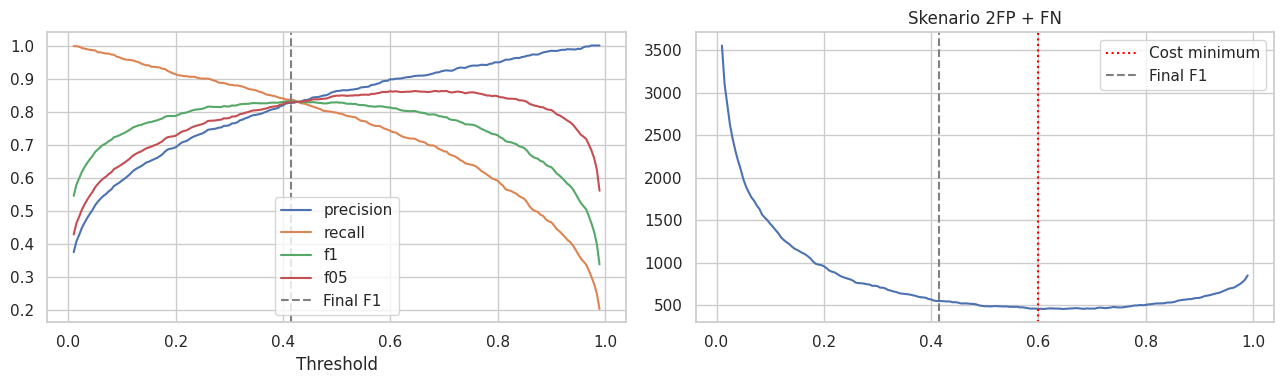

In [129]:
sensitivity=[]
for fn_cost,fp_cost in [(1,1),(1,2),(1,3),(1,5),(5,1)]:
    costs=threshold_results.fn*fn_cost+threshold_results.fp*fp_cost
    row=threshold_results.assign(scenario_cost=costs).sort_values(['scenario_cost','precision'],ascending=[True,False]).iloc[0]
    sensitivity.append({'FN_cost':fn_cost,'FP_cost':fp_cost,**row.to_dict()})
display(pd.DataFrame(sensitivity)); AUDIT['cost_sensitivity']=pd.DataFrame(sensitivity)
fig,axes=plt.subplots(1,2,figsize=(13,4))
for m in ['precision','recall','f1','f05']:axes[0].plot(threshold_results.threshold,threshold_results[m],label=m)
axes[0].axvline(threshold_final,color='gray',ls='--',label='Final F1');axes[0].legend();axes[0].set_xlabel('Threshold')
axes[1].plot(threshold_results.threshold,threshold_results.cost)
axes[1].axvline(cost_row.threshold,color='red',ls=':',label='Cost minimum')
axes[1].axvline(threshold_final,color='gray',ls='--',label='Final F1');axes[1].legend();axes[1].set_title('Skenario 2FP + FN')
plt.tight_layout();plt.show()


# 11 Melatih model final pada seluruh train

Konfigurasi dan threshold sudah ditentukan. Sekarang pipeline belajar dari seluruh train untuk menghasilkan satu model akhir. Data test tetap tidak menjadi sumber pengisian nilai kosong, scaler, atau pemilihan parameter.

Daftar fitur yang tercetak adalah fitur yang benar-benar diterima model, sehingga dapat dicocokkan dengan SHAP/LIME nanti.

In [130]:
best_pipeline.fit(X_train,y_train)
model_features=best_pipeline.named_steps['pre'].get_feature_names_out().tolist()
print('Fitur final:',model_features)
print('Konfigurasi:',chosen_imputation,chosen_features,chosen_treatment,chosen_balance,'LR',threshold_final)
assert not any('missing' in c.lower() or 'status_risiko' in c or 'jenis_kelamin' in c for c in model_features)

assert best_pipeline.named_steps['pre'].transformers_[0][2] == MODEL_NUM
assert all(c in model_features for c in MODEL_NUM)
print('PASS: model final memakai daftar fitur numerik hasil seleksi transparansi.')


Fitur final: ['omzet_bulanan', 'lama_usaha_tahun', 'jumlah_karyawan', 'skor_kredit_internal', 'rasio_cicilan_omzet', 'jumlah_tunggakan_historis', 'biaya_operasional_bulanan', 'pertumbuhan_omzet_yoy']
Konfigurasi: mean_sector Numerik none none LR 0.415
PASS: model final memakai daftar fitur numerik hasil seleksi transparansi.


### 11.1 Mengukur klasifikasi pada test

Model final memprediksi PD test, lalu PD diubah menjadi flag menggunakan threshold yang dipilih dari OOF. Kita tampilkan juga batas 0,50 sebagai pembanding, tetapi tidak memilih ulang berdasarkan hasil test.

Confusion matrix dibaca: baris adalah aktual, kolom adalah prediksi. FP berarti debitur lancar ditandai; FN berarti gagal bayar terlewat. Lihat jumlah kesalahannya bersama precision, recall, F1, dan accuracy.

,method,threshold,accuracy,precision,recall,f1,f05,balanced_accuracy,specificity,tn,fp,fn,tp,review_rate,cost
0,Default,0.500,0.955375,0.865854,0.794776,0.828794,0.850639,0.887705,0.980634,1671,33,55,213,0.124746,121
1,Final OOF,0.415,0.954868,0.820789,0.854478,0.837294,0.827312,0.912567,0.970657,1654,50,39,229,0.141481,139


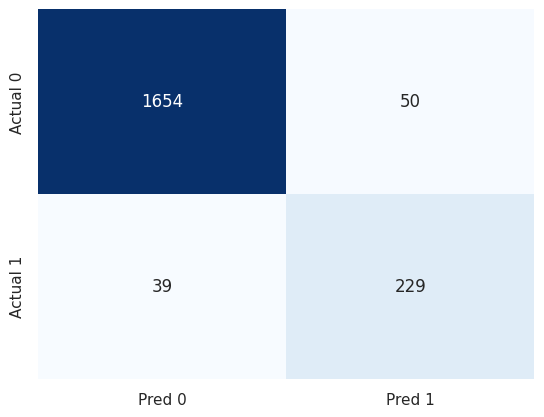

229 gagal bayar ditemukan; 39 terlewat. 50 debitur aktual lancar masuk review; 1654 lancar tidak ditandai.


In [131]:
pd_test=best_pipeline.predict_proba(X_test)[:,1]
flag_test_final=(pd_test>=threshold_final).astype(int)
test_threshold_comparison=pd.DataFrame([dict(method=name,**threshold_metrics(y_test,pd_test,t)) for name,t in [('Default',.5),('Final OOF',threshold_final)]])
display(test_threshold_comparison)
final_confusion=confusion_matrix(y_test,flag_test_final,labels=[0,1])
sns.heatmap(final_confusion,annot=True,fmt='d',cmap='Blues',cbar=False,xticklabels=['Pred 0','Pred 1'],yticklabels=['Actual 0','Actual 1']);plt.show()
AUDIT['test_threshold_comparison']=test_threshold_comparison
AUDIT['test_predictions']=pd.DataFrame({'id_debitur':df.loc[X_test.index,'id_debitur'].values,'actual':y_test.values,'pd':pd_test,'flag':flag_test_final})
tn,fp,fn,tp=final_confusion.ravel()
print(f'{tp} gagal bayar ditemukan; {fn} terlewat. {fp} debitur aktual lancar masuk review; {tn} lancar tidak ditandai.')


### 11.2 Mengukur PD kontinu pada test

Bagian sebelumnya menilai flag 0/1; bagian ini menilai kualitas PD dan urutan risikonya. Kita hitung AP, ROC-AUC, Brier, Log Loss, serta tabel kalibrasi.

PD yang mendekati rata-rata aktual belum tentu akurat di semua kelompok. Karena itu, lihat juga kelompok PD rendah dan tinggi. Angka 0,00% pada tampilan dapat merupakan pembulatan, bukan peluang persis nol.

,actual_rate,mean_pd,AP,ROC_AUC,Gini,Brier,LogLoss,ECE_decile
0,0.135903,0.138971,0.917622,0.983724,0.967447,0.033321,0.108839,0.005594


,decile,n,defaults,pd_mean,actual_rate,gap
0,1,198,0,9.214262e-07,0.000000,9.214262e-07
1,2,197,0,1.000527e-05,0.000000,1.000527e-05
2,3,197,0,5.308462e-05,0.000000,5.308462e-05
3,4,197,0,2.098824e-04,0.000000,2.098824e-04
4,5,197,0,7.462037e-04,0.000000,7.462037e-04
5,6,197,1,2.844866e-03,0.005076,-2.231276e-03
6,7,197,1,1.195971e-02,0.005076,6.883571e-03
7,8,197,10,7.006207e-02,0.050761,1.930065e-02
8,9,197,77,3.804546e-01,0.390863,-1.040836e-02
9,10,198,179,9.201106e-01,0.904040,1.607018e-02


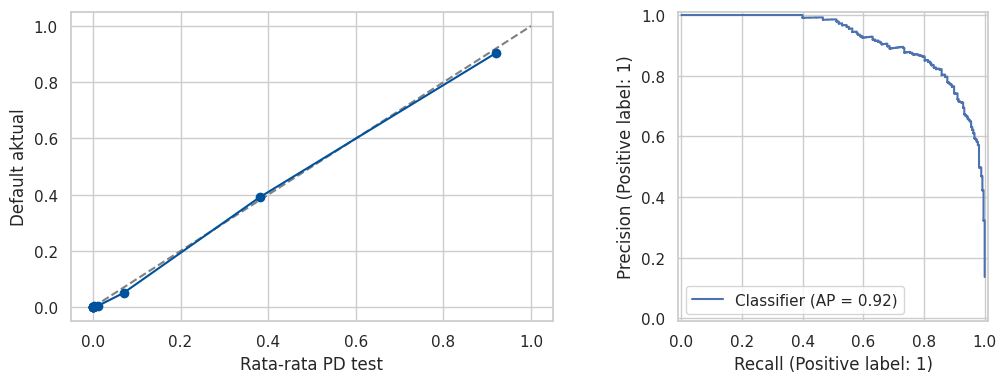

In [132]:
test_probability_summary,test_calibration_table=probability_metrics(y_test,pd_test)
display(test_probability_summary);display(test_calibration_table)
AUDIT['test_probability_summary']=test_probability_summary;AUDIT['test_calibration']=test_calibration_table
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot([0,1],[0,1],'--',color='gray');axes[0].plot(test_calibration_table.pd_mean,test_calibration_table.actual_rate,'o-',color='#00529C');axes[0].set_xlabel('Rata-rata PD test');axes[0].set_ylabel('Default aktual')
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_predictions(y_test,pd_test,ax=axes[1]);plt.tight_layout();plt.show()


## 12. Menjelaskan model final

Bagian 5A membandingkan penjelasan beberapa kandidat. Bagian ini menjelaskan **model final setelah semua pilihan selesai**. Kita tidak mengubah model karena hasil grafik ini.

Koefisien, SHAP, dan LIME membantu menjelaskan bagaimana model menggunakan informasi. Ketiganya tidak membuktikan sebab-akibat dan tidak cukup untuk menetapkan seseorang pasti layak/tidak layak kredit. Alasan review tetap perlu dicocokkan dengan data dan kondisi debitur.

### 12.1 Koefisien dan odds ratio

Koefisien positif mendorong perkiraan risiko naik; negatif mendorongnya turun, ketika fitur lain dianggap tetap. Untuk numerik yang memakai StandardScaler, kenaikan satu unit berarti satu standar deviasi pada fitur setelah treatment.

Odds berbeda dari probabilitas: odds = p/(1−p). Odds ratio di atas 1 berarti odds naik; di bawah 1 berarti odds turun. Misalnya OR=2 berarti odds dua kali, bukan PD otomatis dua kali. Untuk kolom dummy kategori, perubahan berarti pindah dari 0 ke 1 terhadap kategori pembanding.

In [133]:
def transform_model(X):
    z=best_pipeline.named_steps['imputer'].transform(X)
    z=best_pipeline.named_steps['features'].transform(z)
    z=best_pipeline.named_steps['treatment'].transform(z)
    return np.asarray(best_pipeline.named_steps['pre'].transform(z))
Z_train=transform_model(X_train);Z_test=transform_model(X_test)
final_estimator=best_pipeline.named_steps['model']
coefficient_table=pd.DataFrame({'fitur':model_features,'coefficient':final_estimator.coef_[0],'odds_ratio':np.exp(final_estimator.coef_[0])})
display(coefficient_table.sort_values('coefficient'))
AUDIT['coefficients']=coefficient_table


,fitur,coefficient,odds_ratio
3,skor_kredit_internal,-3.882174,0.020606
7,pertumbuhan_omzet_yoy,-0.384126,0.681046
1,lama_usaha_tahun,-0.220914,0.801786
0,omzet_bulanan,-0.148664,0.861859
2,jumlah_karyawan,-0.084291,0.919164
6,biaya_operasional_bulanan,0.238319,1.269114
4,rasio_cicilan_omzet,0.413242,1.511710
5,jumlah_tunggakan_historis,1.707890,5.517305


### 12.2 SHAP: faktor yang banyak digunakan model

SHAP membagi selisih keluaran model dari nilai acuannya menjadi kontribusi tiap fitur. Acuan berasal dari 100 contoh train. Grafik memakai hingga 500 debitur test.

Pada beeswarm, satu titik mewakili satu debitur untuk satu fitur. **Posisi ke kanan** mendorong risiko naik, ke kiri turun. **Warna merah** berarti nilai fitur tinggi, biru rendah; merah tidak selalu berarti risiko naik. Tabel `mean_abs_shap` merangkum besar kontribusi tanpa memedulikan arah.

Satuan SHAP di sini adalah log-odds, skala perhitungan sebelum diubah menjadi probabilitas. Jadi SHAP +1 bukan tambahan PD sebesar 100%.

,fitur,mean_abs_shap
3,skor_kredit_internal,3.144839
5,jumlah_tunggakan_historis,1.406462
4,rasio_cicilan_omzet,0.325237
7,pertumbuhan_omzet_yoy,0.317935
1,lama_usaha_tahun,0.177100
6,biaya_operasional_bulanan,0.159489
0,omzet_bulanan,0.105041
2,jumlah_karyawan,0.069610


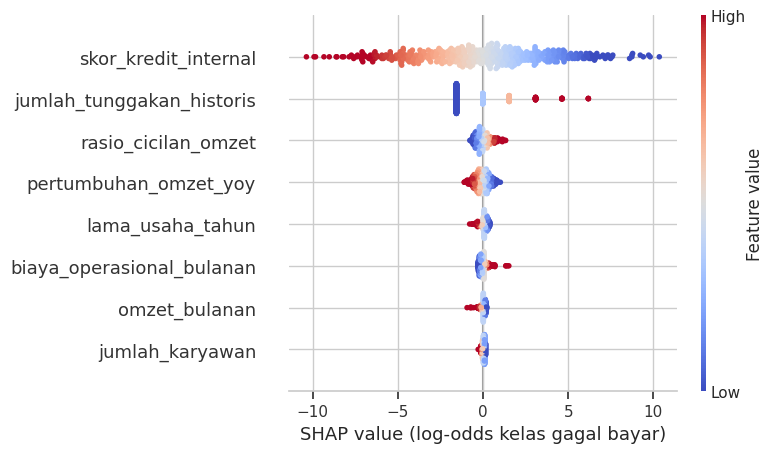

In [134]:
import shap
rng=np.random.default_rng(SEED)
background=Z_train[rng.choice(len(Z_train),min(100,len(Z_train)),replace=False)]
positions=rng.choice(len(Z_test),min(500,len(Z_test)),replace=False)
masker=shap.maskers.Independent(background,max_samples=100)
shap_explainer=shap.LinearExplainer(final_estimator,masker)
shap_explanation=shap_explainer(Z_test[positions])
shap_importance=pd.DataFrame({'fitur':model_features,'mean_abs_shap':np.abs(shap_explanation.values).mean(0)}).sort_values('mean_abs_shap',ascending=False)
display(shap_importance);AUDIT['shap_global']=shap_importance
shap.summary_plot(shap_explanation.values,Z_test[positions],feature_names=model_features,cmap='coolwarm',show=False)
plt.xlabel('SHAP value (log-odds kelas gagal bayar)');plt.tight_layout();plt.show()


### 12.3 SHAP untuk satu debitur dekat batas keputusan

Kita memilih debitur yang PD-nya paling dekat threshold, tanpa memilih berdasarkan label aktual. Ini membantu menjelaskan kasus yang dekat keputusan review.

Tabel menunjukkan fitur yang mendorong prediksi naik/turun. Bar merah menaikkan, biru menurunkan estimasi model. Script juga memeriksa bahwa acuan ditambah seluruh SHAP menghasilkan kembali keluaran model pada skala log-odds.

ID: UMKM-08323 PD: 0.41507275401944405 threshold: 0.415 actual: 1


,fitur,nilai_model,shap
5,jumlah_tunggakan_historis,-0.678916,-1.564387
4,rasio_cicilan_omzet,-0.721737,-0.324739
0,omzet_bulanan,1.422153,-0.197984
2,jumlah_karyawan,1.207408,-0.075765
1,lama_usaha_tahun,0.254186,0.014319
7,pertumbuhan_omzet_yoy,-1.074361,0.389074
6,biaya_operasional_bulanan,1.922577,0.459507
3,skor_kredit_internal,-1.747398,6.722285


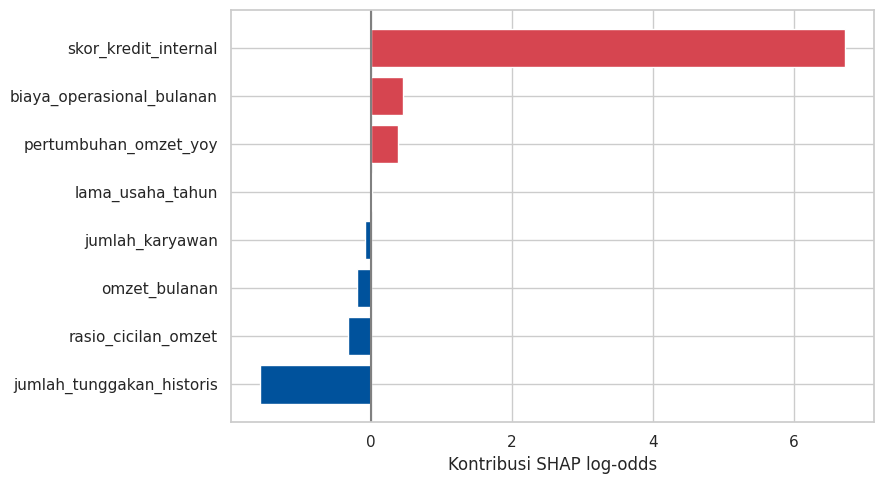

In [135]:
case_position=int(np.argmin(np.abs(pd_test-threshold_final)))
case_id=df.loc[X_test.index[case_position],'id_debitur']
local=shap_explainer(Z_test[case_position:case_position+1])
local_shap=pd.DataFrame({'fitur':model_features,'nilai_model':Z_test[case_position],'shap':local.values[0]}).sort_values('shap')
print('ID:',case_id,'PD:',pd_test[case_position],'threshold:',threshold_final,'actual:',y_test.iloc[case_position])
display(local_shap)
plt.figure(figsize=(9,5));plt.barh(local_shap.fitur,local_shap.shap,color=np.where(local_shap.shap>0,'#D64550','#00529C'));plt.axvline(0,color='gray');plt.xlabel('Kontribusi SHAP log-odds');plt.tight_layout();plt.show()
reconstructed=float(np.asarray(local.base_values).ravel()[0]+local.values[0].sum())
assert np.isclose(reconstructed,final_estimator.decision_function(Z_test[case_position:case_position+1])[0])
AUDIT['shap_local']=local_shap


### 12.4 LIME untuk debitur yang sama

LIME membuat banyak variasi data di sekitar contoh, meminta prediksi model, lalu membuat model sederhana untuk menirunya. Tabel kondisi memakai satuan sebelum StandardScaler; jika log/capping terpilih, satuan tersebut sudah mengikuti treatment. Kategori yang masuk tampil sebagai dummy.

Kita tampilkan R² pendekatan lokal dan selisih prediksi LIME dari PD model. R² rendah atau selisih besar berarti LIME belum cukup baik meniru model pada percobaan ini. Jangan memakai grafiknya sebagai alasan pasti. Contoh buatan LIME juga bisa membentuk kombinasi fitur yang jarang terjadi pada debitur asli.

,kondisi,bobot
1,jumlah_tunggakan_historis <= 0.00,-0.115274
4,omzet_bulanan > 33001338.75,-0.014690
5,5.90 < lama_usaha_tahun <= 7.60,-0.004777
7,jumlah_karyawan > 3.00,-0.004201
6,20.30 < rasio_cicilan_omzet <= 26.90,0.004230
3,biaya_operasional_bulanan > 26754744.75,0.029376
2,pertumbuhan_omzet_yoy <= -13.70,0.043189
0,skor_kredit_internal <= 562.00,0.344682


,id_debitur,r2,pd_model,prediksi_pendekatan_lime,selisih_absolut
0,UMKM-08323,0.483076,0.415073,0.353232,0.06184


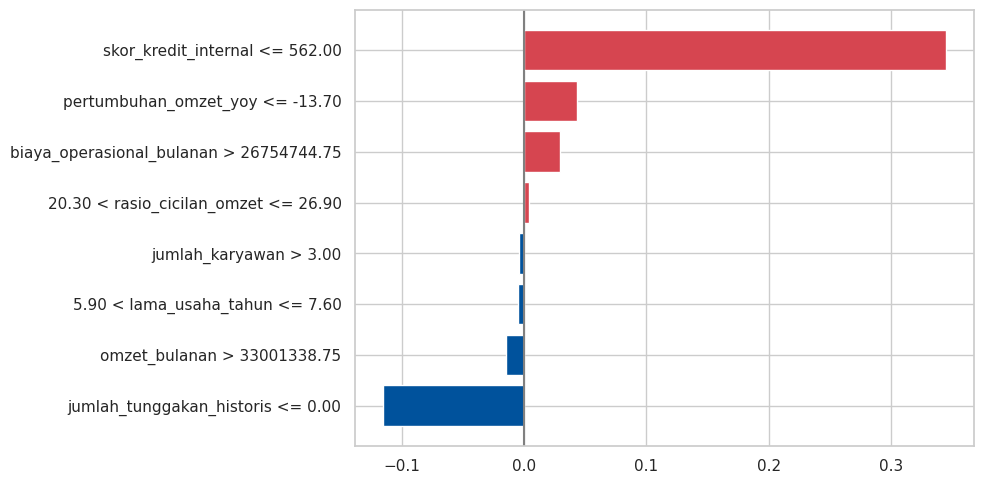

Periksa R² dan selisih prediksi: grafik LIME tidak otomatis merupakan penjelasan yang akurat.


In [136]:
from lime.lime_tabular import LimeTabularExplainer

def explanation_business_matrix(X):
    z=best_pipeline.named_steps['imputer'].transform(X)
    z=best_pipeline.named_steps['features'].transform(z)
    z=best_pipeline.named_steps['treatment'].transform(z)
    parts=[z[MODEL_NUM].to_numpy(dtype=float)]
    if chosen_categories:
        parts.append(best_pipeline.named_steps['pre'].named_transformers_['cat'].transform(z[list(chosen_categories)]))
    return np.column_stack(parts)

L_train=explanation_business_matrix(X_train)
L_test=explanation_business_matrix(X_test)
def predict_lime_business(values):
    z=np.asarray(values,dtype=float).copy()
    scale=best_pipeline.named_steps['pre'].named_transformers_['num']
    z[:,:len(MODEL_NUM)]=(z[:,:len(MODEL_NUM)]-scale.mean_)/scale.scale_
    return final_estimator.predict_proba(z)
assert np.allclose(predict_lime_business(L_test),best_pipeline.predict_proba(X_test))
lime_explainer=LimeTabularExplainer(L_train,feature_names=model_features,class_names=['Lancar','Gagal bayar'],mode='classification',discretize_continuous=True,random_state=SEED,
    categorical_features=list(range(len(MODEL_NUM),len(model_features))))
lime_explanation=lime_explainer.explain_instance(L_test[case_position],predict_lime_business,labels=(1,),num_features=len(model_features),num_samples=3000)
lime_table=pd.DataFrame(lime_explanation.as_list(label=1),columns=['kondisi','bobot']).sort_values('bobot')
display(lime_table)
lime_fidelity=pd.DataFrame([{'id_debitur':case_id,'r2':lime_explanation.score,
    'pd_model':float(pd_test[case_position]),'prediksi_pendekatan_lime':float(np.asarray(lime_explanation.local_pred).ravel()[0]),
    'selisih_absolut':abs(float(np.asarray(lime_explanation.local_pred).ravel()[0])-pd_test[case_position])}])
display(lime_fidelity)
plt.figure(figsize=(10,5));plt.barh(lime_table.kondisi,lime_table.bobot,color=np.where(lime_table.bobot>0,'#D64550','#00529C'));plt.axvline(0,color='gray');plt.tight_layout();plt.show()
AUDIT['lime_local']=lime_table; AUDIT['lime_fidelity']=lime_fidelity
print('Periksa R² dan selisih prediksi: grafik LIME tidak otomatis merupakan penjelasan yang akurat.')

### 13.1 Memeriksa perbedaan hasil antar gender

Gender tidak menjadi predictor, tetapi fitur lain masih dapat berkaitan dengan gender. Kita bandingkan tingkat tidak ditandai review, recall, FPR, dan precision tiap kelompok.

`DI` membandingkan tingkat tidak ditandai review dengan kelompok acuan. Nilai mendekati 1 berarti tingkatnya mirip; ini bukan bukti bahwa semua bentuk bias tidak ada. Kolom `ci_low`/`ci_high` memberi rentang ketidakpastian estimasi karena ukuran sampel terbatas. Keputusan model/threshold tidak diubah pada bagian test ini.

In [137]:
from scipy.stats import norm
fairness=[]
gender=df.loc[X_test.index,'jenis_kelamin_pemilik_usaha'].fillna('Tidak diketahui').to_numpy()
def wilson(success,total):
    if total==0:return (np.nan,np.nan)
    z=norm.ppf(.975);p=success/total;den=1+z*z/total
    center=(p+z*z/(2*total))/den;half=z*np.sqrt(p*(1-p)/total+z*z/(4*total*total))/den
    return center-half,center+half
for group in sorted(set(gender)):
    mask=gender==group;r=threshold_metrics(y_test.to_numpy()[mask],pd_test[mask],threshold_final)
    lo,hi=wilson(r['tp'],r['tp']+r['fn']);flo,fhi=wilson(r['fp'],r['fp']+r['tn'])
    fairness.append({'gender':group,'n':int(mask.sum()),'favorable_rate':1-r['review_rate'],'tpr':r['recall'],'fpr':1-r['specificity'],'precision':r['precision'],
    'tpr_ci_low':lo,'tpr_ci_high':hi,'fpr_ci_low':flo,'fpr_ci_high':fhi})
fairness=pd.DataFrame(fairness)
reference='Laki-laki' if 'Laki-laki' in fairness.gender.values else fairness.iloc[0].gender
ref=fairness.loc[fairness.gender==reference,'favorable_rate'].iloc[0]
fairness['DI_vs_reference']=fairness.favorable_rate/ref if ref>0 else np.nan
display(fairness);print('Referensi:',reference)
AUDIT['fairness']=fairness


,gender,n,favorable_rate,tpr,fpr,precision,tpr_ci_low,tpr_ci_high,fpr_ci_low,fpr_ci_high,DI_vs_reference
0,Laki-laki,955,0.860733,0.874016,0.026570,0.834586,0.805126,0.920944,0.017611,0.039902,1.000000
1,Perempuan,1017,0.856441,0.836879,0.031963,0.808219,0.767114,0.888776,0.022206,0.045808,0.995013


Referensi: Laki-laki


## 14. Membuat PD portofolio dan simulasi ECL

Model yang sudah dilatih pada seluruh train memberi PD ke semua debitur. Untuk baris train, model pernah melihat baris tersebut saat latihan; untuk test, belum. Karena itu, kinerja gabungan portofolio tidak dipakai sebagai bukti kemampuan menghadapi data baru. PD OOF train juga disimpan terpisah.

**ECL skenario = PD × LGD × EAD.** PD adalah peluang gagal bayar; LGD bagian eksposur yang diasumsikan hilang ketika default; EAD besarnya eksposur. Kita memakai plafon sebagai perkiraan EAD karena outstanding tidak tersedia. Plafon tetap ada meski keluar dari predictor PD.

LGD 40% untuk beragunan dan 75% tanpa agunan adalah asumsi simulasi. Status agunan saja belum menentukan recovery yang sebenarnya. Periode prediksi, recovery, dan kebutuhan perhitungan akuntansi belum lengkap, sehingga hasil ini disebut ECL skenario proyek, bukan CKPN resmi.

### 14.1 Menyimpan PD, flag, dan ECL di kolom berbeda

Label aktual tetap menjadi jawaban asli dataset. PD adalah perkiraan model, sedangkan flag review dibuat dari PD dan threshold. Ketiganya tidak saling menimpa.

ECL dihitung langsung dari PD kontinu. Menggeser threshold dapat mengubah jumlah review, tetapi tidak mengubah ECL jika PD, LGD, dan EAD tetap.

In [138]:
scored_portfolio=clean.copy()
scored_portfolio['pd_estimasi_model']=best_pipeline.predict_proba(df[INPUT_FEATURES])[:,1]
scored_portfolio['prediction_source']=np.where(scored_portfolio.split=='train','in_sample_train','out_of_sample_test')
scored_portfolio['pd_oof_train']=scored_portfolio.id_debitur.map(oof_table.set_index('id_debitur').pd_oof)
scored_portfolio['flag_prediksi_review']=(scored_portfolio.pd_estimasi_model>=threshold_final).astype(int)
LGD_SCENARIO={'ya':.4,'tidak':.75}
scored_portfolio['lgd_skenario']=scored_portfolio.kepemilikan_agunan.str.lower().map(LGD_SCENARIO)
assert scored_portfolio.lgd_skenario.notna().all()
scored_portfolio['ead_proxy']=scored_portfolio.plafon_kredit
scored_portfolio['ecl_estimasi']=scored_portfolio.pd_estimasi_model*scored_portfolio.lgd_skenario*scored_portfolio.ead_proxy
assert scored_portfolio.ecl_estimasi.between(0,scored_portfolio.ead_proxy).all()
display(scored_portfolio[['id_debitur','prediction_source',TARGET,'pd_estimasi_model','pd_oof_train','flag_prediksi_review','lgd_skenario','ead_proxy','ecl_estimasi']].head())


,id_debitur,prediction_source,flag_gagal_bayar,pd_estimasi_model,pd_oof_train,flag_prediksi_review,lgd_skenario,ead_proxy,ecl_estimasi
0,UMKM-06253,in_sample_train,0,0.826850,0.822886,1,0.40,107947053,3.570240e+07
1,UMKM-04685,in_sample_train,0,0.000024,0.000027,0,0.40,134528197,1.314920e+03
2,UMKM-01732,in_sample_train,0,0.876126,0.883384,1,0.75,235339829,1.546406e+08
3,UMKM-04743,out_of_sample_test,0,0.000202,NaN,0,0.40,188302794,1.520391e+04
4,UMKM-04522,out_of_sample_test,0,0.107439,NaN,0,0.75,166873882,1.344659e+07


### 14.2 Merangkum ECL menurut sektor/produk/agunan

Jumlahkan ECL dan EAD tiap kelompok untuk melihat konsentrasi eksposur dan estimasi kerugian. ECL rate = total ECL/total EAD, bukan rata-rata sederhana PD.

Kita juga mencoba asumsi LGD lebih rendah dan lebih tinggi. Perubahan hasil menunjukkan ketergantungan estimasi pada asumsi tersebut; tidak berarti kita sudah mengetahui kerugian masa depan.

In [139]:
def profile_by(data,col):
    t=data.groupby(col).agg(n=('id_debitur','size'),actual_rate=(TARGET,'mean'),pd_mean=('pd_estimasi_model','mean'),ead=('ead_proxy','sum'),ecl=('ecl_estimasi','sum')).reset_index()
    t['ecl_rate']=t.ecl/t.ead
    return t
for c in ['sektor_usaha','jenis_produk_kredit','kepemilikan_agunan']:
    t=profile_by(scored_portfolio,c);display(t);AUDIT['ecl_'+c]=t
lgd_sensitivity=[]
for yes,no in [(.3,.6),(.4,.75),(.5,.9)]:
    lgd=scored_portfolio.kepemilikan_agunan.str.lower().map({'ya':yes,'tidak':no})
    lgd_sensitivity.append({'lgd_yes':yes,'lgd_no':no,'ecl_total':(scored_portfolio.pd_estimasi_model*lgd*scored_portfolio.ead_proxy).sum()})
display(pd.DataFrame(lgd_sensitivity));AUDIT['lgd_sensitivity']=pd.DataFrame(lgd_sensitivity)


,sektor_usaha,n,actual_rate,pd_mean,ead,ecl,ecl_rate
0,Jasa Personal,1959,0.066871,0.071800,316384080080,1.446121e+10,0.045708
1,Konveksi dan Kerajinan Rumahan,1564,0.199488,0.195678,252521188634,3.144817e+10,0.124537
2,Kuliner,2185,0.112586,0.111104,347525510285,2.379400e+10,0.068467
3,Perdagangan Daring/Reseller,1549,0.054229,0.067184,256587765624,1.073927e+10,0.041854
4,Perdagangan Eceran,2603,0.217057,0.213867,414866562919,5.457636e+10,0.131552


,jenis_produk_kredit,n,actual_rate,pd_mean,ead,ecl,ecl_rate
0,KUR Kecil,7051,0.154730,0.156036,1273358035008,1.180210e+11,0.092685
1,KUR Mikro,2285,0.087090,0.086727,103231163520,6.600382e+09,0.063938
2,Kredit Modal Kerja,524,0.091603,0.098938,211295909014,1.039762e+10,0.049209


,kepemilikan_agunan,n,actual_rate,pd_mean,ead,ecl,ecl_rate
0,Tidak,5251,0.125309,0.128883,699001346735,8.097077e+10,0.115838
1,Ya,4609,0.147537,0.146118,888883760807,5.404825e+10,0.060805


,lgd_yes,lgd_no,ecl_total
0,0.3,0.60,1.053128e+11
1,0.4,0.75,1.350190e+11
2,0.5,0.90,1.647252e+11


## 15. Mengelompokkan debitur dengan karakteristik mirip

Clustering berbeda dari klasifikasi. Kita mengelompokkan debitur menurut ciri usahanya tanpa memberikan label gagal bayar kepada algoritma. PD, label, dan ECL baru dipakai untuk menceritakan profil kelompok setelah kelompok terbentuk.

Fitur yang digunakan: rasio cicilan, pertumbuhan omzet, rasio biaya terhadap omzet, dan log omzet. Log mengecilkan perbedaan angka omzet yang sangat besar. RobustScaler menggunakan median dan IQR untuk menyamakan skala. Cara ini dipilih khusus untuk clustering, tidak mengganti scaler model PD.

Seluruh portofolio digunakan karena tujuannya mendeskripsikan sampel yang ada, bukan menguji prediksi nasabah baru.

### 15.1 Membuat fitur untuk clustering

Rasio biaya = biaya operasional/omzet ×100%. Rasio ini menggambarkan besarnya biaya dibanding pendapatan, bukan margin bersih akuntansi. Pengisian omzet/biaya dapat memengaruhi rasionya.

Kolom rasio dan log dibuat pada tabel segmentasi. Dataset bersih tetap memiliki nominal aslinya sehingga hasil segmen masih bisa dijelaskan dalam rupiah dan persen.

In [140]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
segment_data=scored_portfolio.copy()
segment_data['rasio_biaya_operasional']=100*segment_data.biaya_operasional_bulanan/segment_data.omzet_bulanan
segment_data['log_omzet']=np.log1p(segment_data.omzet_bulanan)
CLUSTER_FEATURES=['rasio_cicilan_omzet','pertumbuhan_omzet_yoy','rasio_biaya_operasional','log_omzet']
X_cluster=segment_data[CLUSTER_FEATURES].copy()
assert np.isfinite(X_cluster).all().all()
display(segment_data[['id_debitur','omzet_bulanan','biaya_operasional_bulanan']+CLUSTER_FEATURES].head())


,id_debitur,omzet_bulanan,biaya_operasional_bulanan,rasio_cicilan_omzet,pertumbuhan_omzet_yoy,rasio_biaya_operasional,log_omzet
0,UMKM-06253,3.345429e+07,28147622.0,15.1,-24.1,84.137566,17.325690
1,UMKM-04685,2.850477e+07,12156548.0,38.3,-1.1,42.647413,17.165582
2,UMKM-01732,1.738090e+07,16743383.0,69.8,-22.0,96.332094,16.670882
3,UMKM-04743,2.408852e+07,16799206.0,36.0,4.6,69.739484,16.997246
4,UMKM-04522,2.672123e+07,22993939.0,33.3,-15.4,86.051214,17.100969


### 15.2 Menguji apakah capping diperlukan untuk clustering

Kita bandingkan tanpa capping, batas 1–99%, dan 5–95%, sementara jumlah cluster sementara dibuat sama: empat. Ini membantu melihat pengaruh perubahan data tanpa sekaligus mengubah jumlah cluster.

Pilih perubahan paling ringan yang menghasilkan kelompok terkecil minimal 5% sampel. Batas 5% adalah pilihan proyek agar kelompok cukup berisi, bukan ketentuan baku. Tabel jumlah sel berubah menunjukkan konsekuensi capping. Nilai asli tetap dipakai untuk profil bisnis.

Silhouette merangkum kedekatan anggota dalam kelompok dan pemisahan dari kelompok lain. Skor lintas transformasi perlu dibaca hati-hati karena bentuk/jarak datanya ikut berubah.

In [141]:
cluster_preprocessing=[]
cluster_matrices={}; cluster_scalers={}
for name,q in [('none',None),('cap01',.01),('cap05',.05)]:
    zz=X_cluster.copy()
    if q is not None: zz=zz.clip(lower=zz.quantile(q),upper=zz.quantile(1-q),axis=1)
    scaler=RobustScaler(); scaled=scaler.fit_transform(zz)
    model=KMeans(n_clusters=4,n_init=20,random_state=SEED).fit(scaled)
    score=silhouette_score(scaled,model.labels_,sample_size=min(2000,len(scaled)),random_state=SEED)
    cluster_preprocessing.append({'treatment':name,'silhouette_k4':score,'changed_cells':int((zz!=X_cluster).sum().sum()),'smallest_share':pd.Series(model.labels_).value_counts(normalize=True).min()})
    cluster_matrices[name]=scaled;cluster_scalers[name]=scaler
cluster_preprocessing=pd.DataFrame(cluster_preprocessing);display(cluster_preprocessing)
AUDIT['cluster_preprocessing']=cluster_preprocessing
eligible_pre=cluster_preprocessing.loc[cluster_preprocessing.smallest_share>=.05]
assert len(eligible_pre)>0, 'Tidak ada preprocessing yang memenuhi ukuran minimum segmen.'
CLUSTER_TREATMENT=eligible_pre.iloc[0].treatment
print('Preprocessing terpilih:',CLUSTER_TREATMENT,'; kandidat paling ringan yang memenuhi ukuran minimum.')


,treatment,silhouette_k4,changed_cells,smallest_share
0,none,0.243748,0,0.024645
1,cap01,0.255138,787,0.036004
2,cap05,0.258799,3934,0.228905


Preprocessing terpilih: cap05 ; kandidat paling ringan yang memenuhi ukuran minimum.


### 15.3 Membandingkan jumlah cluster

Setelah cara pengolahan dipilih, kita coba 2, 3, 4, 5, dan 6 cluster. Dari kandidat dengan kelompok terkecil minimal 5%, pilih silhouette tertinggi. Skala silhouette berkisar −1 sampai 1: makin tinggi umumnya kelompok makin terpisah; ini bukan accuracy prediksi gagal bayar.

Skor dihitung dari maksimum 2.000 contoh dengan pengacakan tetap agar proses tidak terlalu lama. Jumlah cluster tidak dipaksa empat hanya supaya cocok dengan empat nama bisnis yang kita inginkan.

In [142]:
scaled=cluster_matrices[CLUSTER_TREATMENT]
cluster_models={}; cluster_rows=[]
for k in range(2,7):
    m=KMeans(n_clusters=k,n_init=20,random_state=SEED).fit(scaled);cluster_models[k]=m
    cluster_rows.append({'k':k,'silhouette':silhouette_score(scaled,m.labels_,sample_size=min(2000,len(scaled)),random_state=SEED),
    'minimum_share':pd.Series(m.labels_).value_counts(normalize=True).min()})
cluster_evaluation=pd.DataFrame(cluster_rows)
eligible=cluster_evaluation.loc[cluster_evaluation.minimum_share>=.05]
assert len(eligible)>0
chosen_k=int(eligible.sort_values(['silhouette','k'],ascending=[False,True]).iloc[0].k)
kmeans_final=cluster_models[chosen_k]
segment_data['cluster']=kmeans_final.labels_
display(cluster_evaluation);print('k terpilih:',chosen_k)
AUDIT['cluster_k_evaluation']=cluster_evaluation


,k,silhouette,minimum_share
0,2,0.208580,0.499696
1,3,0.257969,0.274746
2,4,0.258799,0.228905
3,5,0.244964,0.157809
4,6,0.239658,0.123631


k terpilih: 4


### 15.4 Memberi nama berdasarkan ciri kelompok

Nomor cluster tidak memiliki arti bisnis. Kita lihat pusat kelompok (centroid) dan profilnya, lalu beri nama menurut beban cicilan, kontraksi omzet, dan tekanan biaya.

Tinggi/rendah bersifat relatif terhadap dataset ini, bukan batas resmi kredit. Setelah terbentuk, kita bandingkan default rate, PD, dan ECL setiap kelompok untuk menentukan kebutuhan review lebih lanjut.

,rasio_cicilan_omzet,pertumbuhan_omzet_yoy,rasio_biaya_operasional,log_omzet,omzet_geometrik
0,26.368500,-13.818115,91.981714,17.287566,3.220287e+07
1,46.009349,-2.850997,83.062586,16.822989,2.023630e+07
2,25.283652,5.130596,70.528696,17.345807,3.413407e+07
3,20.839003,-3.972847,85.767512,16.285434,1.182154e+07


,nama_segmen,rasio_cicilan_omzet,pertumbuhan_omzet_yoy,rasio_biaya_operasional,log_omzet
0,S1: kontraksi omzet / tekanan biaya,26.270758,-14.464717,94.754191,17.310466
1,S2: beban cicilan tinggi / kontraksi omzet / t...,47.411210,-2.811918,84.122637,16.814867
2,S3: beban relatif rendah,25.265158,5.706733,68.063490,17.373101
3,S4: kontraksi omzet / tekanan biaya,20.524934,-3.988539,96.106129,16.240805


,nama_segmen,n,actual_rate,pd_mean,ead,ecl,ecl_rate
0,S1: kontraksi omzet / tekanan biaya,2599,0.175067,0.173298,510389762430,5.000424e+10,0.097973
1,S2: beban cicilan tinggi / kontraksi omzet / t...,2257,0.257421,0.258077,441896195562,6.490158e+10,0.146871
2,S3: beban relatif rendah,2718,0.042311,0.047101,521608460372,1.356650e+10,0.026009
3,S4: kontraksi omzet / tekanan biaya,2286,0.081802,0.082817,113990689178,6.546688e+09,0.057432


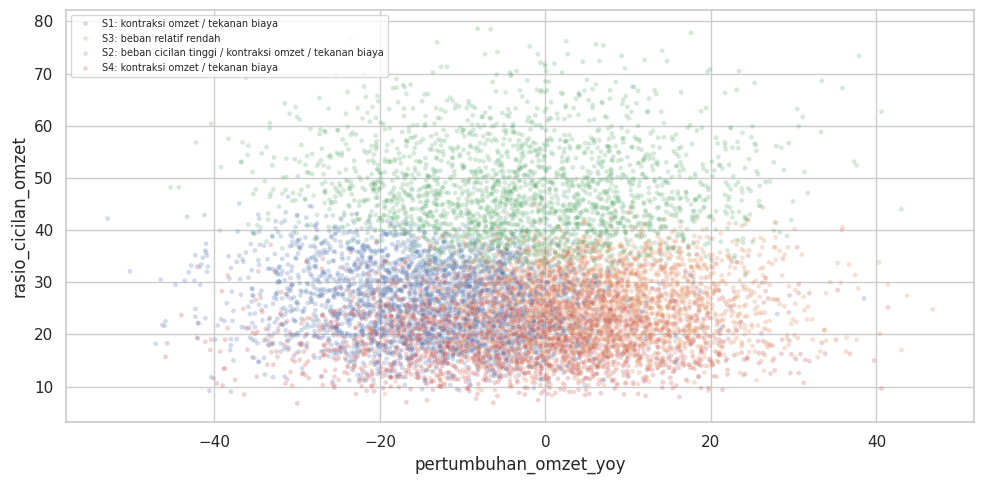

In [143]:
centroids=cluster_scalers[CLUSTER_TREATMENT].inverse_transform(kmeans_final.cluster_centers_)
centroid_table=pd.DataFrame(centroids,columns=CLUSTER_FEATURES)
centroid_table['omzet_geometrik']=np.expm1(centroid_table.log_omzet)
med=X_cluster.median(); names={}
for k,row in centroid_table.iterrows():
    traits=[]
    if row.rasio_cicilan_omzet>med.rasio_cicilan_omzet: traits.append('beban cicilan tinggi')
    if row.pertumbuhan_omzet_yoy<0: traits.append('kontraksi omzet')
    if row.rasio_biaya_operasional>med.rasio_biaya_operasional: traits.append('tekanan biaya')
    names[k]=f'S{k+1}: '+(' / '.join(traits) if traits else 'beban relatif rendah')
segment_data['nama_segmen']=segment_data.cluster.map(names)
scored_portfolio['nama_segmen']=segment_data.nama_segmen
segment_profile=profile_by(segment_data,'nama_segmen')
feature_profile=segment_data.groupby('nama_segmen')[CLUSTER_FEATURES].mean().reset_index()
display(centroid_table);display(feature_profile);display(segment_profile)
AUDIT['cluster_centroids']=centroid_table.reset_index(names='cluster');AUDIT['segment_profile']=segment_profile;AUDIT['segment_feature_means']=feature_profile
fig,ax=plt.subplots(figsize=(10,5));sns.scatterplot(data=segment_data,x='pertumbuhan_omzet_yoy',y='rasio_cicilan_omzet',hue='nama_segmen',alpha=.25,s=12,ax=ax);ax.legend(fontsize=7);plt.tight_layout();plt.show()


### 16.1 Menampilkan dashboard 16:9

Dashboard merangkum hasil yang sudah dibuat: jumlah debitur, PD, review rate, ECL skenario, confusion matrix test, SHAP, dan profil segmen. Tidak ada pelatihan atau pemilihan batas baru di bagian ini.

Confusion matrix khusus test; angka portofolio menggambarkan seluruh sampel. Keduanya memiliki tujuan berbeda dan tidak boleh dianggap evaluasi yang sama.

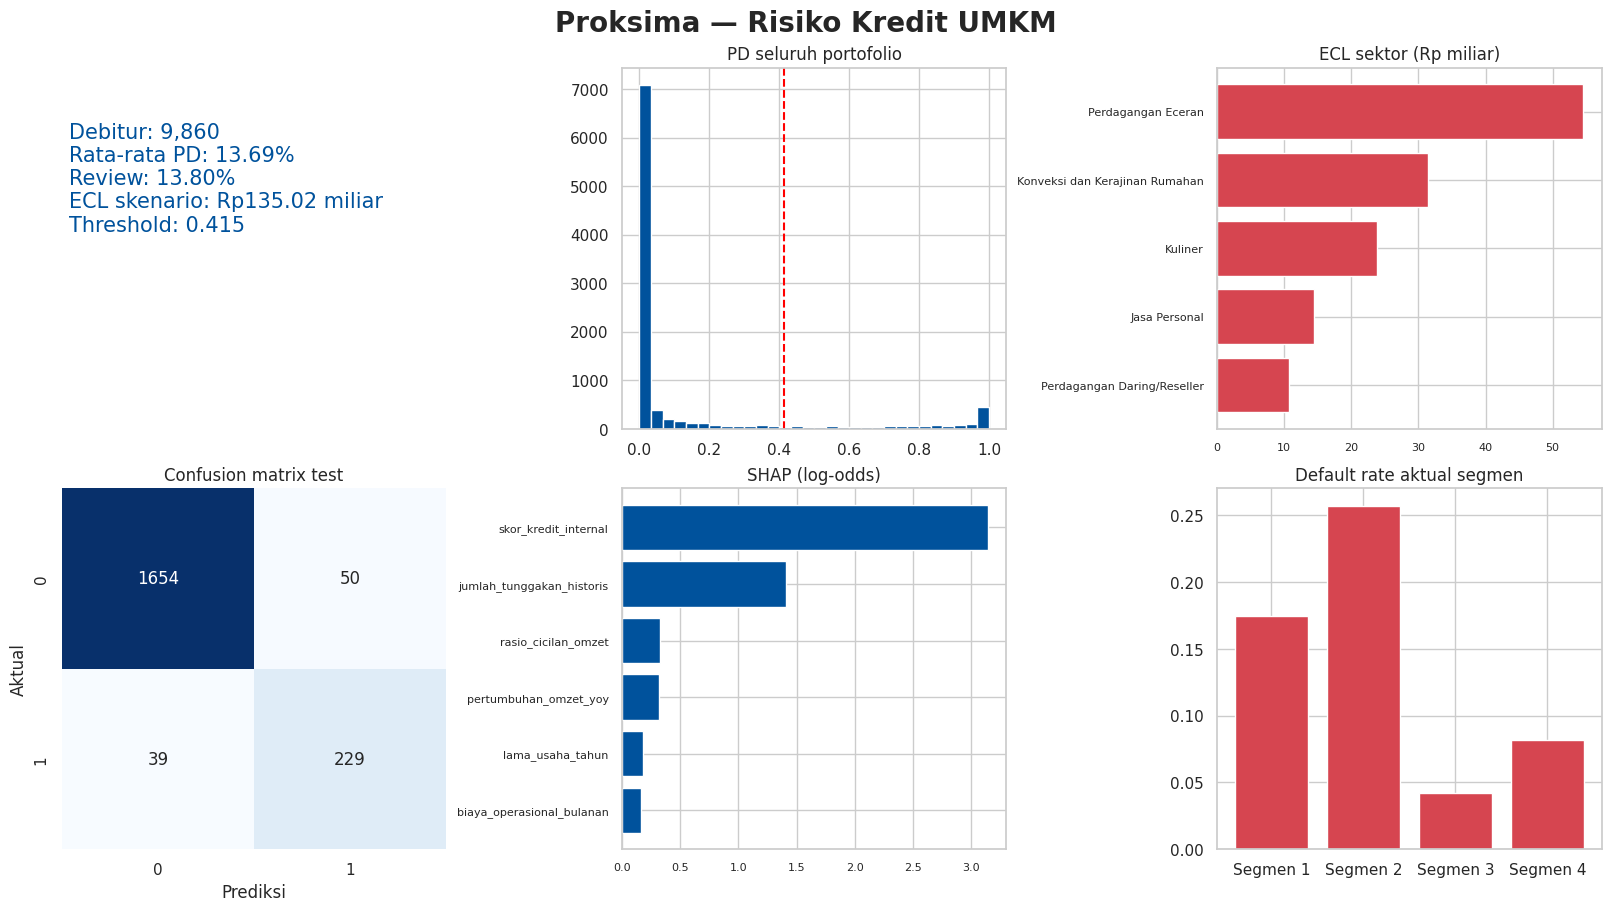

In [144]:
fig,axes=plt.subplots(2,3,figsize=(16,9),layout='constrained')
fig.suptitle('Proksima — Risiko Kredit UMKM',fontsize=20,fontweight='bold')
axes[0,0].axis('off')
summary=f"Debitur: {len(scored_portfolio):,}\nRata-rata PD: {scored_portfolio.pd_estimasi_model.mean():.2%}\nReview: {scored_portfolio.flag_prediksi_review.mean():.2%}\nECL skenario: Rp{scored_portfolio.ecl_estimasi.sum()/1e9:,.2f} miliar\nThreshold: {threshold_final:.3f}"
axes[0,0].text(.02,.85,summary,va='top',fontsize=15,color='#00529C')
axes[0,1].hist(scored_portfolio.pd_estimasi_model,bins=30,color='#00529C');axes[0,1].axvline(threshold_final,color='red',ls='--');axes[0,1].set_title('PD seluruh portofolio')
sector=profile_by(scored_portfolio,'sektor_usaha').sort_values('ecl')
axes[0,2].barh(sector.sektor_usaha,sector.ecl/1e9,color='#D64550');axes[0,2].set_title('ECL sektor (Rp miliar)');axes[0,2].tick_params(labelsize=8)
sns.heatmap(final_confusion,annot=True,fmt='d',cmap='Blues',cbar=False,ax=axes[1,0]);axes[1,0].set_title('Confusion matrix test');axes[1,0].set_xlabel('Prediksi');axes[1,0].set_ylabel('Aktual')
ss=shap_importance.head(6).sort_values('mean_abs_shap');axes[1,1].barh(ss.fitur,ss.mean_abs_shap,color='#00529C');axes[1,1].set_title('SHAP (log-odds)');axes[1,1].tick_params(labelsize=8)
axes[1,2].bar(range(len(segment_profile)),segment_profile.actual_rate,color='#D64550');axes[1,2].set_xticks(range(len(segment_profile)),[f'Segmen {i+1}' for i in range(len(segment_profile))]);axes[1,2].set_title('Default rate aktual segmen')
plt.show()
dashboard_figure=fig


## 17. Menyusun cerita hasil untuk presentasi

Ceritakan dari pertanyaan: apa masalah datanya, mengapa cara pengolahan perlu diuji, bagaimana hasil pengujiannya, dan apa konsekuensi pilihan kita. Setelah itu hubungkan hasil model dengan kebutuhan review debitur, profil kelompok, dan ECL skenario.

Sampaikan keterbatasan dengan bahasa sederhana: waktu pengukuran fitur belum lengkap; test pernah dilihat pada versi sebelumnya; sering mencoba pilihan pada train bisa membuat hasil terlihat terlalu baik; nilai isian bukan nilai asli yang teramati; SHAP/LIME menjelaskan model, bukan sebab pasti gagal bayar; fairness tidak bisa dijamin oleh satu rasio; ECL masih bergantung pada asumsi.

Tugas menyebut Bab II, III, dan VI. Cocokkan istilahnya dengan isi modul mentor karena isi bab tidak tersedia dalam file instruksi. Jangan mengarang pemetaan bab.

LR dipakai sesuai permintaan proyek. RF/XGBoost tetap ditampilkan sebagai pembanding. Jika hasil berubah ketika notebook diulang, jelaskan berdasarkan tabel terbaru, bukan mempertahankan kesimpulan lama.

### 17.1 Menampilkan daftar keputusan akhir

Tabel di bawah mengambil nama metode dari hasil script, sehingga tetap sesuai dengan model yang benar-benar digunakan. Gunakan tabel ini sebagai daftar urutan presentasi: masalah → percobaan → hasil → keputusan → keterbatasan.

In [145]:
decisions=pd.DataFrame([
{'tahap':'Fitur numerik transparan','pilihan':chosen_numeric_name,'dasar':'Performa, VIF, kestabilan SHAP; keterbatasan LIME dilaporkan'},
{'tahap':'Imputasi','pilihan':chosen_imputation,'dasar':'F1 CV; masking sebagai pendukung'},
{'tahap':'Feature set','pilihan':chosen_features,'dasar':'F1 CV, precision pemecah seri'},
{'tahap':'Treatment','pilihan':chosen_treatment,'dasar':'F1 CV pada pipeline LR yang sama'},
{'tahap':'Imbalance','pilihan':chosen_balance,'dasar':'F1 CV; validasi tidak di-resampling'},
{'tahap':'Algoritma final','pilihan':'LR','dasar':'Mandat proyek; benchmark terbaik '+benchmark_winner},
{'tahap':'Threshold','pilihan':str(threshold_final),'dasar':'F1 OOF maksimum; precision jika seri'},
{'tahap':'Cluster','pilihan':str(chosen_k),'dasar':'Silhouette tertinggi dengan minimum share 5%'}])
display(decisions);AUDIT['decision_register']=decisions
print('Test precision:',precision_score(y_test,flag_test_final),'recall:',recall_score(y_test,flag_test_final),'F1:',f1_score(y_test,flag_test_final))
print('Catatan: F0.5 adalah sensitivitas; cost 2FP+FN adalah ilustrasi, bukan keputusan biaya bank.')


,tahap,pilihan,dasar
0,Fitur numerik transparan,B_tanpa_plafon,"Performa, VIF, kestabilan SHAP; keterbatasan L..."
1,Imputasi,mean_sector,F1 CV; masking sebagai pendukung
2,Feature set,Numerik,"F1 CV, precision pemecah seri"
3,Treatment,none,F1 CV pada pipeline LR yang sama
4,Imbalance,none,F1 CV; validasi tidak di-resampling
5,Algoritma final,LR,Mandat proyek; benchmark terbaik LR
6,Threshold,0.415,F1 OOF maksimum; precision jika seri
7,Cluster,4,Silhouette tertinggi dengan minimum share 5%


Test precision: 0.8207885304659498 recall: 0.8544776119402985 F1: 0.8372943327239488
Catatan: F0.5 adalah sensitivitas; cost 2FP+FN adalah ilustrasi, bukan keputusan biaya bank.


### 18.1 Menyimpan dataset, model, dan jejak pekerjaan

Setiap run membuat folder baru. Dataset bersih, dataset dengan PD/ECL/segmen, tabel eksperimen, dan model disimpan bersama konfigurasi. Daftar file membantu memeriksa hasil mana yang tersedia.

Penanda data dihitung dari isi `raw` di cell ini. Jadi pembacaan CSV melalui URL tetap dapat dipakai tanpa variabel `source_hash`. Penanda ini mewakili tabel yang dibaca, bukan salinan byte file asli. Tidak ada ZIP yang dibuat.

In [146]:
from datetime import datetime,timezone
import cloudpickle,json,hashlib
# Sidik data dihitung di sini sehingga read_csv boleh berasal dari URL.
# Ini hash representasi tabel, bukan hash byte file CSV asli.
dataframe_hash=hashlib.sha256(raw.to_csv(index=False).encode('utf-8')).hexdigest()
OUTPUT_DIR=Path('hasil_proksima')/datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
OUTPUT_DIR.mkdir(parents=True,exist_ok=False)
AUDIT['clean_dataset']=clean;AUDIT['scored_dataset']=scored_portfolio
manifest=[]
for name,table in AUDIT.items():
    destination=OUTPUT_DIR/(name+'.csv');table.to_csv(destination,index=False)
    manifest.append({'file':destination.name,'rows':len(table),'sha256':hashlib.sha256(destination.read_bytes()).hexdigest()})
dashboard_figure.savefig(OUTPUT_DIR/'dashboard.png',dpi=160)
package={'pipeline':best_pipeline,'threshold':threshold_final,'features':INPUT_FEATURES,'target':TARGET,'numeric_predictors':MODEL_NUM,'numeric_feature_choice':chosen_numeric_name,'lgd_scenario':LGD_SCENARIO,
'cluster_model':kmeans_final,'cluster_scaler':cluster_scalers[CLUSTER_TREATMENT],'cluster_features':CLUSTER_FEATURES,'cluster_names':names,
'cluster_capping_bounds': ({'lower':X_cluster.quantile(.05 if CLUSTER_TREATMENT=='cap05' else .01).to_dict(),'upper':X_cluster.quantile(.95 if CLUSTER_TREATMENT=='cap05' else .99).to_dict()} if CLUSTER_TREATMENT!='none' else None),'cluster_treatment':CLUSTER_TREATMENT,'dataframe_sha256':dataframe_hash,'versions':versions.to_dict('records')}
with open(OUTPUT_DIR/'model_package.pkl','wb') as f:cloudpickle.dump(package,f)
config={'seed':SEED,'threshold':threshold_final,'threshold_rule':'max F1 then precision','primary_metric':'F1 CV at 0.5',
'numeric_predictors':MODEL_NUM,'numeric_feature_choice':chosen_numeric_name,'imputation':chosen_imputation,'categories':list(chosen_categories),'treatment':chosen_treatment,'balance':chosen_balance,'dataframe_sha256':dataframe_hash,
'holdout_history':'Previously inspected in earlier notebook version'}
(OUTPUT_DIR/'configuration.json').write_text(json.dumps(config,indent=2),encoding='utf-8')
manifest=pd.DataFrame(manifest);manifest.to_csv(OUTPUT_DIR/'manifest.csv',index=False)
display(manifest[['file','rows']]);print('Folder hasil:',OUTPUT_DIR.resolve())


,file,rows
0,versions.csv,7
1,kamus_data.csv,18
2,duplikasi_dihapus.csv,140
3,invalid_numerik.csv,0
4,normalisasi_kategori.csv,6
...,...,...
74,segment_profile.csv,4
75,segment_feature_means.csv,4
76,decision_register.csv,8
77,clean_dataset.csv,9860


Folder hasil: /content/hasil_proksima/20260910T021809243213Z


## Referensi metode dan panduan presentasi

- [Scikit-learn: cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html)
- [Pemilihan threshold](https://scikit-learn.org/stable/modules/classification_threshold.html)
- [F-beta dan bobot precision–recall](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.fbeta_score.html)
- [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
- [Imbalanced-learn: leakage saat resampling](https://imbalanced-learn.org/stable/common_pitfalls.html)
- [SHAP LinearExplainer](https://shap.readthedocs.io/en/latest/generated/shap.LinearExplainer.html)
- [LIME](https://lime-ml.readthedocs.io/en/latest/lime.html)

**Urutan menjelaskan satu eksperimen:** tunjukkan masalah → alternatif → data/fold yang digunakan → metrik dan aturan pemilihan → hasil → keputusan → before/after → batasan. Jelaskan bahwa kesimpulan berubah bila buktinya berubah; jangan menghafal angka hasil versi lama.
